In [1]:
import pandas as pd
import polars as pl
from pathlib import Path
from tqdm import tqdm
import gzip
from pybedtools import BedTool
from typing import Optional

In [2]:
import numpy  as np
assembly_df  = pd.read_table("../assembly_summary_with_tree.csv.gz", usecols=["species_taxid", "organism_name", "phylum", "genome_size"])\
            .drop_duplicates(subset=["species_taxid"], keep="first")
assembly_df.loc[:, "organism_name_reduced"] = assembly_df["organism_name"].apply(lambda x: x.split(" ")[0][0].upper() + ". " + x.split(" ")[1] if len(x.split(" ")) > 1 else x)

In [3]:
pattern = "IR"
extract_id = lambda x: "_".join(Path(x).name.split("_")[:2])

def load_motifs(pattern):
    target = Path(f"../motifs_{pattern}")
    infiles = [infile for infile in target.glob("*cessed.tsv")]
    motifs = dict()
    extract_id = lambda x: "_".join(Path(x).name.split("_")[:2])
    for infile in tqdm(infiles):
        motifs[extract_id(infile)] = pl.read_csv(infile, separator="\t")
    print(f"Loaded {len(motifs)} total datasets!")
    return motifs

def load_annotated_motifs(pattern = None):
    target = Path(f"../annotated")
    infiles = [infile for infile in target.glob("*cessed.annotated.csv")]
    motifs = dict()
    extract_id = lambda x: "_".join(Path(x).name.split("_")[:2])
    for infile in tqdm(infiles):
        motifs[extract_id(infile)] = pl.read_csv(infile, separator="\t")
    print(f"Loaded {len(motifs)} total datasets!")
    return motifs

def load_fasta():
    target = Path("../genomes")
    infiles = {extract_id(infile): infile for infile in target.glob("*.fna")}
    return infiles

def load_gff():
    target = Path("../ncbi_dataset/data")
    infiles = {infile.parent.name: infile for infile in target.glob("**/*.gff")}
    return infiles

def load_VCFs():
    target = Path("../processed_VCF").resolve()
    infiles = [infile for infile in target.glob("*.vcf.gz") if "monoallelic" in infile.name]
    vcfs = dict()
    for infile in infiles:
        vcfs[int(infile.name.split("_")[0])] = infile
    print(f"Loaded {len(vcfs)} total VCFs!")
    return vcfs

def read_VCF(VCF_in: str) -> pl.DataFrame:
    if Path(VCF_in).name.endswith(".gz"):
        fin = gzip.open(VCF_in, "rt")
    else:
        fin = open(VCF_in, mode="r", encoding="UTF-8")
    names: Optional[list] = None
    for line in fin:
        if line.startswith("##"):
            continue 
        names = line.strip().split()[:9]
        break
    assert names is not None
    # VCF_df = pl.read_csv(fin, has_header=False, separator="\t", columns=range(9), new_columns=names)
    VCF_df = pd.read_table(fin, header=None, names=names, usecols=range(9))
    attrs = ["AF"]
    for attr in attrs:
        VCF_df.loc[:, attr] = VCF_df["INFO"].apply(lambda x: float(x.split(f"{attr}=")[1].split(";")[0]))
    VCF_df = pl.from_pandas(VCF_df)

    VCF_df = VCF_df.with_columns(
        ref_length=pl.col("REF").str.len_chars(),
        alt_length=pl.col("ALT").str.len_chars()
    )\
    .with_columns(
        is_snp=pl.col("ref_length")==pl.col("alt_length")
    )\
    .filter(
        pl.col("is_snp") == True
    )
    fin.close()
    return VCF_df

reference_df = pd.read_table("../reference/reference_files.txt", header=None, names=["species_taxid", "accession_id"])
reference_df.loc[:, "accession_id"] = reference_df["accession_id"].apply(lambda x: extract_id(x.split("/")[-1]))
reference_df = dict(zip(reference_df["accession_id"], reference_df["species_taxid"]))

fasta = load_fasta()
motifs = load_motifs(pattern=pattern)
annotated_motifs = load_annotated_motifs()
vcfs = load_VCFs()
gff = load_gff()
gff = {accession_id: gff for accession_id, gff in load_gff().items() if accession_id in fasta.keys()}
len(gff)

100%|██████████| 98/98 [00:00<00:00, 147.62it/s]


Loaded 98 total datasets!


100%|██████████| 98/98 [00:00<00:00, 145.95it/s]


Loaded 98 total datasets!
Loaded 90 total VCFs!


98

In [4]:
def parse_number_of_strains(VCF_in: str) -> pl.DataFrame:
    if Path(VCF_in).name.endswith(".gz"):
        fin = gzip.open(VCF_in, "rt")
    else:
        fin = open(VCF_in, mode="r", encoding="UTF-8")
    total_strains: Optional[int] = None
    for line in fin:
        if line.startswith("##"):
            continue 
        total_strains = len(line.strip().split()[9:])
        break

    assert isinstance(total_strains, int)
    return total_strains 

In [5]:
if isinstance(assembly_df, pd.DataFrame):
    assembly_df = pl.from_pandas(assembly_df)
    
total_strains = dict()
for species_taxid, VCF_in in vcfs.items():
    total_strains[species_taxid] = parse_number_of_strains(VCF_in)
total_strains = pd.Series(total_strains).to_frame(name="total_strains").reset_index().rename(columns={"index": "species_taxid"})
total_strains = pl.from_pandas(total_strains)\
                .join(
                    assembly_df,
                    on="species_taxid",
                    how="left"
                )\
                .sort(["total_strains"], descending=True)
total_strains

species_taxid,total_strains,organism_name,genome_size,phylum,organism_name_reduced
i64,i64,str,i64,str,str
573,2537,"""Klebsiella pneumoniae""",5633290,"""Pseudomonadota""","""K. pneumoniae"""
28901,1766,"""Salmonella enterica subsp. ent…",4768957,"""Pseudomonadota""","""S. enterica"""
287,944,"""Pseudomonas aeruginosa""",6526814,"""Pseudomonadota""","""P. aeruginosa"""
470,800,"""Acinetobacter baumannii""",4032048,"""Pseudomonadota""","""A. baumannii"""
158836,398,"""Enterobacter hormaechei""",4897845,"""Pseudomonadota""","""E. hormaechei"""
…,…,…,…,…,…
29461,25,"""Brucella suis""",3319697,"""Pseudomonadota""","""B. suis"""
28141,25,"""Cronobacter sakazakii""",4610566,"""Pseudomonadota""","""C. sakazakii"""
57975,25,"""Burkholderia thailandensis""",6729116,"""Pseudomonadota""","""B. thailandensis"""


In [6]:
import pickle 
import sys 
sys.path.insert(0, "..")
from process_VCF_step_3 import TrinucleotideModel
model_out = Path("../models")
assert model_out.is_dir()
models = {int(model_file.stem.split("_")[-1]): pickle.load(open(model_file, "rb")) for model_file in model_out.glob("*.pkl")}
len(models)

91

In [7]:
from collections import defaultdict 
species_taxid = 446
def predict(model, sequence: str) -> float:
    if model.event_rate is None:
        raise NotFittedError()
    content = defaultdict(int)
    sequence = sequence.upper()
    for i in range(0, len(sequence) - model.offset * 2):
        content[model.canonical[sequence[i: i + 2 * model.offset + 1]]] += 1
    event_burden = sum(content[kmer] * model.event_rate.get(kmer, 0) for kmer in content)
    return event_burden

predict(models[species_taxid], "agg")

0.11944932985626781

In [8]:
import sys; sys.path.insert(0, "..")
from process_VCF_step_1 import Fasta 

def extend_context(motif_df, fasta):
    f = Fasta(fasta).extract_gs()
    motif_bed = (
        BedTool.from_dataframe(
            motif_df
            .with_columns(
                chr_size=pl.col("seqID").map_elements(lambda y: f.size[y], return_dtype=int)
            )
            .with_columns(
                expanded_start=pl.max_horizontal(pl.col("start")-1, 0),
                expanded_end=pl.min_horizontal(pl.col("end")+1, pl.col("chr_size"))
            ).select(["seqID", 
                    "expanded_start", 
                    "expanded_end", 
                    "start", 
                    "end"]).to_pandas()
                    )
            .sort()
    )
    
    motif_seq = motif_bed.sequence(
        fi=fasta, name=True, tab=True
    )
    extended_motif_df = []
    with open(motif_seq.seqfn, mode="r", encoding="UTF-8") as f:
        for line in f:
            line = line.strip().split()
            data = line[0]
            extended_sequence = line[1]
            start, data = data.split("::")
            start = int(start)
            seqID, coords = data.split(":")
            extended_start, extended_end = list(map(int, coords.split("-")))
            extended_motif_df.append(
                {
                 "seqID": seqID,
                 "extended_start": extended_start,
                 "extended_end": extended_end,
                 "extended_sequence": extended_sequence,
                 "start": start,
                 }
            )   
    extended_motif_df = motif_df.join(
            pl.DataFrame(extended_motif_df),
            on=["seqID", "start"],
            how="left"
    )
    assert extended_motif_df.shape[0] == motif_df.shape[0]
    return extended_motif_df

extended_motifs = dict()
for accession_id, motif_df in tqdm(motifs.items()):
    fasta_file = fasta[accession_id]
    # if accession_id not in reference_df:
    #     continue 
    # species_taxid = reference_df[accession_id]
    extended_motif_df = extend_context(motif_df, fasta_file)
    extended_motifs[accession_id] = extended_motif_df
    
extended_motif_df

100%|██████████| 98/98 [00:05<00:00, 19.06it/s]


seqID,start,end,sequence_of_arm,arm_length,sequence_of_spacer,spacer_length,sequence,sequence_length,#assembly_accession,extended_start,extended_end,extended_sequence
str,i64,i64,str,i64,str,i64,str,i64,str,i64,i64,str
"""NZ_CP030753.1""",2483,2515,"""gttactttctttg""",13,"""cttcgc""",6,"""gttactttctttgcttcgccaaagaaagta…",32,"""GCF_003290385.1""",2482,2516,"""TGTTACTTTCTTTGCTTCGCCAAAGAAAGT…"
"""NZ_CP030753.1""",3891,3920,"""aaaaagggatgtgt""",14,"""t""",1,"""aaaaagggatgtgttacacatcccttttt""",29,"""GCF_003290385.1""",3890,3921,"""TAAAAAGGGATGTGTTACACATCCCTTTTT…"
"""NZ_CP030753.1""",4576,4598,"""atttaaataat""",11,""".""",0,"""atttaaataatattatttaaat""",22,"""GCF_003290385.1""",4575,4599,"""AATTTAAATAATATTATTTAAATA"""
"""NZ_CP030753.1""",5894,5919,"""aaagcccaagca""",12,"""a""",1,"""aaagcccaagcaatgcttgggcttt""",25,"""GCF_003290385.1""",5893,5920,"""AAAAGCCCAAGCAATGCTTGGGCTTTG"""
"""NZ_CP030753.1""",15071,15097,"""actttctttg""",10,"""cttcgc""",6,"""actttctttgcttcgccaaagaaagt""",26,"""GCF_003290385.1""",15070,15098,"""CACTTTCTTTGCTTCGCCAAAGAAAGTA"""
…,…,…,…,…,…,…,…,…,…,…,…,…
"""NZ_CP030753.1""",2301968,2301991,"""accctatacg""",10,"""gct""",3,"""accctatacggctcgtatagggt""",23,"""GCF_003290385.1""",2301967,2301992,"""AACCCTATACGGCTCGTATAGGGTA"""
"""NZ_CP030753.1""",2304354,2304390,"""ataaaaaatccaccg""",15,"""tacaag""",6,"""ataaaaaatccaccgtacaagcggtggatt…",36,"""GCF_003290385.1""",2304353,2304391,"""AATAAAAAATCCACCGTACAAGCGGTGGAT…"
"""NZ_CP030753.1""",2307489,2307511,"""aagcggtgaaa""",11,""".""",0,"""aagcggtgaaatttcaccgctt""",22,"""GCF_003290385.1""",2307488,2307512,"""AAAGCGGTGAAATTTCACCGCTTG"""


In [9]:
from pybedtools import BedTool 
from collections import defaultdict 

VCFs_df = dict()
for species_taxid, motif_df in tqdm(motifs.items()):
    species_taxid = reference_df.get(species_taxid, None)
    model = models.get(species_taxid, None)
    if model is None:
        continue
    # print(f"Processing species taxid: {species_taxid} with model.")
    # Further processing can be done here using motif_df and model
    
    baseline = model.base_rate
    VCF_df = (
            read_VCF(vcfs[species_taxid])
            .filter(pl.col("is_snp") == True)
            .select(["#CHROM", "POS", "AF"])
            .with_columns([
                    (pl.col("POS") - 1).alias("start"),
                    pl.col("POS").alias("end")
            ])
            .rename({"#CHROM": "seqID"})
            .drop(["POS"])
            .group_by(["seqID", "start", "end"], maintain_order=True)
            .agg([
                pl.col("AF").mean().alias("AF_mean"),
                pl.len().alias("distinct_variants")
            ])
            .to_pandas()
    )
    
    VCFs_df[species_taxid] = VCF_df

100%|██████████| 98/98 [02:03<00:00,  1.26s/it]


In [11]:
reference_df_1 = {val: key for key, val in reference_df.items()}
species_taxid = 28450

In [10]:
## Alelle Frequency mean per Arm Length

In [11]:
overlapping_features = []
for species_taxid, VCF_df in tqdm(VCFs_df.items()):
    accession_id = reference_df_1[species_taxid]
    motif_bed = BedTool.from_dataframe(
            annotated_motifs[accession_id]
                .select(["seqID", "start", "end", "arm_length", "spacer_length", "sequence_of_arm", "compartment"])
                .to_pandas()
        ).sort()

    VCF_bed = BedTool.from_dataframe(VCF_df[["seqID", "start", "end", "AF_mean"]]).sort()

    temp_df = pl.read_csv(
        motif_bed.intersect(VCF_bed, C=True).fn,
        has_header=False,
        separator="\t",
        new_columns=["seqID", "start", "end", "arm_length", "spacer_length", "sequence_of_arm", "total_mut"]
    )
    overlapping_features.append(temp_df.with_columns(species_taxid=pl.lit(species_taxid)))
     
overlapping_features = pl.concat(overlapping_features)
overlapping_features

  0%|          | 0/90 [00:00<?, ?it/s]


NameError: name 'reference_df_1' is not defined

<Axes: xlabel='arm_length', ylabel='mutations_per_base'>

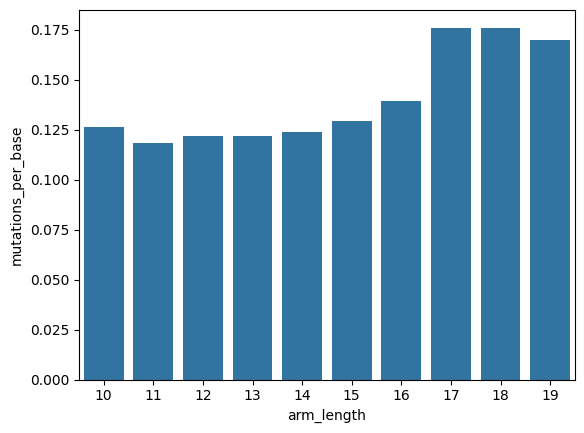

In [ ]:
per_arm_length = overlapping_features.group_by("arm_length").agg([
    pl.col("total_mut").sum().alias("total_mutations"),
    pl.col("arm_length").sum().alias("arm_length_total"),
    pl.col("arm_length").count().alias("num_arms")
]).filter(pl.col("num_arms") >= 100).with_columns(
    (pl.col("total_mutations") / pl.col("arm_length_total")).alias("mutations_per_base")
)
sns.barplot(data=per_arm_length.to_pandas(), x="arm_length", y="mutations_per_base")

<Axes: xlabel='spacer_length', ylabel='mutations_per_base'>

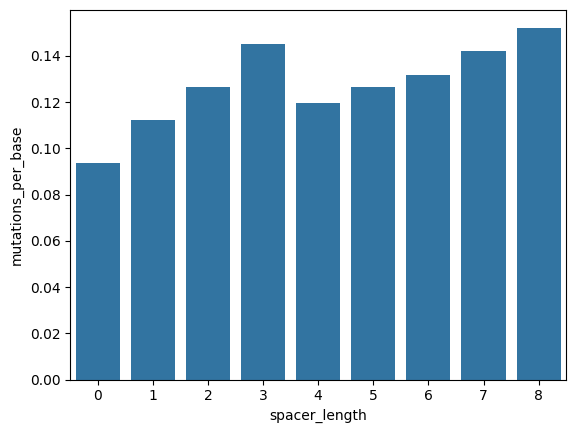

In [ ]:
per_arm_length = overlapping_features.group_by("spacer_length").agg([
    pl.col("total_mut").sum().alias("total_mutations"),
    pl.col("arm_length").sum().alias("arm_length_total"),
    pl.col("arm_length").count().alias("num_arms")
]).filter(pl.col("num_arms") >= 100).with_columns(
    (pl.col("total_mutations") / pl.col("arm_length_total")).alias("mutations_per_base")
)
sns.barplot(data=per_arm_length.to_pandas(), 
            x="spacer_length", 
            y="mutations_per_base")

In [13]:
from process_VCF_step_1 import Fasta

chr_sizes = dict()
for accession_id, fna in tqdm(fasta.items()):
    sizes = Fasta(fna).extract_gs()
    chr_sizes[accession_id] = sizes

100%|██████████| 98/98 [00:00<00:00, 113.29it/s]


In [14]:
def extend_context(motif_df: pl.DataFrame, fasta, chr_sizes, offset: int = 1):
    extract_id = lambda x: "_".join(Path(fasta).name.split("_")[:2])
    motif_df = (
            motif_df.with_columns(
                chrom_length=pl.col("seqID").map_elements(lambda x: chr_sizes[extract_id(fasta)].size[x], return_dtype=pl.Int32)
            )
            .with_columns(
                extended_start=pl.max_horizontal(pl.col("start") - offset, 0),
                extended_end=pl.min_horizontal(pl.col("end") + offset, pl.col("chrom_length"))
            )
            .with_columns(
                extension_length=pl.col("extended_end") - pl.col("extended_start")
            )
            .filter(
                pl.col("extension_length") == pl.col("sequence_length") + 2
            )
    )
    extended_motif_bed = BedTool.from_dataframe(motif_df.select(["seqID", "extended_start", "extended_end", "start", "end"]).to_pandas()).sort()

    extended_offset_context = extended_motif_bed.sequence(
        fi=fasta, 
        name=True, 
        tab=True
    )
    motifs_with_context = []
    with open(extended_offset_context.seqfn, mode="r", encoding="UTF-8") as f:
        for line in f:
            line = line.strip().split()
            data = line[0]
            extended_sequence = line[1]
            start, data = data.split("::")
            start = int(start)
            seqID, coords = data.split(":")
            extended_start, extended_end = list(map(int, coords.split("-")))
            # if extended_end - extended_start < 2 * offset + 1:
            #     continue
            motifs_with_context.append({
                "seqID": seqID,
                "start": start,
                "extended_sequence": extended_sequence,
                "extended_start": extended_start,
                "extended_end": extended_end,
                "length": extended_end - extended_start - 2,
            })
    motifs_with_context_df = (
                    motifs_df 
                    .join(
                        pl.DataFrame(motifs_with_context)
                            .with_columns(
                                end=pl.col("start") + pl.col("length")
                            ),
                            on=["seqID", "start", "end"],
                            how="left"
                        )
                    )
    assert motifs_with_context_df.height == motif_df.height, "Mismatch in number of motifs after extending context!"
    return motifs_with_context_df

reference_df_1 = {val: key for key, val in reference_df.items()}
species_taxid = 28450
motifs_df = motifs[reference_df_1[species_taxid]]
genome = fasta[reference_df_1[species_taxid]]


motifs_with_context_df = extend_context(motifs_df, genome, chr_sizes, offset=1)
motifs_with_context_df

seqID,start,end,sequence_of_arm,arm_length,sequence_of_spacer,spacer_length,sequence,sequence_length,#assembly_accession,extended_sequence,extended_start,extended_end,length
str,i64,i64,str,i64,str,i64,str,i64,str,str,i64,i64,i64
"""NZ_AP028077.1""",1669,1695,"""gcgcgacgaac""",11,"""gaat""",4,"""gcgcgacgaacgaatgttcgtcgcgc""",26,"""GCF_030297255.1""","""AGCGCGACGAACGAATGTTCGTCGCGCA""",1668,1696,26
"""NZ_AP028077.1""",2982,3012,"""cggttatccac""",11,"""agggtggc""",8,"""cggttatccacagggtggcgtggataaccg""",30,"""GCF_030297255.1""","""GCGGTTATCCACAGGGTGGCGTGGATAACC…",2981,3013,30
"""NZ_AP028077.1""",5785,5815,"""aaaaaacccgctg""",13,"""gttt""",4,"""aaaaaacccgctggtttcagcgggtttttt""",30,"""GCF_030297255.1""","""CAAAAAACCCGCTGGTTTCAGCGGGTTTTT…",5784,5816,30
"""NZ_AP028077.1""",10841,10867,"""cgccgaagttgcg""",13,""".""",0,"""cgccgaagttgcgcgcaacttcggcg""",26,"""GCF_030297255.1""","""TCGCCGAAGTTGCGCGCAACTTCGGCGC""",10840,10868,26
"""NZ_AP028077.1""",27596,27624,"""cggcaggcggcg""",12,"""cttt""",4,"""cggcaggcggcgctttcgccgcctgccg""",28,"""GCF_030297255.1""","""CCGGCAGGCGGCGCTTTCGCCGCCTGCCGC""",27595,27625,28
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""NZ_AP028078.1""",3126674,3126696,"""cggcacgcgca""",11,""".""",0,"""cggcacgcgcatgcgcgtgccg""",22,"""GCF_030297255.1""","""TCGGCACGCGCATGCGCGTGCCGG""",3126673,3126697,22
"""NZ_AP028078.1""",3126948,3126976,"""cgcgcgcggc""",10,"""ggcgcgaa""",8,"""cgcgcgcggcggcgcgaagccgcgcgcg""",28,"""GCF_030297255.1""","""GCGCGCGCGGCGGCGCGAAGCCGCGCGCGA""",3126947,3126977,28
"""NZ_AP028078.1""",3126962,3126988,"""cgaagccgcg""",10,"""cgcgac""",6,"""cgaagccgcgcgcgaccgcggcttcg""",26,"""GCF_030297255.1""","""GCGAAGCCGCGCGCGACCGCGGCTTCGA""",3126961,3126989,26


In [22]:
reference_df_1 = {val: key for key, val in reference_df.items()}

In [23]:
features_arm_ext = []
features_spacer_ext = []
features_ext = []
for species_taxid, VCF_df in VCFs_df.items():
    accession_id = reference_df_1[species_taxid]
    motifs_df = annotated_motifs[accession_id]

    motifs_filtered_df = (
        motifs_df
            .filter(pl.col("spacer_length") > 0)
            .with_columns(
                left_arm_start=pl.col("start"),
                left_arm_end=pl.col("start") + pl.col("arm_length"),
                right_arm_start=pl.col("start") + pl.col("arm_length") + pl.col("spacer_length"),
                right_arm_end=pl.col("end"),
                spacer_start=pl.col("start") + pl.col("arm_length"),
                spacer_end=pl.col("start") + pl.col("arm_length") + pl.col("spacer_length")
            )
    )

    left_arm_bed = BedTool.from_dataframe(
                        motifs_filtered_df
                            .select(["seqID", "left_arm_start", "left_arm_end", "start", "end", "arm_length", "spacer_length", "sequence_of_arm", "compartment",])
                            .to_pandas()
                ).sort()
    right_arm_bed= BedTool.from_dataframe(
                            motifs_filtered_df
                            .select(["seqID", "right_arm_start", "right_arm_end", "start", "end", "arm_length", "spacer_length", "sequence_of_arm", "compartment",])
                            .to_pandas()
                ).sort()
    spacer_bed = BedTool.from_dataframe(
                            motifs_filtered_df
                            .select(["seqID", "spacer_start", "spacer_end", "start", "end", "arm_length", "spacer_length", "sequence_of_arm", "compartment",])
                            .to_pandas()
                ).sort()
    
    arm_bed = left_arm_bed.cat(right_arm_bed, postmerge=False).sort()

    VCF_bed = BedTool.from_dataframe(VCF_df[["seqID", "start", "end", "AF_mean"]]).sort().merge()

    arm_mut_df = pl.read_csv(
        arm_bed.intersect(VCF_bed, C=True).fn,
        has_header=False,
        separator="\t",
        new_columns=["seqID", "start", "end", "IR_start", "IR_end", "arm_length", "spacer_length", "sequence_of_arm", "compartment", "mut_counts"]
    )
    # features_arm_ext.append(
    #     arm_mut_df.with_columns(species_taxid=pl.lit(species_taxid))
    # )
    # Spacer 
    spacer_mut_df = pl.read_csv(
        spacer_bed.intersect(VCF_bed, C=True).fn,
        has_header=False,
        separator="\t",
        new_columns=["seqID", "start", "end", "IR_start", "IR_end", "arm_length", "spacer_length", "sequence_of_arm", "compartment", "mut_counts"]
    )

    arm_mut_df = arm_mut_df.join(
        spacer_mut_df,  
        on=["seqID", "IR_start", "IR_end", "arm_length", "spacer_length", "sequence_of_arm", "compartment"],
        how="left",
        suffix="_spacer"
    )
    features_ext.append(
        arm_mut_df.with_columns(species_taxid=pl.lit(species_taxid))
    )

features_ext = pl.concat(features_ext)
features_ext

seqID,start,end,IR_start,IR_end,arm_length,spacer_length,sequence_of_arm,compartment,mut_counts,start_spacer,end_spacer,mut_counts_spacer,species_taxid
str,i64,i64,i64,i64,i64,i64,str,str,i64,i64,i64,i64,i32
"""NZ_CP071487.1""",3034,3046,3034,3065,12,7,"""aaaatccgcaag""","""Terminator""",0,3046,3053,0,738
"""NZ_CP071487.1""",3053,3065,3034,3065,12,7,"""aaaatccgcaag""","""Terminator""",0,3046,3053,0,738
"""NZ_CP071487.1""",14365,14383,14365,14409,18,8,"""ggggctgacctagattag""","""Terminator""",1,14383,14391,0,738
"""NZ_CP071487.1""",14391,14409,14365,14409,18,8,"""ggggctgacctagattag""","""Terminator""",0,14383,14391,0,738
"""NZ_CP071487.1""",30925,30936,30925,30954,11,7,"""aagggcgagta""","""Terminator""",0,30936,30943,2,738
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""NZ_CP030753.1""",2304375,2304390,2304354,2304390,15,6,"""ataaaaaatccaccg""","""Terminator""",0,2304369,2304375,1,715
"""NZ_CP030753.1""",2309676,2309691,2309676,2309710,15,4,"""ataaaaaactcagct""","""Terminator""",1,2309691,2309695,1,715
"""NZ_CP030753.1""",2309695,2309710,2309676,2309710,15,4,"""ataaaaaactcagct""","""Terminator""",0,2309691,2309695,1,715


In [24]:
features_ext.filter(pl.col("mut_counts_spacer") > pl.col("mut_counts"))

seqID,start,end,IR_start,IR_end,arm_length,spacer_length,sequence_of_arm,compartment,mut_counts,start_spacer,end_spacer,mut_counts_spacer,species_taxid
str,i64,i64,i64,i64,i64,i64,str,str,i64,i64,i64,i64,i32
"""NZ_CP071487.1""",30925,30936,30925,30954,11,7,"""aagggcgagta""","""Terminator""",0,30936,30943,2,738
"""NZ_CP071487.1""",30943,30954,30925,30954,11,7,"""aagggcgagta""","""Terminator""",1,30936,30943,2,738
"""NZ_CP071487.1""",152848,152861,152848,152881,13,7,"""aaaacccgataac""","""Other""",0,152861,152868,2,738
"""NZ_CP071487.1""",152868,152881,152848,152881,13,7,"""aaaacccgataac""","""Other""",0,152861,152868,2,738
"""NZ_CP071487.1""",165184,165197,165184,165215,13,5,"""aaaggcgttattc""","""Other""",0,165197,165202,1,738
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""NZ_CP030753.1""",2291647,2291658,2291647,2291674,11,5,"""aaaagagctga""","""Terminator""",0,2291658,2291663,1,715
"""NZ_CP030753.1""",2291663,2291674,2291647,2291674,11,5,"""aaaagagctga""","""Terminator""",0,2291658,2291663,1,715
"""NZ_CP030753.1""",2304354,2304369,2304354,2304390,15,6,"""ataaaaaatccaccg""","""Terminator""",0,2304369,2304375,1,715


In [25]:
features_ext.filter(pl.col("mut_counts") > pl.col("mut_counts_spacer"))

seqID,start,end,IR_start,IR_end,arm_length,spacer_length,sequence_of_arm,compartment,mut_counts,start_spacer,end_spacer,mut_counts_spacer,species_taxid
str,i64,i64,i64,i64,i64,i64,str,str,i64,i64,i64,i64,i32
"""NZ_CP071487.1""",14365,14383,14365,14409,18,8,"""ggggctgacctagattag""","""Terminator""",1,14383,14391,0,738
"""NZ_CP071487.1""",31872,31888,31851,31888,16,5,"""aaaacacccctaatat""","""Terminator""",1,31867,31872,0,738
"""NZ_CP071487.1""",38119,38134,38119,38151,15,2,"""aaaaaaacctagcca""","""Terminator""",2,38134,38136,0,738
"""NZ_CP071487.1""",38136,38151,38119,38151,15,2,"""aaaaaaacctagcca""","""Terminator""",2,38134,38136,0,738
"""NZ_CP071487.1""",68299,68310,68299,68322,11,1,"""ccccctctttg""","""Terminator""",2,68310,68311,1,738
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""NZ_CP030753.1""",2284577,2284588,2284577,2284601,11,2,"""cggcgatttta""","""Other""",1,2284588,2284590,0,715
"""NZ_CP030753.1""",2296804,2296814,2296804,2296827,10,3,"""acctagcacg""","""Terminator""",1,2296814,2296817,0,715
"""NZ_CP030753.1""",2301874,2301884,2301874,2301897,10,3,"""acctagcacg""","""Terminator""",1,2301884,2301887,0,715


In [29]:
from scipy.stats import fisher_exact 
from statsmodels.stats.multitest import multipletests

grouped_features_df = features_ext.group_by(["species_taxid"]).agg([
    pl.col("mut_counts").sum().alias("total_arm_mutations"),
    pl.col("arm_length").sum().alias("total_arm_length"),
    pl.col("mut_counts_spacer").sum().alias("total_spacer_mutations"),
    pl.col("spacer_length").sum().alias("total_spacer_length"),
    pl.col("spacer_length").count().alias("num_arms")
])\
.filter(pl.col("num_arms") >= 10)\
.with_columns(
    (pl.col("total_arm_mutations") / pl.col("total_arm_length")).alias("arm_mutation_rate"),
    (pl.col("total_spacer_mutations") / pl.col("total_spacer_length")).alias("spacer_mutation_rate"),
)\
.with_columns(
    (pl.col("spacer_mutation_rate") / pl.col("arm_mutation_rate")).alias("spacer_to_arm_mutation_rate_ratio")
)\
.with_columns(
    pl.struct(["total_spacer_mutations", "total_arm_mutations", "total_spacer_length", "total_arm_length"]).map_elements(
            lambda row: fisher_exact(
                [
                    [
                        row["total_spacer_mutations"],
                        row["total_spacer_length"] - row["total_spacer_mutations"]
                    ],
                    [
                        row["total_arm_mutations"],
                        row["total_arm_length"] - row["total_arm_mutations"]
                    ]
                ],
                alternative="two-sided"
            )[1]
    ).alias("fisher_exact")
).sort("spacer_to_arm_mutation_rate_ratio", descending=True)

grouped_features_df = grouped_features_df.with_columns(
                pl.Series(multipletests(grouped_features_df["fisher_exact"].to_list(), 
                                        alpha=0.05, 
                                        method="fdr_bh")[1]
                                                            
                                        ).alias("pval_adj")
)
grouped_features_df = grouped_features_df.join(
                                             assembly_df
                                               .select(["species_taxid", "organism_name_reduced"]), 
                                                    on="species_taxid", 
                                                    how="left"
                                               )
grouped_features_df

species_taxid,total_arm_mutations,total_arm_length,total_spacer_mutations,total_spacer_length,num_arms,arm_mutation_rate,spacer_mutation_rate,spacer_to_arm_mutation_rate_ratio,fisher_exact,pval_adj,organism_name_reduced
i32,i64,i64,i64,i64,u32,f64,f64,f64,f64,f64,str
783,24,3568,54,1240,296,0.006726,0.043548,6.474194,6.3977e-16,9.7592e-16,"""R. rickettsii"""
519,1,15296,2,5234,1312,0.000065,0.000382,5.844861,0.161835,0.165513,"""B. parapertussis"""
624,29,11328,58,4836,1006,0.00256,0.011993,4.684864,1.5085e-12,2.1214e-12,"""S. sonnei"""
545,132,9746,222,3680,852,0.013544,0.060326,4.454076,1.1036e-44,2.4830e-44,"""C. koseri"""
731,33,4854,60,2008,420,0.006799,0.02988,4.395147,1.7851e-12,2.4343e-12,"""H. somni"""
…,…,…,…,…,…,…,…,…,…,…,…
343,300,11126,190,4106,958,0.026964,0.046274,1.716139,7.5355e-9,9.6885e-9,"""X. translucens"""
9,257,2712,158,980,240,0.094764,0.161224,1.701326,4.7927e-8,5.9089e-8,"""B. aphidicola"""
28450,584,27398,364,11284,2430,0.021315,0.032258,1.513367,6.8374e-10,8.9183e-10,"""B. pseudomallei"""


In [30]:
from selenium import webdriver
from selenium.webdriver.firefox.service import Service
from selenium.webdriver.firefox.options import Options

options = Options()
options.add_argument("--headless")
service = Service("/Users/nikolchantzi/.local/share/mamba/envs/biolab/bin/geckodriver")
driver = webdriver.Firefox(service=service, options=options)

In [31]:
from bokeh.models import LabelSet
from bokeh.plotting import reset_output
from bokeh.plotting import figure, show        
from bokeh.models import ColumnDataSource, LabelSet, Span  
from bokeh.io import export_svg
# remove duplicate stars() definition and reset_output()

reset_output()
df = grouped_features_df.to_pandas()
def stars(p1):
    return "****" if p1 < 1e-4 else ("***" if p1 < 1e-3 else ("**" if p1 < 1e-2 else ("*" if p1 < 0.05 else "")))

def stars(p1):
    if p1 < 1e-4:
        return "*\n*\n*\n*"
    elif p1 < 1e-3:
        return "*\n*\n*\n"
    elif p1 < 1e-2:
        return "*\n*\n"
    elif p1 < 0.05:
        return "*"
    else:
        return ""

stars_data = []
label_col = "organism_name_reduced"
for idx, row in df.iterrows():
    num_stars = 0
    if row["pval_adj"] < 1e-4:
        num_stars = 4
    elif row["pval_adj"] < 1e-3:
        num_stars = 3
    elif row["pval_adj"] < 1e-2:
        num_stars = 2
    elif row["pval_adj"] < 0.05:
        num_stars = 1
    for i in range(num_stars):
        stars_data.append({
            "x": row[label_col],
            "y": row["spacer_to_arm_mutation_rate_ratio"] + 0.14 * (i + 1),
            "text": "*"
        })
stars_df = pd.DataFrame(stars_data)
source = ColumnDataSource(df)
stars_source = ColumnDataSource(stars_df)

p1 = figure(
    x_range=list(df[label_col]),
    height=500,
    toolbar_location=None,
    width=1400,
    title="",
)
labels = LabelSet(x="x", 
                  y="y", 
                  text="text", 
                  source=stars_source,
                  text_color="black", 
                  text_font_style="bold", 
                  text_font_size="13pt",
                  text_align="center", 
                  text_baseline="middle")
p1.y_range.start = 0
p1.vbar(x=label_col, 
       top="spacer_to_arm_mutation_rate_ratio", 
       width=0.8, 
       color="gray",
       source=source,
       line_color="black")

baseline = Span(location=1, 
                dimension="width", 
                line_color="red", 
                line_dash="dotted", 
                line_width=2.0)
p1.add_layout(baseline)
p1.yaxis.axis_label_text_font_style = "normal"
p1.yaxis.axis_label_text_font_size = "20pt"
p1.xaxis.major_label_text_font_size = "10pt"
p1.yaxis.major_label_text_font_size = "12pt"

p1.xgrid.grid_line_color = None
p1.yaxis.axis_label = "Spacer to Arm SNV Ratio"
p1.xaxis.major_label_orientation = 1.2

p1.add_layout(labels)

p1.y_range.end = df["spacer_to_arm_mutation_rate_ratio"].max() + 1.0

outdir = Path("IR_figures/mutation_analysis")
outdir.mkdir(parents=True, exist_ok=True)
export_svg(p1, filename=outdir / "IR_spacer_vs_arm_density_enrichment.svg", webdriver=driver)
show(p1)

In [175]:
features_ext["species_taxid"].n_unique()

90

## Are Terminators more biased to Spacer Mutations than other Compartments?

In [33]:
from scipy.stats import wilcoxon 
from statsmodels.stats.multitest import multipletests

grouped_features_df = features_ext.group_by(["species_taxid", "compartment"]).agg([
    pl.col("mut_counts").sum().alias("total_arm_mutations"),
    pl.col("arm_length").sum().alias("total_arm_length"),
    pl.col("mut_counts_spacer").sum().alias("total_spacer_mutations"),
    pl.col("spacer_length").sum().alias("total_spacer_length"),
    pl.col("spacer_length").count().alias("num_arms"),
    
])\
.filter(pl.col("num_arms") >= 10)\
.with_columns(
    (pl.col("total_arm_mutations") / pl.col("total_arm_length")).alias("arm_mutation_rate"),
    (pl.col("total_spacer_mutations") / pl.col("total_spacer_length")).alias("spacer_mutation_rate"),
)\
.with_columns(
    (pl.col("spacer_mutation_rate") / pl.col("arm_mutation_rate")).alias("spacer_to_arm_mutation_rate_ratio")
)\
.with_columns(
    pl.col("spacer_to_arm_mutation_rate_ratio")
).filter(~pl.col("spacer_to_arm_mutation_rate_ratio").is_null())

grouped_features_df = grouped_features_df.join(
                                             assembly_df
                                               .select(["species_taxid", "organism_name_reduced"]), 
                                                    on="species_taxid", 
                                                    how="left"
                                               )
grouped_features_df

species_taxid,compartment,total_arm_mutations,total_arm_length,total_spacer_mutations,total_spacer_length,num_arms,arm_mutation_rate,spacer_mutation_rate,spacer_to_arm_mutation_rate_ratio,organism_name_reduced
i32,str,i64,i64,i64,i64,u32,f64,f64,f64,str
1463165,"""Terminator""",356,8982,444,3090,790,0.039635,0.143689,3.62533,"""K. quasipneumoniae"""
67780,"""Other""",34,5030,18,1822,428,0.006759,0.009879,1.461548,"""E. ictaluri"""
670,"""Terminator""",385,14452,494,5258,1236,0.02664,0.093952,3.526741,"""V. parahaemolyticus"""
380021,"""Other""",474,5382,258,2044,482,0.088071,0.126223,1.433191,"""P. protegens"""
587,"""Other""",454,5558,380,2312,492,0.081684,0.16436,2.012141,"""P. rettgeri"""
…,…,…,…,…,…,…,…,…,…,…
615,"""Terminator""",504,9420,504,3062,830,0.053503,0.164598,3.076421,"""S. marcescens"""
663,"""Terminator""",274,13382,408,4852,1126,0.020475,0.084089,4.106859,"""V. alginolyticus"""
584,"""Terminator""",109,6872,222,2850,582,0.015861,0.077895,4.910942,"""P. mirabilis"""


In [34]:
grouped_features_df_melt = grouped_features_df.melt(
    id_vars=["species_taxid", "compartment"],
    value_vars=["arm_mutation_rate", "spacer_mutation_rate"],
    variable_name="mutation_type",
    value_name="mutation_rate"
)
grouped_features_df_melt

/var/folders/k2/0c_5sk9n30x2t3srxrtbbp2c0000gr/T/ipykernel_15001/1112807595.py:1: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  grouped_features_df_melt = grouped_features_df.melt(


species_taxid,compartment,mutation_type,mutation_rate
i32,str,str,f64
1463165,"""Terminator""","""arm_mutation_rate""",0.039635
67780,"""Other""","""arm_mutation_rate""",0.006759
670,"""Terminator""","""arm_mutation_rate""",0.02664
380021,"""Other""","""arm_mutation_rate""",0.088071
587,"""Other""","""arm_mutation_rate""",0.081684
…,…,…,…
615,"""Terminator""","""spacer_mutation_rate""",0.164598
663,"""Terminator""","""spacer_mutation_rate""",0.084089
584,"""Terminator""","""spacer_mutation_rate""",0.077895


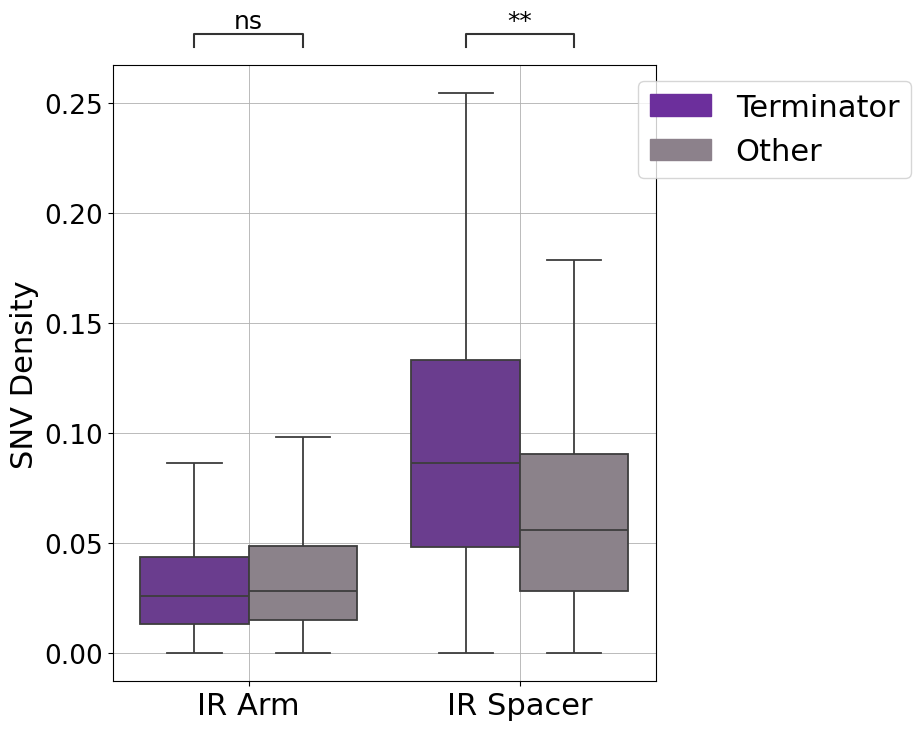

In [37]:
import matplotlib.patches as mpatches 
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from statannotations.Annotator import Annotator

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 8))

palette = {"Terminator": "#6c2f9c", "Other": "#8c818b"}
grouped_features_df_melt = grouped_features_df_melt.with_columns(
    pl.col("mutation_type").str.replace("arm_mutation_rate", "IR Arm")
                           .str.replace("spacer_mutation_rate", "IR Spacer")
)

sns.boxplot(
    data=grouped_features_df_melt.to_pandas(),
    x="mutation_type",
    y="mutation_rate",
    hue="compartment",
    showfliers=False,
    palette=palette,
    linewidth=1.3,
    ax=ax
)

labels = ["Terminator", "Other"]
ax.legend(handles=[mpatches.Patch(label=label, 
                                  color=palette[label]) for label in labels], 
                                  prop={"size": 22},
                                  bbox_to_anchor=(1.5, 1),
          loc="upper right")
pairs = []
for mt in grouped_features_df_melt["mutation_type"].unique():
    pairs.append(
        ((mt, "Terminator"), 
         (mt, "Other"))
    )

annotator = Annotator(
    ax,
    pairs,
    data=grouped_features_df_melt.to_pandas(),
    x="mutation_type",
    y="mutation_rate",
    hue="compartment"
)

annotator.configure(
    test="Mann-Whitney",
    text_format="star",
    fontsize=18,
    comparisons_correction="Bonferroni",
    loc="outside",
    verbose=0
)

annotator.apply_and_annotate()
ax.set_xlabel("")
ax.set_ylabel("SNV Density", fontsize=22)
ax.tick_params(axis="both", labelsize=19)
ax.tick_params(axis="x", labelsize=22)
ax.grid(lw=0.6)
fig.savefig("../../tree_of_life_IR/notebooks/IR_figures/IR_arm_vs_spacer_mutation_rate_boxplot.pdf", 
            bbox_inches="tight", 
            transparent=True)

In [76]:
grouped_features_df = features_ext.group_by(["species_taxid", 
                                             "compartment", 
                                             "spacer_length"]).agg([
                                                 
    pl.col("mut_counts").sum().alias("total_arm_mutations"),
    pl.col("arm_length").sum().alias("total_arm_length"),
    pl.col("mut_counts_spacer").sum().alias("total_spacer_mutations"),
    pl.col("spacer_length").sum().alias("total_spacer_length"),
    pl.col("spacer_length").count().alias("num_arms")
    
])\
.filter(pl.col("num_arms") >= 10)\
.with_columns(
    (pl.col("total_arm_mutations") / pl.col("total_arm_length")).alias("arm_mutation_rate"),
    (pl.col("total_spacer_mutations") / pl.col("total_spacer_length")).alias("spacer_mutation_rate"),
)\
.with_columns(
    (pl.col("spacer_mutation_rate") / pl.col("arm_mutation_rate")).alias("spacer_to_arm_mutation_rate_ratio")
)\
.with_columns(
    pl.col("spacer_to_arm_mutation_rate_ratio")
).sort("spacer_to_arm_mutation_rate_ratio", descending=True)

valid_ids = grouped_features_df.group_by(["species_taxid", "spacer_length"]).agg(
    pl.col("compartment").n_unique().alias("num_compartments")
).filter(pl.col("num_compartments") == 2)

valid_combinations = dict()
for row in valid_ids.iter_rows():
    species = row[0]
    spacer_length = row[1]
    valid_combinations[(species, spacer_length)] = True

grouped_features_df = grouped_features_df.with_columns(
    valid_row=pl.struct(["species_taxid", "spacer_length"]).map_elements(
        lambda row: (row["species_taxid"], row["spacer_length"]) in valid_combinations,
        return_dtype=pl.Boolean
    )
).filter(pl.col("valid_row") == True)

grouped_features_df_melt = grouped_features_df.melt(
    id_vars=["species_taxid", "compartment", "spacer_length"],
    value_vars=["arm_mutation_rate", "spacer_mutation_rate"],
    variable_name="mutation_type",
    value_name="mutation_rate"
)
grouped_features_df_melt.filter(pl.col("species_taxid") == 9).sort(["spacer_length"]).to_pandas()

/var/folders/k2/0c_5sk9n30x2t3srxrtbbp2c0000gr/T/ipykernel_15001/1271747779.py:41: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  grouped_features_df_melt = grouped_features_df.melt(


,species_taxid,compartment,spacer_length,mutation_type,mutation_rate
0,9,Other,8,arm_mutation_rate,0.085859
1,9,Terminator,8,arm_mutation_rate,0.100000
2,9,Other,8,spacer_mutation_rate,0.208333
3,9,Terminator,8,spacer_mutation_rate,0.229167


In [77]:
grouped_features_df_melt = grouped_features_df_melt.with_columns(
    pl.col("mutation_type").str.replace("arm_mutation_rate", "IR Arm")
                           .str.replace("spacer_mutation_rate", "IR Spacer")
)
grouped_features_df_melt

species_taxid,compartment,spacer_length,mutation_type,mutation_rate
i32,str,i64,str,f64
519,"""Other""",4,"""IR Arm""",0.0
28901,"""Terminator""",2,"""IR Arm""",0.0
35814,"""Other""",1,"""IR Arm""",0.0
624,"""Other""",7,"""IR Arm""",0.0
35814,"""Other""",7,"""IR Arm""",0.0
…,…,…,…,…
1263550,"""Terminator""",7,"""IR Spacer""",0.0
633,"""Other""",7,"""IR Spacer""",0.0
67780,"""Terminator""",5,"""IR Spacer""",0.0


In [78]:
2712 / (2 * 8)

169.5

In [88]:
from scipy.stats import mannwhitneyu
import polars as pl
import numpy as np
from scipy.stats import mannwhitneyu
import numpy as np

def map_stars(pval: float) -> str:
    if pval < 1e-4:
        return "****"
    elif pval < 1e-3:
        return "***"
    elif pval < 1e-2:
        return "**"
    elif pval < 0.05:
        return "*"
    else:
        return "ns"

partition_list = list(range(1, 9))
types = ["IR Arm", "IR Spacer"]
effect_sizes = []
for partition in partition_list:

    temp_all_df = grouped_features_df_melt.filter(pl.col("spacer_length") == partition)
    if temp_all_df.height == 0:
        continue

    for typ in types:
        temp_df = temp_all_df.filter(pl.col("mutation_type") == typ)
        term = temp_df.filter(pl.col("compartment") == "Terminator")["mutation_rate"].to_numpy()
        other = temp_df.filter(pl.col("compartment") == "Other")["mutation_rate"].to_numpy()

        _, p = wilcoxon(term, other, alternative="two-sided", zero_method="wilcox")
        # Paired CLES
        diff = term - other
        cles = (np.sum(diff > 0) + 0.5 * np.sum(diff == 0)) / len(diff)
        cliffs_delta = 2 * cles - 1
        
        effect_sizes.append({
            "type": typ,
            "partition": partition,
            "cles": cles,
            "cliffs_delta": cliffs_delta,
            "p_value": p
        })

effect_sizes = pd.DataFrame(effect_sizes)
effect_sizes.loc[:, "q-val"] = multipletests(effect_sizes["p_value"], method="fdr_bh")[1]
effect_sizes.loc[:, "stars"] = effect_sizes["q-val"].apply(map_stars)
effect_sizes


,type,partition,cles,cliffs_delta,p_value,q-val,stars
0,IR Arm,1,0.414634,-0.170732,2.637657e-01,4.107114e-01,ns
1,IR Spacer,1,0.792683,0.585366,4.979517e-09,7.967227e-08,****
2,IR Arm,2,0.430233,-0.139535,3.080336e-01,4.107114e-01,ns
3,IR Spacer,2,0.674419,0.348837,1.626347e-05,1.301078e-04,***
4,IR Arm,3,0.428571,-0.142857,3.521228e-01,4.333819e-01,ns
5,IR Spacer,3,0.642857,0.285714,1.669677e-03,4.452472e-03,**
6,IR Arm,4,0.500000,0.000000,6.872346e-01,7.330503e-01,ns
7,IR Spacer,4,0.642045,0.284091,2.307411e-03,5.274083e-03,**
8,IR Arm,5,0.482353,-0.035294,2.020341e-01,3.591717e-01,ns
9,IR Spacer,5,0.641176,0.282353,1.757722e-04,7.417986e-04,***


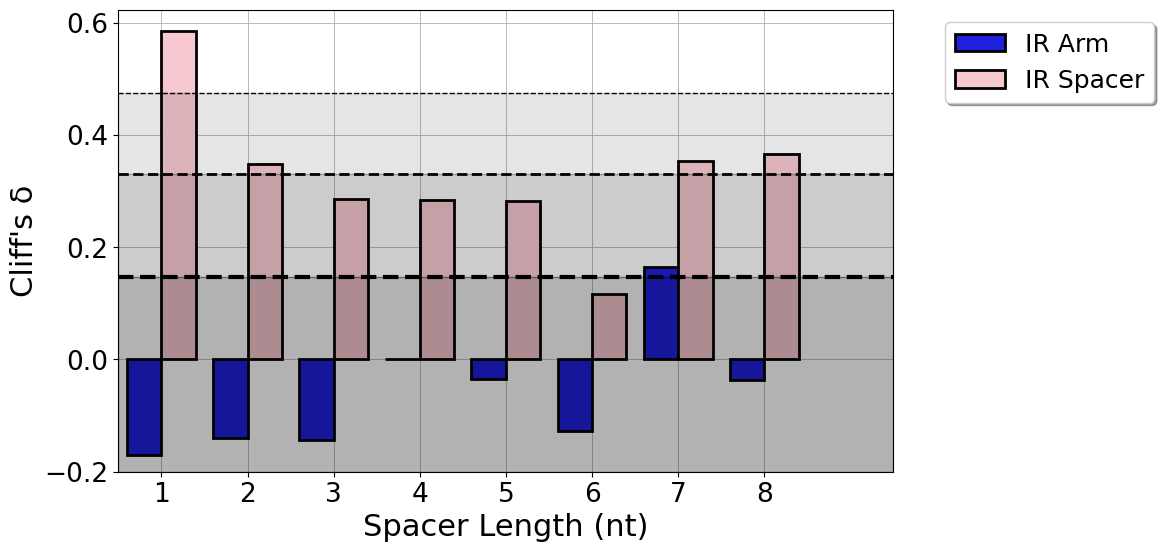

In [116]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 6))

hue_order = ["IR Arm", "IR Spacer"]
partition_order = sorted(effect_sizes["partition"].unique())
sns.barplot(data=effect_sizes, 
            x="partition", 
            y="cliffs_delta", 
            hue="type", 
            order=partition_order,
            hue_order=hue_order,
            palette={"IR Arm": "blue", 
                     "IR Spacer": "pink"}, 
                     linewidth=2, 
                    edgecolor="black")
ax.axhline(0.474, ls="--", color="black", lw=1.0)
ax.axhline(0.33, ls="--", color="black", lw=2.0)
ax.axhline(0.147, ls="--", color="black", lw=3.0)
ax.set_xlim(-0.5, 8.5)
ax.set_ylim(-0.2)
ax.fill_betweenx(y=[0.147, 0.33], x1=ax.get_xlim()[0], x2=ax.get_xlim()[1], color="black", alpha=0.2)
ax.fill_betweenx(y=[ax.get_ylim()[0], 0.147], x1=ax.get_xlim()[0], x2=ax.get_xlim()[1], color="black", alpha=0.3)
ax.fill_betweenx(y=[0.33, 0.474], x1=ax.get_xlim()[0], x2=ax.get_xlim()[1], color="black", alpha=0.1)

ax.grid(lw=0.6)
# ax.set_ylim(ymin=-1.0, ymax=1.0)
ax.set_axisbelow(True)
ax.set_ylabel("Cliff's δ", fontsize=22)
ax.tick_params(axis="both", labelsize=19)
ax.set_xlabel("Spacer Length (nt)", fontsize=22)
ax.legend(title="", 
          frameon=True, 
          shadow=True, 
          bbox_to_anchor=(1.05, 1), 
          loc="upper left", 
          prop={"size": 18})

fig.savefig("../../tree_of_life_IR/notebooks/IR_figures/IR_arm_vs_spacer_mutation_rate_CLES_barplot.pdf", 
            bbox_inches="tight", 
            transparent=True)

In [117]:
grouped_features_df = features_ext.group_by("species_taxid").agg([
    pl.col("mut_counts").sum().alias("total_arm_mutations"),
    pl.col("arm_length").sum().alias("total_arm_length"),
    pl.col("mut_counts_spacer").sum().alias("total_spacer_mutations"),
    pl.col("spacer_length").sum().alias("total_spacer_length"),
])\
.with_columns(
    (pl.col("total_arm_mutations") / pl.col("total_arm_length")).alias("arm_mutation_rate"),
    (pl.col("total_spacer_mutations") / pl.col("total_spacer_length")).alias("spacer_mutation_rate"),
)\
.with_columns(
    (pl.col("spacer_mutation_rate") / pl.col("arm_mutation_rate")).alias("spacer_to_arm_mutation_rate_ratio")
).sort("spacer_to_arm_mutation_rate_ratio", descending=True)

grouped_features_df

species_taxid,total_arm_mutations,total_arm_length,total_spacer_mutations,total_spacer_length,arm_mutation_rate,spacer_mutation_rate,spacer_to_arm_mutation_rate_ratio
i32,i64,i64,i64,i64,f64,f64,f64
783,24,3568,54,1240,0.006726,0.043548,6.474194
519,1,15296,2,5234,0.000065,0.000382,5.844861
624,29,11328,58,4836,0.00256,0.011993,4.684864
545,132,9746,222,3680,0.013544,0.060326,4.454076
731,33,4854,60,2008,0.006799,0.02988,4.395147
…,…,…,…,…,…,…,…
343,300,11126,190,4106,0.026964,0.046274,1.716139
9,257,2712,158,980,0.094764,0.161224,1.701326
28450,584,27398,364,11284,0.021315,0.032258,1.513367


In [118]:
from pybedtools import BedTool 
from collections import defaultdict 
partition_groups = list(range(0, 9)) + ["."]
coverage_data = defaultdict(list)

groups = ["Terminator", "Other", "."]
COVERAGE_FIELDS = ["total_hits", "overlapping_bp", "compartment_length", "coverage"]
for species_taxid, motif_df in tqdm(extended_motifs.items()):
    species_taxid = reference_df.get(species_taxid, None)
    model = models.get(species_taxid, None)
    if model is None:
        continue
    # print(f"Processing species taxid: {species_taxid} with model.")
    # Further processing can be done here using motif_df and model
    
    # trinucleotide context adjustment
    motif_df = (
            motif_df
            .with_columns(
                expected_mutations=pl.col("extended_sequence").map_elements(lambda sequence: predict(model, sequence.upper()), return_dtype=pl.Float64)
            )
    )

    baseline = model.base_rate
    VCF_df = VCFs_df[species_taxid]
    VCF_bed = BedTool.from_dataframe(VCF_df).sort()
    mutation_events = VCF_bed.merge().total_coverage()

    for partition in partition_groups:
        if partition != ".":
            partition_df = motif_df.filter(pl.col("spacer_length") == partition)
        else:
            partition_df = motif_df

        partition_bed = BedTool.from_dataframe(partition_df.select(["seqID", "start", "end"]).to_pandas()).sort()
        total_length = partition_bed.merge().total_coverage()
        total_unmerged_length = partition_df["sequence_length"].sum()
        observed_mutations = pd.read_table(partition_bed.merge().coverage(VCF_bed).fn, header=None, names=["seqID", "start", "end"] + COVERAGE_FIELDS)
        observed_mutations.loc[:, "at_least_one"] = (observed_mutations["total_hits"] > 0).astype(int)
        at_least_one = observed_mutations["at_least_one"].sum()
        observed_mutations = observed_mutations["overlapping_bp"].sum()
        expected_mutations_baseline = total_length * baseline
        if total_unmerged_length == 0:
            expected_mutations_trinucleotide_adjusted = None
        else:
            expected_mutations_trinucleotide_adjusted = partition_df["expected_mutations"].sum() / total_unmerged_length

        if total_length == 0:
            observed_ratio = None
        else:
            observed_ratio = observed_mutations / total_length

        coverage_data["partition"].append(str(partition))
        coverage_data["species_taxid"].append(species_taxid)
        coverage_data["mutation_events"].append(mutation_events)
        coverage_data["total_length"].append(total_length)
        coverage_data["at_least_one"].append(at_least_one)
        coverage_data["observed_mutations"].append(observed_mutations)
        coverage_data["observed_ratio"].append(observed_ratio)
        coverage_data["expected_mutations_baseline"].append(expected_mutations_baseline)
        coverage_data["expected_mutations_trinucleotide_adjusted"].append(expected_mutations_trinucleotide_adjusted)
        coverage_data["baseline"].append(baseline)
        

coverage_data = pd.DataFrame(coverage_data)
coverage_data = (
                pl.from_pandas(coverage_data)
                    .with_columns(enrichment=pl.col("observed_ratio") / pl.col("baseline"))
                    .with_columns(partition=pl.col("partition").cast(pl.Utf8))
                    .sort(["enrichment"], descending=True)
                )
coverage_data


100%|██████████| 98/98 [03:58<00:00,  2.43s/it]


partition,species_taxid,mutation_events,total_length,at_least_one,observed_mutations,observed_ratio,expected_mutations_baseline,expected_mutations_trinucleotide_adjusted,baseline,enrichment
str,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64
"""6""",519,258,1688,1,1,0.000592,0.090841,0.000053,0.000054,11.008278
"""4""",783,6154,854,9,37,0.043326,3.932837,0.005208,0.004605,9.407968
"""5""",519,258,2197,1,1,0.000455,0.118233,0.000054,0.000054,8.457885
"""3""",783,6154,530,8,20,0.037736,2.440753,0.005186,0.004605,8.194191
"""8""",40324,233539,1308,11,144,0.110092,23.059224,0.04722,0.017629,6.244789
…,…,…,…,…,…,…,…,…,…,…
"""4""",519,258,5422,0,0,0.0,0.291788,0.000055,0.000054,0.0
"""7""",519,258,1261,0,0,0.0,0.067861,0.000056,0.000054,0.0
"""8""",519,258,1304,0,0,0.0,0.070176,0.000054,0.000054,0.0


In [19]:
coverage_data.write_csv("IR_coverage_SNV.csv", separator=",")

In [50]:
coverage_data = coverage_data.sort(["enrichment"], descending=True)
coverage_data

partition,species_taxid,mutation_events,total_length,at_least_one,observed_mutations,observed_ratio,expected_mutations_baseline,expected_mutations_trinucleotide_adjusted,baseline,enrichment
str,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64
"""6""",519,258,1688,1,1,0.000592,0.090841,0.000053,0.000054,11.008278
"""4""",783,6154,854,9,37,0.043326,3.932837,0.005208,0.004605,9.407968
"""5""",519,258,2197,1,1,0.000455,0.118233,0.000054,0.000054,8.457885
"""3""",783,6154,530,8,20,0.037736,2.440753,0.005186,0.004605,8.194191
"""8""",40324,233539,1308,11,144,0.110092,23.059224,0.04722,0.017629,6.244789
…,…,…,…,…,…,…,…,…,…,…
"""4""",519,258,5422,0,0,0.0,0.291788,0.000055,0.000054,0.0
"""7""",519,258,1261,0,0,0.0,0.067861,0.000056,0.000054,0.0
"""8""",519,258,1304,0,0,0.0,0.070176,0.000054,0.000054,0.0


<Axes: >

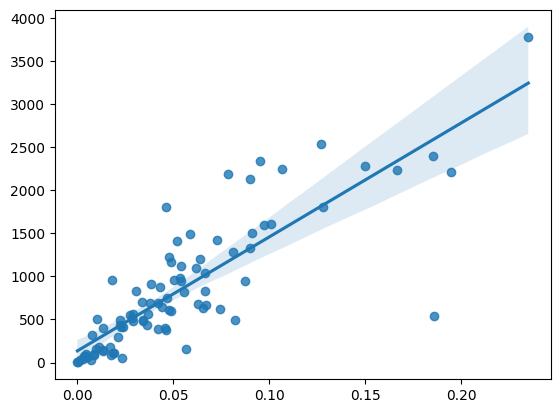

In [51]:
import seaborn as sns 
sns.regplot(data=coverage_data.filter(pl.col("partition") == "."), 
            x="expected_mutations_trinucleotide_adjusted", 
            y="observed_mutations")

<Axes: >

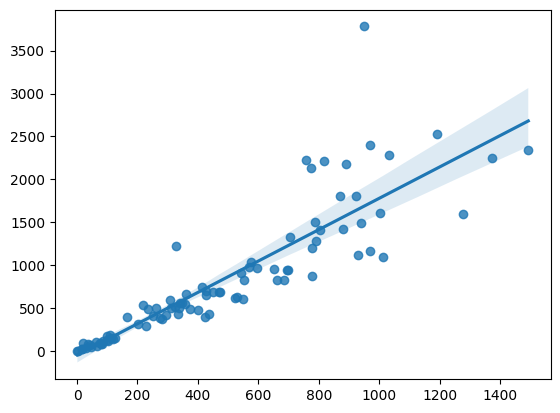

In [52]:

import seaborn as sns 
sns.regplot(data=coverage_data.filter(pl.col("partition") == "."), 
            x="expected_mutations_baseline", 
            y="observed_mutations")

In [119]:
import numpy  as np

assembly_df  = pd.read_table("../assembly_summary_with_tree.csv.gz", 
                             usecols=["species_taxid", "organism_name", "phylum", "genome_size"]
                             )\
            .drop_duplicates(subset=["species_taxid"], 
                             keep="first")

assembly_df.loc[:, "organism_name_reduced"] = assembly_df["organism_name"].apply(lambda x: x.split(" ")[0][0].upper() + ". " + x.split(" ")[1] if len(x.split(" ")) > 1 else x)

In [120]:
assembly_df = pl.from_pandas(assembly_df)
coverage_data_tree = coverage_data.join(
                            assembly_df
                        .select(["species_taxid", "organism_name_reduced", "phylum", "genome_size"]), 
                        
                        on="species_taxid", 
                        how="left"
                    )
coverage_data_tree

partition,species_taxid,mutation_events,total_length,at_least_one,observed_mutations,observed_ratio,expected_mutations_baseline,expected_mutations_trinucleotide_adjusted,baseline,enrichment,organism_name_reduced,phylum,genome_size
str,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,str,str,i64
"""6""",519,258,1688,1,1,0.000592,0.090841,0.000053,0.000054,11.008278,"""B. parapertussis""","""Pseudomonadota""",4773857
"""4""",783,6154,854,9,37,0.043326,3.932837,0.005208,0.004605,9.407968,"""R. rickettsii""","""Pseudomonadota""",1268220
"""5""",519,258,2197,1,1,0.000455,0.118233,0.000054,0.000054,8.457885,"""B. parapertussis""","""Pseudomonadota""",4773857
"""3""",783,6154,530,8,20,0.037736,2.440753,0.005186,0.004605,8.194191,"""R. rickettsii""","""Pseudomonadota""",1268220
"""8""",40324,233539,1308,11,144,0.110092,23.059224,0.04722,0.017629,6.244789,"""S. maltophilia""","""Pseudomonadota""",4739049
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""4""",519,258,5422,0,0,0.0,0.291788,0.000055,0.000054,0.0,"""B. parapertussis""","""Pseudomonadota""",4773857
"""7""",519,258,1261,0,0,0.0,0.067861,0.000056,0.000054,0.0,"""B. parapertussis""","""Pseudomonadota""",4773857
"""8""",519,258,1304,0,0,0.0,0.070176,0.000054,0.000054,0.0,"""B. parapertussis""","""Pseudomonadota""",4773857


In [121]:
coverage_data_tree = coverage_data_tree.with_columns(density=1e3 * pl.col("total_length") / pl.col("genome_size"))

In [122]:
coverage_data_tree_generic = coverage_data_tree.filter(pl.col("partition") == ".")
coverage_data_tree_generic = coverage_data_tree_generic.sort(["enrichment"], descending=True)
coverage_data_tree_generic.to_pandas().head(40)

,partition,species_taxid,mutation_events,total_length,at_least_one,observed_mutations,observed_ratio,expected_mutations_baseline,expected_mutations_trinucleotide_adjusted,baseline,enrichment,organism_name_reduced,phylum,genome_size,density
0,.,783,6154,4579,36,95,0.020747,21.087189,0.004477,0.004605,4.505105,R. rickettsii,Pseudomonadota,1268220,3.610572
1,.,303,1409253,14103,445,3781,0.268099,948.506598,0.234902,0.067256,3.986266,P. putida,Pseudomonadota,6484062,2.175025
2,.,40324,233539,18605,176,1230,0.066111,327.994545,0.047556,0.017629,3.750062,S. maltophilia,Pseudomonadota,4739049,3.925893
3,.,358,996659,12291,377,2231,0.181515,756.595702,0.166484,0.061557,2.948735,A. tumefaciens,Pseudomonadota,5573770,2.205150
4,.,158836,453204,15082,389,2134,0.141493,775.856616,0.089901,0.051443,2.750508,E. hormaechei,Pseudomonadota,4897845,3.079313
5,.,316,866925,11820,379,2214,0.187310,818.795663,0.194396,0.069272,2.703971,S. stutzeri,Pseudomonadota,4547930,2.598985
6,.,317,1083774,13556,424,2401,0.177117,968.395440,0.185116,0.071437,2.479359,P. syringae,Pseudomonadota,6262486,2.164636
7,.,9,135321,3553,83,540,0.151984,219.781133,0.185732,0.061858,2.456990,B. aphidicola,Pseudomonadota,456703,7.779673
8,.,61645,386756,17492,500,2182,0.124743,888.781017,0.078557,0.050811,2.455048,E. asburiae,Pseudomonadota,4806219,3.639451
9,.,287,82570,20589,95,401,0.019476,164.556764,0.013463,0.007992,2.436849,P. aeruginosa,Pseudomonadota,6526814,3.154525


In [123]:
coverage_data_tree_generic = coverage_data_tree_generic\
    .with_columns(
        enrichment_trinucleotide_adjusted=pl.col("observed_ratio") / pl.col("expected_mutations_trinucleotide_adjusted")
    ).with_columns(
    mut_in_spacer_vs_arm_enrichment=pl.col("enrichment") / pl.col("enrichment_trinucleotide_adjusted")
)

coverage_data_tree_generic

partition,species_taxid,mutation_events,total_length,at_least_one,observed_mutations,observed_ratio,expected_mutations_baseline,expected_mutations_trinucleotide_adjusted,baseline,enrichment,organism_name_reduced,phylum,genome_size,density,enrichment_trinucleotide_adjusted,mut_in_spacer_vs_arm_enrichment
str,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,str,str,i64,f64,f64,f64
""".""",783,6154,4579,36,95,0.020747,21.087189,0.004477,0.004605,4.505105,"""R. rickettsii""","""Pseudomonadota""",1268220,3.610572,4.634223,0.972138
""".""",303,1409253,14103,445,3781,0.268099,948.506598,0.234902,0.067256,3.986266,"""P. putida""","""Pseudomonadota""",6484062,2.175025,1.141325,3.492667
""".""",40324,233539,18605,176,1230,0.066111,327.994545,0.047556,0.017629,3.750062,"""S. maltophilia""","""Pseudomonadota""",4739049,3.925893,1.390174,2.697549
""".""",358,996659,12291,377,2231,0.181515,756.595702,0.166484,0.061557,2.948735,"""A. tumefaciens""","""Pseudomonadota""",5573770,2.20515,1.090282,2.704561
""".""",158836,453204,15082,389,2134,0.141493,775.856616,0.089901,0.051443,2.750508,"""E. hormaechei""","""Pseudomonadota""",4897845,3.079313,1.573871,1.747607
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
""".""",28141,170478,15191,222,435,0.028635,437.065407,0.036143,0.028771,0.995274,"""C. sakazakii""","""Pseudomonadota""",4610566,3.294823,0.792283,1.256211
""".""",624,27301,14224,49,65,0.00457,66.898928,0.005266,0.004703,0.971615,"""S. sonnei""","""Pseudomonadota""",4962707,2.866178,0.867727,1.119724
""".""",1355477,38464,25587,54,80,0.003127,82.793285,0.004207,0.003236,0.966262,"""B. diazoefficiens""","""Pseudomonadota""",9106064,2.809886,0.743184,1.300164


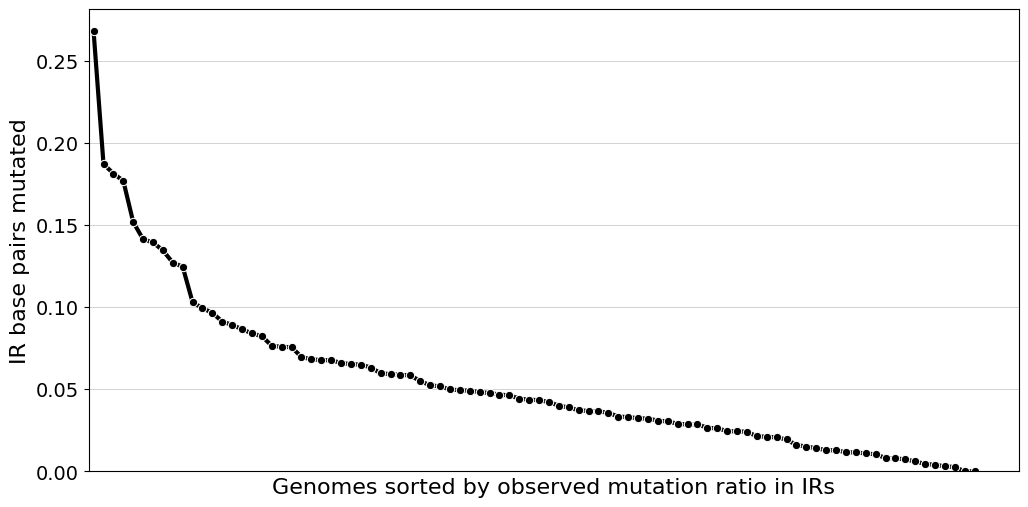

In [124]:
import matplotlib.pyplot as plt 

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=coverage_data_tree_generic.sort(["observed_ratio"], descending=True),
             x="organism_name_reduced", 
             y="observed_ratio", 
             ax=ax,
             color='black',
             marker="o",
             lw=3.0,
             markersize=6,
             )
ax.set_xticks([])
ax.grid(lw=0.4)
ax.set_xlabel("Genomes sorted by observed mutation ratio in IRs", fontsize=16)
ax.set_ylabel("IR base pairs mutated", fontsize=16)
ax.tick_params(axis='y', labelsize=14)
ax.set_xlim(xmin=-0.5)
ax.set_ylim(ymin=0.0)
fig.savefig("IR_figures/genomes_observed_ratio_IRs_SNV.pdf", bbox_inches="tight", transparent=True)

In [125]:
from scipy.stats import binomtest 
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.proportion import proportion_confint

def evaluate_stats(row):
    baseline = row["baseline"]
    total_length = row["total_length"]
    coverage = row["observed_mutations"]
    p_value = binomtest(coverage, n=total_length, p=baseline, alternative="two-sided").pvalue
    ci_lower, ci_upper = proportion_confint(coverage, total_length, method='wilson')
    
    return {
        "p_value": p_value,
        "ci_lower": ci_lower, 
        "ci_upper": ci_upper
    }

stats_results = coverage_data_tree_generic.select([
    "*",
    pl.struct(["baseline", "total_length", "observed_mutations"]).map_elements(
        evaluate_stats, 
        return_dtype=pl.Struct([
            pl.Field("p_value", pl.Float64),
            pl.Field("ci_lower", pl.Float64),
            pl.Field("ci_upper", pl.Float64)
        ])
    ).alias("stats")
]).unnest("stats")

# Add multiple testing correction
adjusted_pvalues = multipletests(stats_results["p_value"].to_list(), method="fdr_bh")[1]
coverage_data_tree_generic = stats_results.with_columns(
    adjusted_p_value=pl.Series(adjusted_pvalues)
)
coverage_data_tree_generic

partition,species_taxid,mutation_events,total_length,at_least_one,observed_mutations,observed_ratio,expected_mutations_baseline,expected_mutations_trinucleotide_adjusted,baseline,enrichment,organism_name_reduced,phylum,genome_size,density,enrichment_trinucleotide_adjusted,mut_in_spacer_vs_arm_enrichment,p_value,ci_lower,ci_upper,adjusted_p_value
str,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,str,str,i64,f64,f64,f64,f64,f64,f64,f64
""".""",783,6154,4579,36,95,0.020747,21.087189,0.004477,0.004605,4.505105,"""R. rickettsii""","""Pseudomonadota""",1268220,3.610572,4.634223,0.972138,2.8700e-32,0.017002,0.025295,7.5971e-32
""".""",303,1409253,14103,445,3781,0.268099,948.506598,0.234902,0.067256,3.986266,"""P. putida""","""Pseudomonadota""",6484062,2.175025,1.141325,3.492667,0.0,0.260852,0.275472,0.0
""".""",40324,233539,18605,176,1230,0.066111,327.994545,0.047556,0.017629,3.750062,"""S. maltophilia""","""Pseudomonadota""",4739049,3.925893,1.390174,2.697549,0.0,0.06263,0.069772,0.0
""".""",358,996659,12291,377,2231,0.181515,756.595702,0.166484,0.061557,2.948735,"""A. tumefaciens""","""Pseudomonadota""",5573770,2.20515,1.090282,2.704561,0.0,0.174801,0.188428,0.0
""".""",158836,453204,15082,389,2134,0.141493,775.856616,0.089901,0.051443,2.750508,"""E. hormaechei""","""Pseudomonadota""",4897845,3.079313,1.573871,1.747607,0.0,0.136022,0.147147,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
""".""",28141,170478,15191,222,435,0.028635,437.065407,0.036143,0.028771,0.995274,"""C. sakazakii""","""Pseudomonadota""",4610566,3.294823,0.792283,1.256211,0.941963,0.0261,0.031409,0.952547
""".""",624,27301,14224,49,65,0.00457,66.898928,0.005266,0.004703,0.971615,"""S. sonnei""","""Pseudomonadota""",4962707,2.866178,0.867727,1.119724,0.902351,0.003587,0.00582,0.922859
""".""",1355477,38464,25587,54,80,0.003127,82.793285,0.004207,0.003236,0.966262,"""B. diazoefficiens""","""Pseudomonadota""",9106064,2.809886,0.743184,1.300164,0.825616,0.002513,0.003889,0.854085


In [126]:
from selenium import webdriver
from selenium.webdriver.firefox.service import Service
from selenium.webdriver.firefox.options import Options

options = Options()
options.add_argument("--headless")
service = Service("/Users/nikolchantzi/.local/share/mamba/envs/biolab/bin/geckodriver")
driver = webdriver.Firefox(service=service, options=options)

In [127]:
from bokeh.models import LabelSet
from bokeh.plotting import reset_output
from bokeh.plotting import figure, show        
from bokeh.models import ColumnDataSource, LabelSet, Span  
from bokeh.io import export_svg
# remove duplicate stars() definition and reset_output()

reset_output()
df = coverage_data_tree_generic.to_pandas()
def stars(p1):
    return "****" if p1 < 1e-4 else ("***" if p1 < 1e-3 else ("**" if p1 < 1e-2 else ("*" if p1 < 0.05 else "")))

def stars(p1):
    if p1 < 1e-4:
        return "*\n*\n*\n*"
    elif p1 < 1e-3:
        return "*\n*\n*\n"
    elif p1 < 1e-2:
        return "*\n*\n"
    elif p1 < 0.05:
        return "*"
    else:
        return ""

stars_data = []
label_col = "organism_name_reduced"
for idx, row in df.iterrows():
    num_stars = 0
    if row["p_value"] < 1e-4:
        num_stars = 4
    elif row["p_value"] < 1e-3:
        num_stars = 3
    elif row["p_value"] < 1e-2:
        num_stars = 2
    elif row["p_value"] < 0.05:
        num_stars = 1
    for i in range(num_stars):
        stars_data.append({
            "x": row[label_col],
            "y": row["enrichment"] + 0.12 * (i + 1),
            "text": "*"
        })
stars_df = pd.DataFrame(stars_data)
source = ColumnDataSource(df)
stars_source = ColumnDataSource(stars_df)

p1 = figure(
    x_range=list(df[label_col]),
    height=500,
    toolbar_location=None,
    width=1400,
    title="",
)
labels = LabelSet(x="x", 
                  y="y", 
                  text="text", 
                  source=stars_source,
                  text_color="black", 
                  text_font_style="bold", 
                  text_font_size="13pt",
                  text_align="center", 
                  text_baseline="middle")
p1.y_range.start = 0
p1.vbar(x=label_col, 
       top="enrichment", 
       width=0.8, 
       color="gray",
       source=source,
       line_color="black")

baseline = Span(location=1, 
                dimension="width", 
                line_color="red", 
                line_dash="dotted", 
                line_width=2.0)
p1.add_layout(baseline)
p1.yaxis.axis_label_text_font_style = "normal"
p1.yaxis.axis_label_text_font_size = "20pt"
p1.xaxis.major_label_text_font_size = "10pt"
p1.yaxis.major_label_text_font_size = "12pt"

p1.xgrid.grid_line_color = None
p1.yaxis.axis_label = "Enrichment"
p1.xaxis.major_label_orientation = 1.2

p1.add_layout(labels)

p1.y_range.end = df["enrichment"].max() + 1.0

outdir = Path("IR_figures/mutation_analysis")
outdir.mkdir(parents=True, exist_ok=True)
export_svg(p1, filename=outdir / "IR_spacer_vs_arm_enrichment.svg", webdriver=driver)
show(p1)

### Trinucleotide Adjustment

In [128]:
coverage_data_tree_generic = coverage_data_tree_generic.with_columns(
    enrichment_trinucleotide_adjusted=pl.col("observed_ratio") / pl.col("expected_mutations_trinucleotide_adjusted")
)

In [129]:
coverage_data_tree_generic

partition,species_taxid,mutation_events,total_length,at_least_one,observed_mutations,observed_ratio,expected_mutations_baseline,expected_mutations_trinucleotide_adjusted,baseline,enrichment,organism_name_reduced,phylum,genome_size,density,enrichment_trinucleotide_adjusted,mut_in_spacer_vs_arm_enrichment,p_value,ci_lower,ci_upper,adjusted_p_value
str,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,str,str,i64,f64,f64,f64,f64,f64,f64,f64
""".""",783,6154,4579,36,95,0.020747,21.087189,0.004477,0.004605,4.505105,"""R. rickettsii""","""Pseudomonadota""",1268220,3.610572,4.634223,0.972138,2.8700e-32,0.017002,0.025295,7.5971e-32
""".""",303,1409253,14103,445,3781,0.268099,948.506598,0.234902,0.067256,3.986266,"""P. putida""","""Pseudomonadota""",6484062,2.175025,1.141325,3.492667,0.0,0.260852,0.275472,0.0
""".""",40324,233539,18605,176,1230,0.066111,327.994545,0.047556,0.017629,3.750062,"""S. maltophilia""","""Pseudomonadota""",4739049,3.925893,1.390174,2.697549,0.0,0.06263,0.069772,0.0
""".""",358,996659,12291,377,2231,0.181515,756.595702,0.166484,0.061557,2.948735,"""A. tumefaciens""","""Pseudomonadota""",5573770,2.20515,1.090282,2.704561,0.0,0.174801,0.188428,0.0
""".""",158836,453204,15082,389,2134,0.141493,775.856616,0.089901,0.051443,2.750508,"""E. hormaechei""","""Pseudomonadota""",4897845,3.079313,1.573871,1.747607,0.0,0.136022,0.147147,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
""".""",28141,170478,15191,222,435,0.028635,437.065407,0.036143,0.028771,0.995274,"""C. sakazakii""","""Pseudomonadota""",4610566,3.294823,0.792283,1.256211,0.941963,0.0261,0.031409,0.952547
""".""",624,27301,14224,49,65,0.00457,66.898928,0.005266,0.004703,0.971615,"""S. sonnei""","""Pseudomonadota""",4962707,2.866178,0.867727,1.119724,0.902351,0.003587,0.00582,0.922859
""".""",1355477,38464,25587,54,80,0.003127,82.793285,0.004207,0.003236,0.966262,"""B. diazoefficiens""","""Pseudomonadota""",9106064,2.809886,0.743184,1.300164,0.825616,0.002513,0.003889,0.854085


In [130]:
from scipy.stats import binomtest 
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.proportion import proportion_confint

def evaluate_stats(row):
    baseline = row["expected_mutations_trinucleotide_adjusted"]
    total_length = row["total_length"]
    coverage = row["observed_mutations"]
    p_value = binomtest(coverage, n=total_length, p=baseline, alternative="two-sided").pvalue
    ci_lower, ci_upper = proportion_confint(coverage, total_length, method='wilson')
    
    return {
        "p_value_adj": p_value,
        "ci_lower_adj": ci_lower, 
        "ci_upper_adj": ci_upper
    }

stats_results = coverage_data_tree_generic.select([
    "*",
    pl.struct(["expected_mutations_trinucleotide_adjusted", 
               "total_length", 
               "observed_mutations"]).map_elements(
        evaluate_stats, 
        return_dtype=pl.Struct([
            pl.Field("p_value_adj", pl.Float64),
            pl.Field("ci_lower_adj", pl.Float64),
            pl.Field("ci_upper_adj", pl.Float64)
        ])
    ).alias("stats")
]).unnest("stats")

# Add multiple testing correction
adjusted_pvalues = multipletests(stats_results["p_value_adj"].to_list(), method="fdr_bh")[1]
coverage_data_tree_generic = stats_results.with_columns(
    adjusted_p_value_triadj=pl.Series(adjusted_pvalues)
)
coverage_data_tree_generic

partition,species_taxid,mutation_events,total_length,at_least_one,observed_mutations,observed_ratio,expected_mutations_baseline,expected_mutations_trinucleotide_adjusted,baseline,enrichment,organism_name_reduced,phylum,genome_size,density,enrichment_trinucleotide_adjusted,mut_in_spacer_vs_arm_enrichment,p_value,ci_lower,ci_upper,adjusted_p_value,p_value_adj,ci_lower_adj,ci_upper_adj,adjusted_p_value_triadj
str,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
""".""",783,6154,4579,36,95,0.020747,21.087189,0.004477,0.004605,4.505105,"""R. rickettsii""","""Pseudomonadota""",1268220,3.610572,4.634223,0.972138,2.8700e-32,0.017002,0.025295,7.5971e-32,3.4652e-33,0.017002,0.025295,7.7968e-32
""".""",303,1409253,14103,445,3781,0.268099,948.506598,0.234902,0.067256,3.986266,"""P. putida""","""Pseudomonadota""",6484062,2.175025,1.141325,3.492667,0.0,0.260852,0.275472,0.0,5.0872e-20,0.260852,0.275472,3.8154e-19
""".""",40324,233539,18605,176,1230,0.066111,327.994545,0.047556,0.017629,3.750062,"""S. maltophilia""","""Pseudomonadota""",4739049,3.925893,1.390174,2.697549,0.0,0.06263,0.069772,0.0,2.1431e-29,0.06263,0.069772,3.8577e-28
""".""",358,996659,12291,377,2231,0.181515,756.595702,0.166484,0.061557,2.948735,"""A. tumefaciens""","""Pseudomonadota""",5573770,2.20515,1.090282,2.704561,0.0,0.174801,0.188428,0.0,0.00001,0.174801,0.188428,0.000025
""".""",158836,453204,15082,389,2134,0.141493,775.856616,0.089901,0.051443,2.750508,"""E. hormaechei""","""Pseudomonadota""",4897845,3.079313,1.573871,1.747607,0.0,0.136022,0.147147,0.0,2.7308e-94,0.136022,0.147147,1.2289e-92
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
""".""",28141,170478,15191,222,435,0.028635,437.065407,0.036143,0.028771,0.995274,"""C. sakazakii""","""Pseudomonadota""",4610566,3.294823,0.792283,1.256211,0.941963,0.0261,0.031409,0.952547,3.1965e-7,0.0261,0.031409,9.5894e-7
""".""",624,27301,14224,49,65,0.00457,66.898928,0.005266,0.004703,0.971615,"""S. sonnei""","""Pseudomonadota""",4962707,2.866178,0.867727,1.119724,0.902351,0.003587,0.00582,0.922859,0.270948,0.003587,0.00582,0.316693
""".""",1355477,38464,25587,54,80,0.003127,82.793285,0.004207,0.003236,0.966262,"""B. diazoefficiens""","""Pseudomonadota""",9106064,2.809886,0.743184,1.300164,0.825616,0.002513,0.003889,0.854085,0.006751,0.002513,0.003889,0.011913


In [133]:
from bokeh.models import LabelSet
from bokeh.plotting import reset_output
from bokeh.plotting import figure, show           
from bokeh.models import ColumnDataSource, LabelSet, Span

# remove duplicate stars() definition and reset_output()

reset_output()
df = coverage_data_tree_generic.sort(["enrichment_trinucleotide_adjusted"], descending=True).to_pandas()

def stars(p1):
    return "****" if p1 < 1e-4 else ("***" if p1 < 1e-3 else ("**" if p1 < 1e-2 else ("*" if p1 < 0.05 else "")))

def stars(p1):
    if p1 < 1e-4:
        return "*\n*\n*\n*"
    elif p1 < 1e-3:
        return "*\n*\n*\n"
    elif p1 < 1e-2:
        return "*\n*\n"
    elif p1 < 0.05:
        return "*"
    else:
        return ""

stars_data = []
label_col = "organism_name_reduced"
for idx, row in df.iterrows():
    num_stars = 0
    if row["p_value_adj"] < 1e-4:   
        num_stars = 4
    elif row["p_value_adj"] < 1e-3:
        num_stars = 3
    elif row["p_value_adj"] < 1e-2:
        num_stars = 2
    elif row["p_value_adj"] < 0.05:
        num_stars = 1
    for i in range(num_stars):
        stars_data.append({
            "x": row[label_col],
            "y": row["enrichment_trinucleotide_adjusted"] + 0.12 * (i + 1),
            "text": "*"
        })
stars_df = pd.DataFrame(stars_data)
source = ColumnDataSource(df)
stars_source = ColumnDataSource(stars_df)

p1 = figure(
    x_range=list(df[label_col]),
    height=500,
    toolbar_location=None,
    width=1200,
    title="",
)
labels = LabelSet(x="x", 
                  y="y", 
                  text="text", 
                  source=stars_source,
                  text_color="black", 
                  text_font_style="bold", 
                  text_font_size="13pt",
                  text_align="center", 
                  text_baseline="middle")
p1.y_range.start = 0
p1.vbar(x=label_col, 
       top="enrichment_trinucleotide_adjusted", 
       width=0.8, 
       color="#c98bae",
       source=source,
       line_color="black")

baseline = Span(location=1, 
                dimension="width", 
                line_color="black", 
                line_dash="dashed", 
                line_width=4.0)
p1.add_layout(baseline)
p1.yaxis.axis_label_text_font_style = "normal"
p1.yaxis.axis_label_text_font_size = "20pt"
p1.xaxis.major_label_text_font_size = "9pt"
p1.yaxis.major_label_text_font_size = "12pt"

p1.xgrid.grid_line_color = None
p1.yaxis.axis_label = "Enrichment (Adjusted)"
p1.xaxis.major_label_orientation = 1.2
p1.add_layout(labels)

p1.y_range.end = df["enrichment_trinucleotide_adjusted"].max() + 1.0

export_svg(p1, filename=outdir / "IR_spacer_vs_arm_enrichment_trinucleotide_adjusted.svg", webdriver=driver)
show(p1)

## Spacer vs Arm

In [134]:
from process_VCF_step_1 import Fastachr_sizes = dict()
for accession_id, fna in tqdm(fasta.items()):
    sizes = Fasta(fna).extract_gs()
    chr_sizes[accession_id] = sizes

SyntaxError: invalid syntax (223262697.py, line 1)

In [135]:
def extend_context(motif_df: pl.DataFrame, fasta, chr_sizes, offset: int = 1):
    extract_id = lambda x: "_".join(Path(fasta).name.split("_")[:2])
    motif_df = (
            motif_df.with_columns(
                chrom_length=pl.col("seqID").map_elements(lambda x: chr_sizes[extract_id(fasta)].size[x], return_dtype=pl.Int32)
            )
            .with_columns(
                extended_start=pl.max_horizontal(pl.col("start") - offset, 0),
                extended_end=pl.min_horizontal(pl.col("end") + offset, pl.col("chrom_length"))
            )
            .with_columns(
                extension_length=pl.col("extended_end") - pl.col("extended_start")
            )
            .filter(
                pl.col("extension_length") == pl.col("sequence_length") + 2
            )
    )
    extended_motif_bed = BedTool.from_dataframe(motif_df.select(["seqID", "extended_start", "extended_end", "start", "end"]).to_pandas()).sort()

    extended_offset_context = extended_motif_bed.sequence(
        fi=fasta, 
        name=True, 
        tab=True
    )
    motifs_with_context = []
    with open(extended_offset_context.seqfn, mode="r", encoding="UTF-8") as f:
        for line in f:
            line = line.strip().split()
            data = line[0]
            extended_sequence = line[1]
            start, data = data.split("::")
            start = int(start)
            seqID, coords = data.split(":")
            extended_start, extended_end = list(map(int, coords.split("-")))
            # if extended_end - extended_start < 2 * offset + 1:
            #     continue
            motifs_with_context.append({
                "seqID": seqID,
                "start": start,
                "extended_sequence": extended_sequence,
                "extended_start": extended_start,
                "extended_end": extended_end,
                "length": extended_end - extended_start - 2,
            })
    motifs_with_context_df = (
                    motifs_df 
                    .join(
                        pl.DataFrame(motifs_with_context)
                            .with_columns(
                                end=pl.col("start") + pl.col("length")
                            ),
                            on=["seqID", "start", "end"],
                            how="left"
                        )
                    )
    assert motifs_with_context_df.height == motif_df.height, "Mismatch in number of motifs after extending context!"
    return motifs_with_context_df

reference_df_1 = {val: key for key, val in reference_df.items()}
species_taxid = 28450
motifs_df = motifs[reference_df_1[species_taxid]]
genome = fasta[reference_df_1[species_taxid]]
motifs_with_context_df = extend_context(motifs_df, genome, chr_sizes, offset=1)
motifs_with_context_df

seqID,start,end,sequence_of_arm,arm_length,sequence_of_spacer,spacer_length,sequence,sequence_length,#assembly_accession,extended_sequence,extended_start,extended_end,length
str,i64,i64,str,i64,str,i64,str,i64,str,str,i64,i64,i64
"""NZ_AP028077.1""",1669,1695,"""gcgcgacgaac""",11,"""gaat""",4,"""gcgcgacgaacgaatgttcgtcgcgc""",26,"""GCF_030297255.1""","""AGCGCGACGAACGAATGTTCGTCGCGCA""",1668,1696,26
"""NZ_AP028077.1""",2982,3012,"""cggttatccac""",11,"""agggtggc""",8,"""cggttatccacagggtggcgtggataaccg""",30,"""GCF_030297255.1""","""GCGGTTATCCACAGGGTGGCGTGGATAACC…",2981,3013,30
"""NZ_AP028077.1""",5785,5815,"""aaaaaacccgctg""",13,"""gttt""",4,"""aaaaaacccgctggtttcagcgggtttttt""",30,"""GCF_030297255.1""","""CAAAAAACCCGCTGGTTTCAGCGGGTTTTT…",5784,5816,30
"""NZ_AP028077.1""",10841,10867,"""cgccgaagttgcg""",13,""".""",0,"""cgccgaagttgcgcgcaacttcggcg""",26,"""GCF_030297255.1""","""TCGCCGAAGTTGCGCGCAACTTCGGCGC""",10840,10868,26
"""NZ_AP028077.1""",27596,27624,"""cggcaggcggcg""",12,"""cttt""",4,"""cggcaggcggcgctttcgccgcctgccg""",28,"""GCF_030297255.1""","""CCGGCAGGCGGCGCTTTCGCCGCCTGCCGC""",27595,27625,28
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""NZ_AP028078.1""",3126674,3126696,"""cggcacgcgca""",11,""".""",0,"""cggcacgcgcatgcgcgtgccg""",22,"""GCF_030297255.1""","""TCGGCACGCGCATGCGCGTGCCGG""",3126673,3126697,22
"""NZ_AP028078.1""",3126948,3126976,"""cgcgcgcggc""",10,"""ggcgcgaa""",8,"""cgcgcgcggcggcgcgaagccgcgcgcg""",28,"""GCF_030297255.1""","""GCGCGCGCGGCGGCGCGAAGCCGCGCGCGA""",3126947,3126977,28
"""NZ_AP028078.1""",3126962,3126988,"""cgaagccgcg""",10,"""cgcgac""",6,"""cgaagccgcgcgcgaccgcggcttcg""",26,"""GCF_030297255.1""","""GCGAAGCCGCGCGCGACCGCGGCTTCGA""",3126961,3126989,26


In [136]:
from scipy.stats import wilcoxon 

def extract_arm_spacer_mutation_burden(VCF_df: pl.DataFrame, 
                                       motifs_df: pl.DataFrame, 
                                       model: dict[str, float], 
                                       partition_list: list,
                                       partition_col: str = "spacer_length",
                                       reference: Optional[str] = None) -> dict[str, int]:
    
    def _extract_sequence_parts(seq, arm_length, a, b, c) -> str:
        start = max(0, b-1) - a 
        end = c + 1 - a
        return seq[start: end]

    motifs_filtered_df = (
        motifs_df
            .filter(pl.col("spacer_length") > 0)
            .with_columns(
                left_arm_start=pl.col("start"),
                left_arm_end=pl.col("start") + pl.col("arm_length"),
                right_arm_start=pl.col("start") + pl.col("arm_length") + pl.col("spacer_length"),
                right_arm_end=pl.col("end"),
                spacer_start=pl.col("start") + pl.col("arm_length"),
                spacer_end=pl.col("start") + pl.col("arm_length") + pl.col("spacer_length")
            )
            .with_columns(
                extended_length=pl.col("extended_end") - pl.col("extended_start")
            )
            .with_columns(
                left_arm_sequence_extended=pl.struct(["extended_sequence", 
                                                    "extended_length",
                                                    "left_arm_start", 
                                                    "left_arm_end", 
                                                    "extended_start"]
                                                ).map_elements(
                                                 lambda row: _extract_sequence_parts(
                                                     row["extended_sequence"], 
                                                     row["extended_length"],
                                                     row["extended_start"],
                                                     row["left_arm_start"],
                                                     row["left_arm_end"]
                                                     ),
                    return_dtype=str
                ),
                right_arm_sequence_extended=pl.struct([
                                                 "extended_sequence", 
                                                 "extended_length",
                                                 "right_arm_start", 
                                                 "right_arm_end", 
                                                 "extended_start"
                                                 ])
                                                 .map_elements(
                                                 lambda row: _extract_sequence_parts(
                                                     row["extended_sequence"], 
                                                     row["extended_length"],
                                                     row["extended_start"],
                                                     row["right_arm_start"],
                                                     row["right_arm_end"]
                                                     ),
                    return_dtype=str
                ),
                spacer_sequence_extended=pl.struct([
                                                 "extended_sequence", 
                                                 "extended_length",
                                                 "spacer_start", 
                                                 "spacer_end", 
                                                 "extended_start"
                                                 ])
                                                 .map_elements(
                                                 lambda row: _extract_sequence_parts(
                                                     row["extended_sequence"], 
                                                     row["extended_length"],
                                                     row["extended_start"],
                                                     row["spacer_start"],
                                                     row["spacer_end"]
                                                    ),
                    return_dtype=str
                )
            )
    )

    motifs_filtered_df = (
        motifs_filtered_df
            .with_columns(
                mut_burden_left_arm=pl.col("left_arm_sequence_extended").map_elements(lambda seq: float(predict(model, seq)), return_dtype=pl.Float64),
                mut_burden_right_arm=pl.col("right_arm_sequence_extended").map_elements(lambda seq: float(predict(model, seq)), return_dtype=pl.Float64),
                mut_burden_spacer=pl.col("spacer_sequence_extended").map_elements(lambda seq: float(predict(model, seq)), return_dtype=pl.Float64)
            )
    )

    SNV_bed = BedTool.from_dataframe(VCF_df).sort()
    for partition in partition_list:
        if partition != ".":
            temp_df = motifs_filtered_df.filter(pl.col(partition_col) == partition)
        else:
            temp_df = motifs_filtered_df

        if temp_df.shape[0] == 0:
            continue

        
        left_arm_bed = BedTool.from_dataframe(
                            temp_df
                                .select(["seqID", "left_arm_start", "left_arm_end", "start", "end"])
                                .to_pandas()
                    ).sort()
        right_arm_bed= BedTool.from_dataframe(
                                temp_df
                                .select(["seqID", "right_arm_start", "right_arm_end", "start", "end"])
                                .to_pandas()
                    ).sort()
        spacer_bed = BedTool.from_dataframe(
                                temp_df
                                .select(["seqID", "spacer_start", "spacer_end", "start", "end"])
                                .to_pandas()
                    ).sort()

        # arm_bed = left_arm_bed.cat(right_arm_bed, postmerge=False) # .merge()
        spacer_bed = spacer_bed # .merge()

        # Calculate Mutation Burden
        mutation_burden_left_arm_bed = left_arm_bed.coverage(SNV_bed)
        mutation_burden_right_arm_bed = right_arm_bed.coverage(SNV_bed)
        mutation_burden_spacer_bed = spacer_bed.coverage(SNV_bed)

        #
        COVERAGE_FIELDS = ["total_hits", "overlapping_bp", "compartment_length", "coverage"]
        mutation_burden_left_arm_df = pl.read_csv(
                    mutation_burden_left_arm_bed.fn,
                    has_header=False,
                    separator="\t",
                    new_columns=["seqID", "start", "end", "IR_start", "IR_end"] + COVERAGE_FIELDS
            ).with_columns(
                            segment_length=pl.col("end")-pl.col("start"),
                        )
        
        mutation_burden_right_arm_df = pl.read_csv(
                    mutation_burden_right_arm_bed.fn,
                    has_header=False,
                    separator="\t",
                    new_columns=["seqID", "start", "end", "IR_start", "IR_end"] + COVERAGE_FIELDS
            ).with_columns(
                            segment_length=pl.col("end")-pl.col("start"),
                        )

        mutation_burden_spacer_df = pl.read_csv(
            mutation_burden_spacer_bed.fn,
            has_header=False,
            separator="\t",
            new_columns=["seqID", "start", "end", "IR_start", "IR_end"] + COVERAGE_FIELDS
        ).with_columns(
            segment_length=pl.col("end")-pl.col("start"),
        )

        total_coverage_arm = (mutation_burden_left_arm_df["overlapping_bp"] + mutation_burden_right_arm_df["overlapping_bp"]).sum()
        total_coverage_spacer = mutation_burden_spacer_df["overlapping_bp"].sum()

        segment_length_arm = (mutation_burden_left_arm_df["segment_length"] + mutation_burden_right_arm_df["segment_length"]).sum()

        assert segment_length_arm == 2 * temp_df["arm_length"].sum(), "Segment length mismatch in arms!"
        segment_length_spacer = mutation_burden_spacer_df["segment_length"].sum()

        expected_baseline_burden_arm = segment_length_arm * model.base_rate
        expected_baseline_burden_spacer = segment_length_spacer * model.base_rate

        # trinucleotide adjustment
        expected_tri_burden_arm = temp_df["mut_burden_left_arm"].sum() + temp_df["mut_burden_right_arm"].sum()
        expected_tri_burden_spacer = temp_df["mut_burden_spacer"].sum()

        observed_arm = (mutation_burden_left_arm_df["overlapping_bp"] + mutation_burden_right_arm_df["overlapping_bp"]).to_numpy()
        observed_spacer = mutation_burden_spacer_df["overlapping_bp"].to_numpy()
        expected_arm_burden = (temp_df["mut_burden_left_arm"] + temp_df["mut_burden_right_arm"]).to_list()
        expected_spacer_burden = temp_df["mut_burden_spacer"].to_list()

        # print(len(observed_arm), len(expected_arm_burden))
        # print(len(observed_spacer), len(expected_spacer_burden))
        assert len(observed_arm) == len(expected_arm_burden), "Length mismatch in arm burden lists!"
        assert len(observed_spacer) == len(expected_spacer_burden), "Length mismatch in spacer burden lists!"
        result_arm = wilcoxon(observed_arm, expected_arm_burden, zero_method="pratt")
        result_spacer = wilcoxon(observed_spacer, expected_spacer_burden, zero_method="pratt")

        # normalized
        observed_arm_normalized = observed_arm / (mutation_burden_left_arm_df["segment_length"] + mutation_burden_right_arm_df["segment_length"]).to_numpy()
        observed_spacer_normalized = observed_spacer / mutation_burden_spacer_df["segment_length"].to_numpy()
        result_combined = wilcoxon(observed_arm_normalized, observed_spacer_normalized, zero_method="pratt")

        yield {
            "partition": partition,
            "coverage_arm": total_coverage_arm,
            "coverage_spacer": total_coverage_spacer,
            "segment_length_arm": segment_length_arm,
            "segment_length_spacer": segment_length_spacer,
            "expected_baseline_burden_arm": expected_baseline_burden_arm,
            "expected_baseline_burden_spacer": expected_baseline_burden_spacer,
            "expected_tri_burden_arm": expected_tri_burden_arm,
            "expected_tri_burden_spacer": expected_tri_burden_spacer,
            "result_arm_statistic": result_arm.statistic,
            "result_arm_pvalue": result_arm.pvalue,
            "result_spacer_statistic": result_spacer.statistic,
            "result_spacer_pvalue": result_spacer.pvalue,
            "result_combined_statistic": result_combined.statistic,
            "result_combined_pvalue": result_combined.pvalue
        }


burden_data = []
partition_list = list(range(0, 9)) + ["."]
for species_taxid, VCF_in in tqdm(vcfs.items()):

    accession_id = reference_df_1[species_taxid]
    model = models.get(species_taxid, None)
    if model is None:
        continue
    if accession_id not in motifs:
        continue
    # accession_id = reference_df[species_taxid]

    species_taxid = int(species_taxid)
    temp_df = extended_motifs[accession_id]
    VCF_df = VCFs_df[species_taxid]

    # READ VCF <<
    # VCF_df = read_VCF(VCF_in)
    # VCF_df = VCF_df.with_columns(
    #     REF_len=pl.col("REF").str.len_chars(),
    #     ALT_len=pl.col("ALT").str.len_chars(),
    # )
    
    # VCF_df = VCF_df.filter(pl.col("REF_len") == 1, pl.col("ALT_len") == 1)

    ## PROCESS <<
    generator = extract_arm_spacer_mutation_burden(
                                        VCF_df=VCF_df, 
                                        motifs_df=temp_df, 
                                        model=model, 
                                        partition_list=partition_list,
                                        partition_col="spacer_length")
    for data in generator:
        burden_data.append({"species_taxid": species_taxid, 
                        "accession_id": accession_id} | data)

if isinstance(assembly_df, pd.DataFrame):
    assembly_df = pl.from_pandas(assembly_df)

burden_data = pl.DataFrame(burden_data).join(assembly_df, on=["species_taxid"], how="left")

burden_data_arm = (
            burden_data
            .select([
                     "partition", 
                     "coverage_arm", 
                     "segment_length_arm", 
                     "expected_baseline_burden_arm", 
                     "result_arm_statistic",
                     "result_arm_pvalue",
                     "organism_name_reduced"])   
            .rename({
                     "coverage_arm": "coverage",
                     "segment_length_arm": "segment_length",
                     "expected_baseline_burden_arm": "expected_baseline_burden",
                     "result_arm_statistic": "result_statistic",
                     "result_arm_pvalue": "result_pvalue"
                }) 
)

burden_data_spacer = (
            burden_data
            .select(["partition", 
                     "coverage_spacer", 
                     "segment_length_spacer", 
                     "expected_baseline_burden_spacer", 
                     "organism_name_reduced",
                     "result_spacer_statistic",
                     "result_spacer_pvalue"
                     ])
            .rename({
                     "coverage_spacer": "coverage",
                     "segment_length_spacer": "segment_length",
                     "expected_baseline_burden_spacer": "expected_baseline_burden",
                     "result_spacer_statistic": "result_statistic",
                     "result_spacer_pvalue": "result_pvalue"
                     }) 
)

burden_data_melt = pl.concat([
                    burden_data_arm.with_columns(region=pl.lit("arm")),
                    burden_data_spacer.with_columns(region=pl.lit("spacer"))
])

burden_data_melt 

  3%|▎         | 3/90 [00:07<03:38,  2.52s/it]/Users/nikolchantzi/.local/share/mamba/envs/biolab/lib/python3.13/site-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
  6%|▌         | 5/90 [00:11<03:20,  2.35s/it]/Users/nikolchantzi/.local/share/mamba/envs/biolab/lib/python3.13/site-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
  8%|▊         | 7/90 [00:14<02:28,  1.79s/it]/Users/nikolchantzi/.local/share/mamba/envs/biolab/lib/python3.13/site-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
 13%|█▎        | 12/90 [00:37<07:17,  5.61s/it]/Users/nikolchantzi/.local/share/mamba/envs/biolab/lib/python3.13/site-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/Users/nikolchantzi/.local/share/mamba/

ShapeError: unable to vstack, column names don't match: "result_statistic" and "organism_name_reduced"

In [138]:
burden_data_arm = (
            burden_data
            .select([
                     "partition", 
                     "coverage_arm", 
                     "segment_length_arm", 
                     "expected_baseline_burden_arm", 
                     "organism_name_reduced",
                     "result_arm_statistic",
                     "result_arm_pvalue"])   
            .rename({
                     "coverage_arm": "coverage",
                     "segment_length_arm": "segment_length",
                     "expected_baseline_burden_arm": "expected_baseline_burden",
                     "result_arm_statistic": "result_statistic",
                     "result_arm_pvalue": "result_pvalue"
                }) 
)

burden_data_spacer = (
            burden_data
            .select(["partition", 
                     "coverage_spacer", 
                     "segment_length_spacer", 
                     "expected_baseline_burden_spacer", 
                     "organism_name_reduced",
                     "result_spacer_statistic",
                     "result_spacer_pvalue"
                     ])
            .rename({
                     "coverage_spacer": "coverage",
                     "segment_length_spacer": "segment_length",
                     "expected_baseline_burden_spacer": "expected_baseline_burden",
                     "result_spacer_statistic": "result_statistic",
                     "result_spacer_pvalue": "result_pvalue"
                     }) 
)

burden_data_melt = pl.concat([
                    burden_data_arm.with_columns(region=pl.lit("arm")),
                    burden_data_spacer.with_columns(region=pl.lit("spacer"))
])

burden_data_melt 

partition,coverage,segment_length,expected_baseline_burden,organism_name_reduced,result_statistic,result_pvalue,region
str,i64,i64,f64,str,f64,f64,str
"""1""",35,2232,14.808494,"""B. glumae""",2327.0,0.317414,"""arm"""
"""2""",14,2400,15.923112,"""B. glumae""",1170.0,7.0059e-7,"""arm"""
"""3""",19,2366,15.697535,"""B. glumae""",1755.0,0.00066,"""arm"""
"""4""",29,4036,26.777367,"""B. glumae""",3381.0,8.9884e-10,"""arm"""
"""5""",28,3312,21.973895,"""B. glumae""",2915.0,0.000007,"""arm"""
…,…,…,…,…,…,…,…
"""5""",35,315,11.899325,"""X. citri""",703.0,0.036791,"""spacer"""
"""6""",25,336,12.692613,"""X. citri""",666.0,0.281597,"""spacer"""
"""7""",23,231,8.726172,"""X. citri""",190.0,0.105863,"""spacer"""


In [139]:
burden_data_arm = (
            burden_data
            .select([
                     "partition", 
                     "coverage_arm", 
                     "segment_length_arm", 
                     "expected_baseline_burden_arm", 
                     "organism_name_reduced",
                     "expected_tri_burden_arm",
                     ])   
            .rename({
                     "coverage_arm": "coverage",
                     "segment_length_arm": "segment_length",
                     "expected_baseline_burden_arm": "expected_baseline_burden",
                     "expected_tri_burden_arm": "expected_tri_burden",

                }) 
)

burden_data_spacer = (
            burden_data
            .select(["partition", 
                     "coverage_spacer", 
                     "segment_length_spacer", 
                     "expected_baseline_burden_spacer", 
                     "organism_name_reduced",
                     "expected_tri_burden_spacer"
                     ])
            .rename({
                     "coverage_spacer": "coverage",
                     "segment_length_spacer": "segment_length",
                     "expected_baseline_burden_spacer": "expected_baseline_burden",
                     "expected_tri_burden_spacer": "expected_tri_burden",
                     }) 
)

burden_data_melt = pl.concat([
                    burden_data_arm.with_columns(region=pl.lit("arm")),
                    burden_data_spacer.with_columns(region=pl.lit("spacer"))
])

burden_data_melt 

partition,coverage,segment_length,expected_baseline_burden,organism_name_reduced,expected_tri_burden,region
str,i64,i64,f64,str,f64,str
"""1""",35,2232,14.808494,"""B. glumae""",16.978944,"""arm"""
"""2""",14,2400,15.923112,"""B. glumae""",18.507063,"""arm"""
"""3""",19,2366,15.697535,"""B. glumae""",18.143536,"""arm"""
"""4""",29,4036,26.777367,"""B. glumae""",31.456731,"""arm"""
"""5""",28,3312,21.973895,"""B. glumae""",25.218701,"""arm"""
…,…,…,…,…,…,…
"""5""",35,315,11.899325,"""X. citri""",17.638873,"""spacer"""
"""6""",25,336,12.692613,"""X. citri""",18.853916,"""spacer"""
"""7""",23,231,8.726172,"""X. citri""",12.497515,"""spacer"""


In [140]:
burden_data["result_combined_pvalue"]

result_combined_pvalue
f64
0.021307
0.737853
0.608118
0.348054
0.021388
…
0.010051
0.274907
0.505557


In [141]:
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

total_IR_0_spacer = burden_data.filter(pl.col("partition") == "0").select(["species_taxid", "coverage_arm", "segment_length_arm"])

burden_data = (
        burden_data
        .with_columns(
                arm_density=pl.col("coverage_arm") / pl.col("segment_length_arm"),
                spacer_density=pl.col("coverage_spacer") / pl.col("segment_length_spacer")
        )
        .with_columns(
            enrichment=pl.col("spacer_density") / pl.col("arm_density")
        )
        .with_columns(
            pvalue=pl.col("result_combined_pvalue").map_elements(lambda x: x if not np.isnan(x) else 1.0, return_dtype=pl.Float64)
        )
)

adjusted_pvalues = multipletests(burden_data["pvalue"].to_list(), method="fdr_bh")[1]
burden_data = (
        burden_data
        .with_columns(
                        adjusted_pvalue=pl.Series(adjusted_pvalues)
                )
        .sort(["enrichment"], descending=True)
)
burden_data_generic = burden_data.filter(pl.col("partition") == ".").sort(["enrichment"], descending=True)
burden_data_generic

species_taxid,accession_id,partition,coverage_arm,coverage_spacer,segment_length_arm,segment_length_spacer,expected_baseline_burden_arm,expected_baseline_burden_spacer,expected_tri_burden_arm,expected_tri_burden_spacer,result_arm_statistic,result_arm_pvalue,result_spacer_statistic,result_spacer_pvalue,result_combined_statistic,result_combined_pvalue,organism_name,genome_size,phylum,organism_name_reduced,arm_density,spacer_density,enrichment,pvalue,adjusted_pvalue
i64,str,str,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,i64,str,str,f64,f64,f64,f64,f64
783,"""GCF_000018225.1""",""".""",27,66,3568,620,16.431336,2.855221,16.062256,2.919239,2770.0,1.5139e-7,3025.0,0.000002,1448.0,0.040516,"""Rickettsia rickettsii""",1268220,"""Pseudomonadota""","""R. rickettsii""",0.007567,0.106452,14.067384,0.040516,0.09821
29459,"""GCF_000007125.1""",""".""",11,15,8150,1487,13.337093,2.433406,13.150441,2.434155,3762.0,2.3913e-45,1725.0,2.4699e-52,1725.0,0.144464,"""Brucella melitensis""",3311767,"""Pseudomonadota""","""B. melitensis""",0.00135,0.010087,7.473864,0.144464,0.268385
731,"""GCF_000019405.1""",""".""",35,46,4854,1004,60.927552,12.602238,85.764812,16.653605,4681.0,4.0073e-13,5684.0,9.4929e-10,3133.0,0.049661,"""Histophilus somni""",2110642,"""Pseudomonadota""","""H. somni""",0.007211,0.045817,6.354126,0.049661,0.116329
519,"""GCF_020735925.1""",""".""",1,1,15296,2617,0.823163,0.140835,0.840721,0.136141,656.0,8.6611e-108,656.0,8.4859e-108,655.0,0.999139,"""Bordetella parapertussis""",4773857,"""Pseudomonadota""","""B. parapertussis""",0.000065,0.000382,5.844861,0.999139,1.0
545,"""GCF_000018045.1""",""".""",139,148,9746,1840,184.515844,34.835743,206.771651,38.751342,26925.0,2.9707e-13,37650.0,0.002086,20082.5,0.000131,"""Citrobacter koseri""",4923281,"""Pseudomonadota""","""C. koseri""",0.014262,0.080435,5.639693,0.000131,0.000765
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2371,"""GCF_028891345.1""",""".""",105,33,2386,433,93.681027,17.00079,135.504531,24.484014,1737.0,0.000535,2590.0,0.439006,2327.5,0.75062,"""Xylella fastidiosa""",2877548,"""Pseudomonadota""","""X. fastidiosa""",0.044007,0.076212,1.731838,0.75062,0.85607
9,"""GCF_000007365.1""",""".""",381,113,2712,490,167.758636,30.310373,498.585673,98.203773,2342.0,0.000743,3432.0,0.604064,2340.5,0.032748,"""Buchnera aphidicola""",456703,"""Pseudomonadota""","""B. aphidicola""",0.140487,0.230612,1.641523,0.032748,0.082378
476,"""GCF_025985205.1""",""".""",94,29,7864,1620,76.927152,15.84715,103.975333,22.658703,11773.0,4.6117e-17,7404.0,2.6195e-28,7046.0,0.651412,"""Moraxella bovis""",2911207,"""Pseudomonadota""","""M. bovis""",0.011953,0.017901,1.49761,0.651412,0.791069


<Axes: xlabel='partition', ylabel='enrichment'>

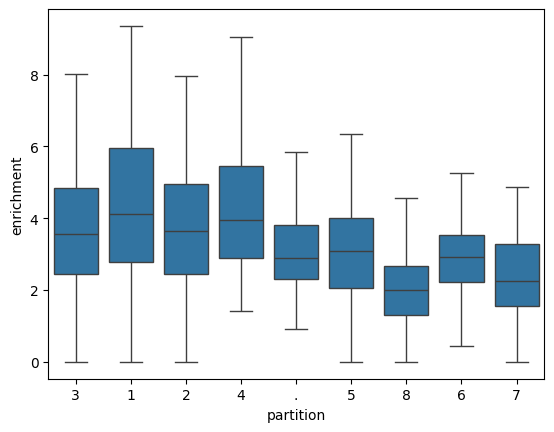

In [142]:
sns.boxplot(data=burden_data.sort(["spacer_density"], descending=True).to_pandas(),
            x="partition",
            y="enrichment",
            showfliers=False,
        )

<Axes: xlabel='partition', ylabel='arm_density'>

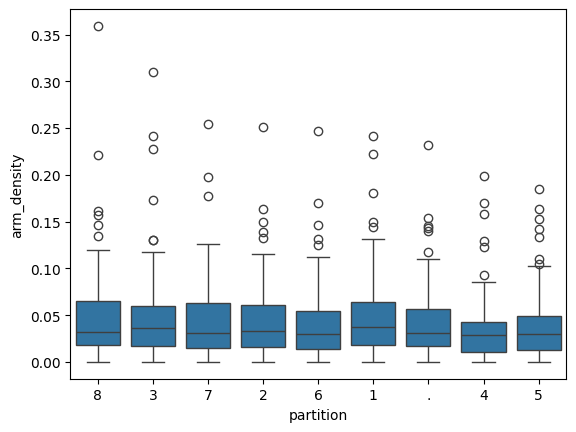

In [143]:
sns.boxplot(data=burden_data.sort(["arm_density"], descending=True).to_pandas(),
            x="partition",
            y="arm_density"
            )

In [144]:
burden_data_generic = burden_data.filter(pl.col("partition") == ".").join(
                            total_IR_0_spacer,
                            on="species_taxid",
                            how="left"
                        ).with_columns(
                                coverage_arm_right=pl.col("coverage_arm_right").fill_null(0.0),
                                segment_length_arm_right=pl.col("segment_length_arm_right").fill_null(0.0),
                            )
burden_data_generic

species_taxid,accession_id,partition,coverage_arm,coverage_spacer,segment_length_arm,segment_length_spacer,expected_baseline_burden_arm,expected_baseline_burden_spacer,expected_tri_burden_arm,expected_tri_burden_spacer,result_arm_statistic,result_arm_pvalue,result_spacer_statistic,result_spacer_pvalue,result_combined_statistic,result_combined_pvalue,organism_name,genome_size,phylum,organism_name_reduced,arm_density,spacer_density,enrichment,pvalue,adjusted_pvalue,coverage_arm_right,segment_length_arm_right
i64,str,str,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,i64,str,str,f64,f64,f64,f64,f64,f64,f64
783,"""GCF_000018225.1""",""".""",27,66,3568,620,16.431336,2.855221,16.062256,2.919239,2770.0,1.5139e-7,3025.0,0.000002,1448.0,0.040516,"""Rickettsia rickettsii""",1268220,"""Pseudomonadota""","""R. rickettsii""",0.007567,0.106452,14.067384,0.040516,0.09821,0.0,0.0
29459,"""GCF_000007125.1""",""".""",11,15,8150,1487,13.337093,2.433406,13.150441,2.434155,3762.0,2.3913e-45,1725.0,2.4699e-52,1725.0,0.144464,"""Brucella melitensis""",3311767,"""Pseudomonadota""","""B. melitensis""",0.00135,0.010087,7.473864,0.144464,0.268385,0.0,0.0
731,"""GCF_000019405.1""",""".""",35,46,4854,1004,60.927552,12.602238,85.764812,16.653605,4681.0,4.0073e-13,5684.0,9.4929e-10,3133.0,0.049661,"""Histophilus somni""",2110642,"""Pseudomonadota""","""H. somni""",0.007211,0.045817,6.354126,0.049661,0.116329,0.0,0.0
519,"""GCF_020735925.1""",""".""",1,1,15296,2617,0.823163,0.140835,0.840721,0.136141,656.0,8.6611e-108,656.0,8.4859e-108,655.0,0.999139,"""Bordetella parapertussis""",4773857,"""Pseudomonadota""","""B. parapertussis""",0.000065,0.000382,5.844861,0.999139,1.0,0.0,0.0
545,"""GCF_000018045.1""",""".""",139,148,9746,1840,184.515844,34.835743,206.771651,38.751342,26925.0,2.9707e-13,37650.0,0.002086,20082.5,0.000131,"""Citrobacter koseri""",4923281,"""Pseudomonadota""","""C. koseri""",0.014262,0.080435,5.639693,0.000131,0.000765,0.0,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2371,"""GCF_028891345.1""",""".""",105,33,2386,433,93.681027,17.00079,135.504531,24.484014,1737.0,0.000535,2590.0,0.439006,2327.5,0.75062,"""Xylella fastidiosa""",2877548,"""Pseudomonadota""","""X. fastidiosa""",0.044007,0.076212,1.731838,0.75062,0.85607,0.0,0.0
9,"""GCF_000007365.1""",""".""",381,113,2712,490,167.758636,30.310373,498.585673,98.203773,2342.0,0.000743,3432.0,0.604064,2340.5,0.032748,"""Buchnera aphidicola""",456703,"""Pseudomonadota""","""B. aphidicola""",0.140487,0.230612,1.641523,0.032748,0.082378,0.0,0.0
476,"""GCF_025985205.1""",""".""",94,29,7864,1620,76.927152,15.84715,103.975333,22.658703,11773.0,4.6117e-17,7404.0,2.6195e-28,7046.0,0.651412,"""Moraxella bovis""",2911207,"""Pseudomonadota""","""M. bovis""",0.011953,0.017901,1.49761,0.651412,0.791069,0.0,0.0


In [145]:
burden_data_generic = burden_data.filter(pl.col("partition") == ".").join(
                            total_IR_0_spacer.with_columns(
                                coverage_arm=pl.col("coverage_arm").fill_null(0.0),
                                segment_length_arm=pl.col("segment_length_arm").fill_null(0.0),
                            ),
                            on="species_taxid",
                            how="left"
                        )\
                        .with_columns(
                                coverage_arm_right=pl.col("coverage_arm_right").fill_null(0.0),
                                segment_length_arm_right=pl.col("segment_length_arm_right").fill_null(0.0),
                            )\
                        .with_columns(
                            coverage_arm=pl.col("coverage_arm") - pl.col("coverage_arm_right"),
                            segment_length_arm=pl.col("segment_length_arm") - pl.col("segment_length_arm_right")
                        )\
                        .with_columns(
                            arm_density=pl.col("coverage_arm") / pl.col("segment_length_arm"),
                            spacer_density=pl.col("coverage_spacer") / pl.col("segment_length_spacer")
                        )\
                        .with_columns(
                            enrichment=pl.col("spacer_density") / pl.col("arm_density")
                        )
burden_data_generic

species_taxid,accession_id,partition,coverage_arm,coverage_spacer,segment_length_arm,segment_length_spacer,expected_baseline_burden_arm,expected_baseline_burden_spacer,expected_tri_burden_arm,expected_tri_burden_spacer,result_arm_statistic,result_arm_pvalue,result_spacer_statistic,result_spacer_pvalue,result_combined_statistic,result_combined_pvalue,organism_name,genome_size,phylum,organism_name_reduced,arm_density,spacer_density,enrichment,pvalue,adjusted_pvalue,coverage_arm_right,segment_length_arm_right
i64,str,str,f64,i64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,i64,str,str,f64,f64,f64,f64,f64,f64,f64
783,"""GCF_000018225.1""",""".""",27.0,66,3568.0,620,16.431336,2.855221,16.062256,2.919239,2770.0,1.5139e-7,3025.0,0.000002,1448.0,0.040516,"""Rickettsia rickettsii""",1268220,"""Pseudomonadota""","""R. rickettsii""",0.007567,0.106452,14.067384,0.040516,0.09821,0.0,0.0
29459,"""GCF_000007125.1""",""".""",11.0,15,8150.0,1487,13.337093,2.433406,13.150441,2.434155,3762.0,2.3913e-45,1725.0,2.4699e-52,1725.0,0.144464,"""Brucella melitensis""",3311767,"""Pseudomonadota""","""B. melitensis""",0.00135,0.010087,7.473864,0.144464,0.268385,0.0,0.0
731,"""GCF_000019405.1""",""".""",35.0,46,4854.0,1004,60.927552,12.602238,85.764812,16.653605,4681.0,4.0073e-13,5684.0,9.4929e-10,3133.0,0.049661,"""Histophilus somni""",2110642,"""Pseudomonadota""","""H. somni""",0.007211,0.045817,6.354126,0.049661,0.116329,0.0,0.0
519,"""GCF_020735925.1""",""".""",1.0,1,15296.0,2617,0.823163,0.140835,0.840721,0.136141,656.0,8.6611e-108,656.0,8.4859e-108,655.0,0.999139,"""Bordetella parapertussis""",4773857,"""Pseudomonadota""","""B. parapertussis""",0.000065,0.000382,5.844861,0.999139,1.0,0.0,0.0
545,"""GCF_000018045.1""",""".""",139.0,148,9746.0,1840,184.515844,34.835743,206.771651,38.751342,26925.0,2.9707e-13,37650.0,0.002086,20082.5,0.000131,"""Citrobacter koseri""",4923281,"""Pseudomonadota""","""C. koseri""",0.014262,0.080435,5.639693,0.000131,0.000765,0.0,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2371,"""GCF_028891345.1""",""".""",105.0,33,2386.0,433,93.681027,17.00079,135.504531,24.484014,1737.0,0.000535,2590.0,0.439006,2327.5,0.75062,"""Xylella fastidiosa""",2877548,"""Pseudomonadota""","""X. fastidiosa""",0.044007,0.076212,1.731838,0.75062,0.85607,0.0,0.0
9,"""GCF_000007365.1""",""".""",381.0,113,2712.0,490,167.758636,30.310373,498.585673,98.203773,2342.0,0.000743,3432.0,0.604064,2340.5,0.032748,"""Buchnera aphidicola""",456703,"""Pseudomonadota""","""B. aphidicola""",0.140487,0.230612,1.641523,0.032748,0.082378,0.0,0.0
476,"""GCF_025985205.1""",""".""",94.0,29,7864.0,1620,76.927152,15.84715,103.975333,22.658703,11773.0,4.6117e-17,7404.0,2.6195e-28,7046.0,0.651412,"""Moraxella bovis""",2911207,"""Pseudomonadota""","""M. bovis""",0.011953,0.017901,1.49761,0.651412,0.791069,0.0,0.0


In [146]:
burden_data_generic = burden_data_generic\
                        .with_columns(
                            pvalue=pl.col("result_combined_pvalue").map_elements(lambda x: x if not np.isnan(x) else 1.0, return_dtype=pl.Float64)
                        )
adjusted_pvalues = multipletests(burden_data_generic["pvalue"].to_list(), method="fdr_bh")[1]
burden_data_generic = (
        burden_data_generic
        .with_columns(
                        adjusted_pvalue=pl.Series(adjusted_pvalues)
                )
        .sort(["enrichment"], descending=True)
)

In [147]:
from bokeh.models import LabelSet
from bokeh.plotting import reset_output
from bokeh.plotting import figure, show           
from bokeh.models import ColumnDataSource, LabelSet, Span 
from bokeh.io import export_svg 

reset_output()
df = burden_data.filter(pl.col("partition") == ".").filter(pl.col("coverage_arm") > 0, pl.col("coverage_spacer") > 0).to_pandas()
df = burden_data_generic.filter(pl.col("partition") == ".").filter(pl.col("coverage_arm") > 0, pl.col("coverage_spacer") > 0).to_pandas()

def stars(p1):
    return "****" if p1 < 1e-4 else ("***" if p1 < 1e-3 else ("**" if p1 < 1e-2 else ("*" if p1 < 0.05 else "")))

stars_data = []
label_col = "organism_name_reduced"
for idx, row in df.iterrows():
    num_stars = 0
    if row["adjusted_pvalue"] < 1e-4:
        num_stars = 4
    elif row["adjusted_pvalue"] < 1e-3:
        num_stars = 3
    elif row["adjusted_pvalue"] < 1e-2:
        num_stars = 2
    elif row["adjusted_pvalue"] < 0.05:
        num_stars = 1
    for i in range(num_stars):
        stars_data.append({
            "x": row[label_col],
            "y": row["enrichment"] + 0.2 * (i + 1),
            "text": "*"
        })
stars_df = pd.DataFrame(stars_data)
source = ColumnDataSource(df)
stars_source = ColumnDataSource(stars_df)

p1 = figure(
    x_range=list(df[label_col]),
    height=500,
    width=1400,
    title="",
)
labels = LabelSet(x="x", 
                  y="y", 
                  text="text", 
                  source=stars_source,
                  text_color="black", 
                  text_font_style="bold", 
                  text_font_size="8pt",
                  text_align="center", 
                  text_baseline="middle"
)
p1.y_range.start = 0
p1.vbar(x=label_col, 
       top="enrichment", 
       width=0.8, 
       source=source,
       line_color="black")

baseline = Span(location=1, 
                dimension="width", 
                line_color="red", 
                line_dash="dotted", 
                line_width=2.0)
p1.add_layout(baseline)

p1.xaxis.axis_label_text_font_style = "italic"
p1.xgrid.grid_line_color = None
p1.yaxis.axis_label = "SNV Density Spacer / SNV Density Arm"
p1.yaxis.axis_label_text_font_style = "bold"
p1.yaxis.axis_label_text_font_size = "14pt"
p1.xaxis.major_label_orientation = 1.2

p1.add_layout(labels)

p1.y_range.end = df["enrichment"].max() + 2.0
outdir = Path("IR_figures/mutation_analysis")
outdir.mkdir(parents=True, exist_ok=True)
export_svg(p1, filename=outdir / "IR_spacer_vs_arm_enrichment.svg", webdriver=driver)
show(p1)

In [148]:
burden_data_generic = burden_data.filter(pl.col("partition") == ".").sort(["enrichment"], descending=True)
burden_data_generic

species_taxid,accession_id,partition,coverage_arm,coverage_spacer,segment_length_arm,segment_length_spacer,expected_baseline_burden_arm,expected_baseline_burden_spacer,expected_tri_burden_arm,expected_tri_burden_spacer,result_arm_statistic,result_arm_pvalue,result_spacer_statistic,result_spacer_pvalue,result_combined_statistic,result_combined_pvalue,organism_name,genome_size,phylum,organism_name_reduced,arm_density,spacer_density,enrichment,pvalue,adjusted_pvalue
i64,str,str,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,i64,str,str,f64,f64,f64,f64,f64
783,"""GCF_000018225.1""",""".""",27,66,3568,620,16.431336,2.855221,16.062256,2.919239,2770.0,1.5139e-7,3025.0,0.000002,1448.0,0.040516,"""Rickettsia rickettsii""",1268220,"""Pseudomonadota""","""R. rickettsii""",0.007567,0.106452,14.067384,0.040516,0.09821
29459,"""GCF_000007125.1""",""".""",11,15,8150,1487,13.337093,2.433406,13.150441,2.434155,3762.0,2.3913e-45,1725.0,2.4699e-52,1725.0,0.144464,"""Brucella melitensis""",3311767,"""Pseudomonadota""","""B. melitensis""",0.00135,0.010087,7.473864,0.144464,0.268385
731,"""GCF_000019405.1""",""".""",35,46,4854,1004,60.927552,12.602238,85.764812,16.653605,4681.0,4.0073e-13,5684.0,9.4929e-10,3133.0,0.049661,"""Histophilus somni""",2110642,"""Pseudomonadota""","""H. somni""",0.007211,0.045817,6.354126,0.049661,0.116329
519,"""GCF_020735925.1""",""".""",1,1,15296,2617,0.823163,0.140835,0.840721,0.136141,656.0,8.6611e-108,656.0,8.4859e-108,655.0,0.999139,"""Bordetella parapertussis""",4773857,"""Pseudomonadota""","""B. parapertussis""",0.000065,0.000382,5.844861,0.999139,1.0
545,"""GCF_000018045.1""",""".""",139,148,9746,1840,184.515844,34.835743,206.771651,38.751342,26925.0,2.9707e-13,37650.0,0.002086,20082.5,0.000131,"""Citrobacter koseri""",4923281,"""Pseudomonadota""","""C. koseri""",0.014262,0.080435,5.639693,0.000131,0.000765
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2371,"""GCF_028891345.1""",""".""",105,33,2386,433,93.681027,17.00079,135.504531,24.484014,1737.0,0.000535,2590.0,0.439006,2327.5,0.75062,"""Xylella fastidiosa""",2877548,"""Pseudomonadota""","""X. fastidiosa""",0.044007,0.076212,1.731838,0.75062,0.85607
9,"""GCF_000007365.1""",""".""",381,113,2712,490,167.758636,30.310373,498.585673,98.203773,2342.0,0.000743,3432.0,0.604064,2340.5,0.032748,"""Buchnera aphidicola""",456703,"""Pseudomonadota""","""B. aphidicola""",0.140487,0.230612,1.641523,0.032748,0.082378
476,"""GCF_025985205.1""",""".""",94,29,7864,1620,76.927152,15.84715,103.975333,22.658703,11773.0,4.6117e-17,7404.0,2.6195e-28,7046.0,0.651412,"""Moraxella bovis""",2911207,"""Pseudomonadota""","""M. bovis""",0.011953,0.017901,1.49761,0.651412,0.791069


In [160]:
from scipy.stats import fisher_exact

burden_data_arm = (
            burden_data
            .select(["species_taxid",
                     "partition", 
                     "coverage_arm", 
                     "segment_length_arm", 
                     "expected_baseline_burden_arm", 
                     "expected_tri_burden_arm",
                     "organism_name_reduced"])   
            .rename({
                     "coverage_arm": "coverage",
                     "segment_length_arm": "segment_length",
                     "expected_baseline_burden_arm": "expected_baseline_burden",
                     "expected_tri_burden_arm": "expected_tri_burden",
                }) 
)

burden_data_spacer = (
            burden_data
            .select(["species_taxid",
                     "partition", 
                     "coverage_spacer", 
                     "segment_length_spacer", 
                     "expected_baseline_burden_spacer", 
                     "expected_tri_burden_spacer",
                     "organism_name_reduced"])
            .rename({
                     "coverage_spacer": "coverage",
                     "segment_length_spacer": "segment_length",
                     "expected_baseline_burden_spacer": "expected_baseline_burden",
                         "expected_tri_burden_spacer": "expected_tri_burden",
                     }) 
)

burden_data_melt = pl.concat([
                    burden_data_arm.with_columns(region=pl.lit("arm")),
                    burden_data_spacer.with_columns(region=pl.lit("spacer"))
               ])

burden_data_melt 

species_taxid,partition,coverage,segment_length,expected_baseline_burden,expected_tri_burden,organism_name_reduced,region
i64,str,i64,i64,f64,f64,str,str
347,"""3""",0,514,3.503514,4.301494,"""X. oryzae""","""arm"""
29459,"""2""",0,416,0.680764,0.67602,"""B. melitensis""","""arm"""
28901,"""6""",0,1120,5.494158,9.644661,"""S. enterica""","""arm"""
519,"""1""",0,2056,0.110645,0.112262,"""B. parapertussis""","""arm"""
519,"""2""",0,1744,0.093854,0.097495,"""B. parapertussis""","""arm"""
…,…,…,…,…,…,…,…
1238,"""3""",0,45,0.716012,0.899627,"""P. salmonis""","""spacer"""
731,"""1""",0,18,0.225937,0.267826,"""H. somni""","""spacer"""
29575,"""1""",0,8,0.048316,0.044552,"""T. equigenitalis""","""spacer"""


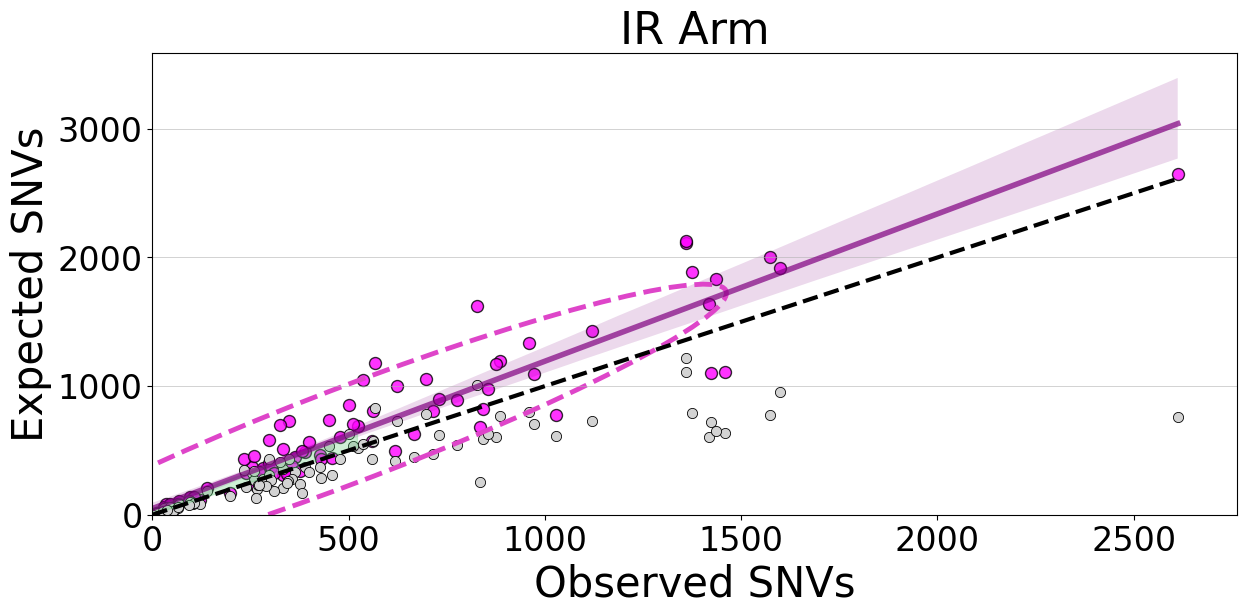

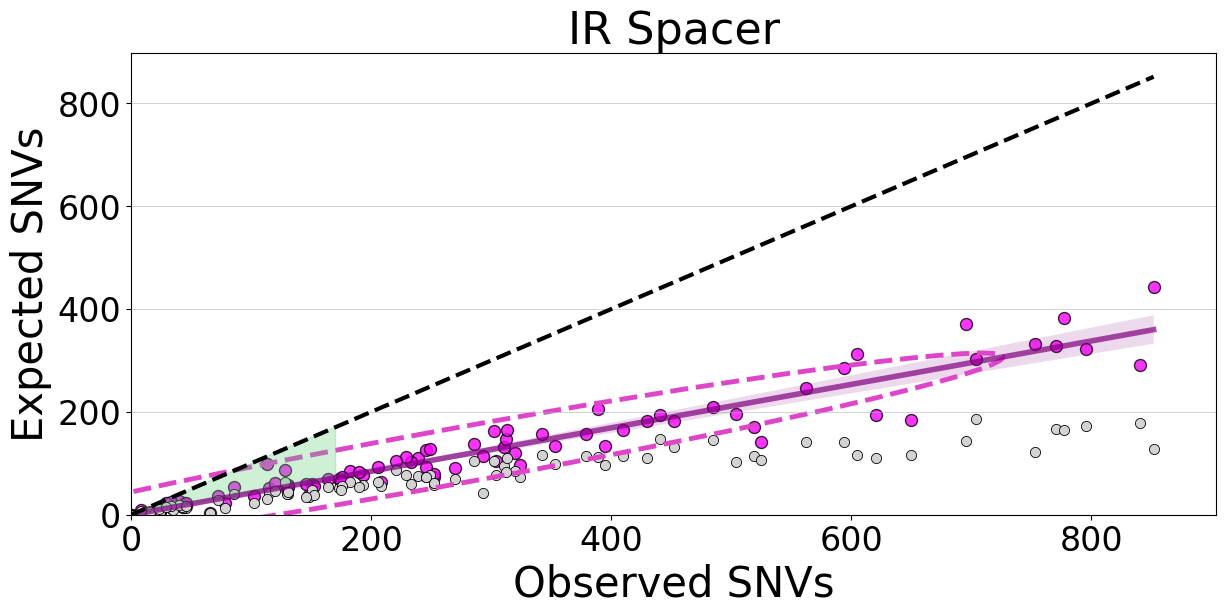

In [166]:
from matplotlib.patches import Ellipse 
import matplotlib.pyplot as plt
import seaborn as sns

target = Path("/Users/nikolchantzi/biolab/tree_of_life_IR/notebooks/IR_figures/to_pdf")
# fig, ax = plt.subplots(nrows=1, ncols=2, figsiz)
def confidence_ellipse(x, y, ax, n_std=2.0, **kwargs):
    cov = np.cov(x, y)
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]

    theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    width, height = 2 * n_std * np.sqrt(vals)
    mean_x, mean_y = np.mean(x), np.mean(y)

    ellipse = Ellipse(
        (mean_x, mean_y),
        width,
        height,
        angle=theta,
        fill=False,
        **kwargs
    )
    ax.add_patch(ellipse)

data_arm = burden_data_melt.filter(pl.col("partition") == ".", pl.col("region") == "arm").to_pandas()
fig, ax = plt.subplots(figsize=(14, 6))
sns.regplot(data=data_arm,          
        y="expected_tri_burden",
        x="coverage", 
        line_kws={"lw": 4.0, "alpha": 0.7, "color": "purple"},
        scatter_kws={"edgecolor": "black", "s": 74, "color": "magenta"},
        ax=ax
)
sns.scatterplot(data=data_arm,
        y="expected_baseline_burden",
        x="coverage",
        color="lightgray",
        edgecolor="black",
        s=54,
        ax=ax,
)

ax = plt.gca()
confidence_ellipse(data_arm["coverage"], data_arm["expected_tri_burden"], ax, n_std=2.0, edgecolor='#de45c9', linestyle='--', linewidth=3.5)
x = np.linspace(0, data_arm["coverage"].max(), 100)
ax.plot(x, x, color='black', linestyle='--', lw=3.0, zorder=5)
ax.set_title("IR Arm", fontsize=32)
ax.set_ylabel("Expected SNVs", fontsize=30)
ax.set_xlabel("Observed SNVs", fontsize=30)
ax.tick_params(axis='both', which='major', labelsize=24)
from matplotlib.patches import Polygon

# Pick a region to highlight (for example, first 20% of x-axis)
x_start = 0
x_end = data_arm["coverage"].max() * 0.2

# Regression line values in that region
from numpy.polynomial.polynomial import Polynomial
coefs = np.polyfit(data_arm["coverage"], data_arm["expected_tri_burden"], 1)
y_reg_start = coefs[0]*x_start + coefs[1]
y_reg_end = coefs[0]*x_end + coefs[1]

# Points for the wedge polygon
verts = [
    (x_start, x_start),        # identity line start
    (x_end, x_end),            # identity line end
    (x_end, y_reg_end),        # regression line end
    (x_start, y_reg_start)     # regression line start
]

poly = Polygon(verts, color="#5dcf77", alpha=0.3)
ax.add_patch(poly)
ax.set_ylim(ymin=0)
ax.set_xlim(xmin=0)
ax.grid(lw=0.4, axis='y')
fig = plt.gcf()
fig.savefig(target/ "IR_arm_expected_vs_observed.pdf", transparent=True, bbox_inches="tight", dpi=300)
plt.show()


fig, ax = plt.subplots(figsize=(14, 6))

data_spacer = burden_data_melt.filter(pl.col("partition") == ".", 
                                      pl.col("region") == "spacer").to_pandas()
sns.regplot(data=data_spacer,          
        y="expected_tri_burden",
        x="coverage",
        line_kws={"lw": 4.0, "alpha": 0.7, "color": "purple"},
        scatter_kws={"edgecolor": "black", "s": 74, "color": "magenta"},
        ax=ax
)
sns.scatterplot(data=data_spacer,
        y="expected_baseline_burden",
        x="coverage",
        color="lightgray",
        edgecolor="black",
        s=54,
        ax=ax,
)

ax = plt.gca()
ax.grid(lw=0.4, axis='y')
confidence_ellipse(data_spacer["coverage"], data_spacer["expected_tri_burden"], ax, n_std=2.0, edgecolor='#de45c9', linestyle='--', linewidth=3.5)
x = np.linspace(0, data_spacer["coverage"].max(), 100)
ax.plot(x, x, color='black', linestyle='--', lw=3.0, zorder=5) 
ax.set_title("IR Spacer", fontsize=32)
ax.set_ylabel("Expected SNVs", fontsize=30)
ax.set_xlabel("Observed SNVs", fontsize=30)
ax.tick_params(axis='both', which='major', labelsize=24)
# Pick a region to highlight (for example, first 20% of x-axis)
x_start = 0
x_end = data_spacer["coverage"].max() * 0.2

# Regression line values in that region
coefs = np.polyfit(data_spacer["coverage"], data_spacer["expected_tri_burden"], 1)
y_reg_start = coefs[0]*x_start + coefs[1]
y_reg_end = coefs[0]*x_end + coefs[1]

# Points for the wedge polygon
verts = [
    (x_start, x_start),        # identity line start
    (x_end, x_end),            # identity line end
    (x_end, y_reg_end),        # regression line end
    (x_start, y_reg_start)     # regression line start
]

poly = Polygon(verts, color="#5dcf77", alpha=0.3)
ax.add_patch(poly)
ax.set_ylim(ymin=0)
ax.set_xlim(xmin=0)
fig = plt.gcf()
fig.savefig(target / "IR_spacer_expected_vs_observed.pdf", transparent=True, bbox_inches="tight", dpi=300)

In [158]:
from bokeh.models import ColumnDataSource, Whisker, LabelSet
from bokeh.plotting import figure, show
from bokeh.transform import jitter, dodge
import pandas as pd
from bokeh.io import export_svg
import numpy as np
from scipy.stats import wilcoxon

domains = ["Bacteria", "Eukaryota", "Archaea", "Viruses"]
expected_color = "#e84d60"
observed_color = "#3c4cba"

hedges_g_list = dict()
wilcoxon_test = dict()

def map_stars(pval):
    if pval < 0.0001:
        return "*" * 4
    elif pval < 0.001:
        return "*" * 3
    elif pval < 0.01:
        return "*" * 2
    elif pval < 0.05:
        return "*"
    return ""
regions = ["IR Arm", "IR Spacer"]
burden_data_melt = burden_data_melt.with_columns(
    region=pl.col("region").replace("arm", "IR Arm").replace("spacer", "IR Spacer")
)
for region in regions:
    obs = burden_data_melt.filter(pl.col("partition") == ".").filter(pl.col("region") == region)[f"coverage"].to_pandas()
    ctrl = burden_data_melt.filter(pl.col("partition") == ".").filter(pl.col("region") == region)[f"expected_baseline_burden"].to_pandas()

    # ---- Wilcoxon signed-rank test (paired) ----
    wilcoxon_res = wilcoxon(obs, ctrl, zero_method="wilcox", alternative="two-sided")
    wilcoxon_test[region] = (wilcoxon_res.statistic, wilcoxon_res.pvalue)
    W = wilcoxon_res.statistic

    diff = obs - ctrl
    cles = (np.sum(diff > 0) + 0.5 * np.sum(diff == 0)) / len(diff)
    print(cles)
    # ---- Paired Hedges' g ----
    diff = obs - ctrl
    n = len(diff)
    sd_diff = np.std(diff, ddof=1)
    d_paired = np.mean(diff) / sd_diff if sd_diff > 0 else np.nan

    # Hedges' correction
    J = 1.0 - (3.0 / (4.0 * n - 1.0)) if n > 1 else 1.0
    g_paired = d_paired * J if not np.isnan(d_paired) else np.nan
    hedges_g_list[region] = g_paired

p = figure(height=300, 
              width=600,
           x_range=regions, 
           title="", 
            output_backend="svg",
           toolbar_location=None)
p.xgrid.grid_line_color = None

alpha = 0.025
quantiles_df = burden_data_melt.filter(pl.col("partition") == ".")\
                                .group_by(["region"]).agg(
                                           pl.col(f"coverage").quantile(alpha/2).alias("lower_ci"),
                                           pl.col(f"coverage").quantile(1-alpha/2).alias("upper_ci"),
                                           pl.col(f"expected_baseline_burden").quantile(alpha/2).alias("lower_ci_control"),
                                           pl.col(f"expected_baseline_burden").quantile(1-alpha/2).alias("upper_ci_control")
                                           )

source_scatter = ColumnDataSource(burden_data_melt.filter(pl.col("partition") == "."))
source_whisker = ColumnDataSource(quantiles_df)
opacity = 0.6

p.scatter(
        jitter("region", width=0.2, range=p.x_range, mean=-0.15),
        f"coverage",
        source=source_scatter, 
        alpha=opacity, 
        size=13, 
        line_color="white", 
        color=observed_color
)

p.scatter(
          jitter("region", width=0.2, range=p.x_range, mean=0.15),
          f"expected_baseline_burden",
          source=source_scatter, 
          alpha=opacity, 
          size=13, 
          line_color="white", 
          color=expected_color)

# Observed whiskers
error_obs = Whisker(base=dodge("region", -0.15, range=p.x_range),
                    upper="upper_ci", 
                    lower="lower_ci", 
                    source=source_whisker,
                    level="annotation", 
                    line_width=3
)
error_obs.upper_head.size = 30
error_obs.lower_head.size = 30
p.add_layout(error_obs)

# Expected whiskers
error_exp = Whisker(base=dodge("region", 0.15, range=p.x_range),
                    upper="upper_ci_control", lower="lower_ci_control", source=source_whisker,
                    level="annotation", line_width=3
)
error_exp.upper_head.size = 30
error_exp.lower_head.size = 30
p.add_layout(error_exp)

# p.y_range.end = 35
upper_ci = quantiles_df.to_pandas().set_index("region")["upper_ci"].to_dict()
annot_df = pd.DataFrame({
    "region": regions,
    "cohen_d": ["g = " + f"{hedges_g_list[region]:.2f}\n" for region in regions],
    "y": [upper_ci[region] for region in regions]
})
source_annot = ColumnDataSource(annot_df)
labels = LabelSet(x="region", 
                  y="y", 
                  text="cohen_d", 
                  source=source_annot,
                  text_font_size="18pt", 
                  text_color="black",
                  x_offset=10,
                  background_fill_color="white", 
                  background_fill_alpha=0.0,
                  text_align="center")
p.add_layout(labels)

annot_df = pd.DataFrame({
    "region": regions,
    "cohen_d": [f"{map_stars(wilcoxon_test[region][1])}" for region in regions],
    "y": [upper_ci[region] * 0.99 for region in regions]
})
source_annot = ColumnDataSource(annot_df)
labels = LabelSet(x="region", 
                  y="y", 
                  text="cohen_d", 
                  source=source_annot,
                  text_font_size="18pt", 
                  text_color="black",
                  x_offset=4,
                  background_fill_color="white", 
                  background_fill_alpha=0.0,
                  text_align="center")
p.add_layout(labels)

p.title.text_font_size = "2pt"
p.title.text_font_style = "normal"
p.title.align = "center"

p.yaxis.axis_label = f"Total SNVs"
p.xaxis.axis_label_text_font_size = "24pt"
p.xaxis.axis_label_text_font_style = "normal"
p.yaxis.axis_label_text_font_size = "24pt"
p.yaxis.axis_label_text_font_style = "normal"

p.xaxis.major_label_text_font_size = "22pt"
p.xaxis.major_label_text_font_style = "normal"
p.yaxis.major_label_text_font_size = "24pt"
p.yaxis.major_label_text_font_style = "normal"
target = Path(f"{pattern}_figures/simulation").resolve()
target.mkdir(parents=True, exist_ok=True)
export_svg(p, filename=target / f"{pattern}_density_vs_control_comparison_g_effect_size_corrected.svg", webdriver=driver)
show(p)
print(target / f"{pattern}_density_vs_control_comparison_g_effect_size_corrected.svg")

0.7111111111111111
0.9888888888888889
/Users/nikolchantzi/biolab/ControlFarmer/VCF_stats/IR_figures/simulation/IR_density_vs_control_comparison_g_effect_size_corrected.svg


In [157]:
from bokeh.models import ColumnDataSource, Whisker, LabelSet
from bokeh.plotting import figure, show
from bokeh.transform import jitter, dodge
import pandas as pd
from bokeh.io import export_svg
import numpy as np
from scipy.stats import ttest_ind

domains = ["Bacteria", "Eukaryota", "Archaea", "Viruses"]
expected_color = "#e84d60"
observed_color = "#3c4cba"

wilcoxon_test = dict()
t_test = dict()
def map_stars(pval):
    if pval < 0.0001:
        return "*" * 4
    elif pval < 0.001:
        return "*" * 3
    elif pval < 0.01:
        return "*" * 2
    elif pval < 0.05:
        return "*"
    return ""
regions = ["IR Arm", "IR Spacer"]
for region in regions:
    obs = burden_data_melt.filter(pl.col("partition") == ".").filter(pl.col("region") == region)[f"coverage"].to_pandas()
    ctrl = burden_data_melt.filter(pl.col("partition") == ".").filter(pl.col("region") == region)[f"expected_tri_burden"].to_pandas()

    # ---- Wilcoxon signed-rank test (paired) ----
    wilcoxon_res = wilcoxon(obs, ctrl, zero_method="wilcox", alternative="two-sided")
    wilcoxon_test[region] = (wilcoxon_res.statistic, wilcoxon_res.pvalue)
    W = wilcoxon_res.statistic

    diff = obs - ctrl
    cles = (np.sum(diff > 0) + 0.5 * np.sum(diff == 0)) / len(diff)
    print(cles)
    # ---- Paired Hedges' g ----
    diff = obs - ctrl
    n = len(diff)
    sd_diff = np.std(diff, ddof=1)
    d_paired = np.mean(diff) / sd_diff if sd_diff > 0 else np.nan

    # Hedges' correction
    J = 1.0 - (3.0 / (4.0 * n - 1.0)) if n > 1 else 1.0
    g_paired = d_paired * J if not np.isnan(d_paired) else np.nan
    hedges_g_list[region] = g_paired



p = figure(height=300, 
           width=600,
           x_range=regions, 
           title="", 
            output_backend="svg",
           toolbar_location=None)
p.xgrid.grid_line_color = None

alpha = 0.025
quantiles_df = burden_data_melt.filter(pl.col("partition") == ".")\
                                .group_by(["region"]).agg(
                                           pl.col(f"coverage").quantile(alpha/2).alias("lower_ci"),
                                           pl.col(f"coverage").quantile(1-alpha/2).alias("upper_ci"),
                                           pl.col(f"expected_tri_burden").quantile(alpha/2).alias("lower_ci_control"),
                                           pl.col(f"expected_tri_burden").quantile(1-alpha/2).alias("upper_ci_control")
                                           )
quantiles_df
source_scatter = ColumnDataSource(burden_data_melt.filter(pl.col("partition") == "."))
source_whisker = ColumnDataSource(quantiles_df)
opacity = 0.6

p.scatter(
        jitter("region", width=0.2, range=p.x_range, mean=-0.15),
        f"coverage",
        source=source_scatter, 
        alpha=opacity, 
        size=13, 
        line_color="white", 
        color=observed_color
)

p.scatter(
          jitter("region", width=0.2, range=p.x_range, mean=0.15),
          f"expected_tri_burden",
          source=source_scatter, 
          alpha=opacity, 
          size=13, 
          line_color="white", 
          color=expected_color)

# Observed whiskers
error_obs = Whisker(base=dodge("region", -0.15, range=p.x_range),
                    upper="upper_ci", 
                    lower="lower_ci", 
                    source=source_whisker,
                    level="annotation", 
                    line_width=3
)
error_obs.upper_head.size = 30
error_obs.lower_head.size = 30
p.add_layout(error_obs)

# Expected whiskers
error_exp = Whisker(base=dodge("region", 0.15, range=p.x_range),
                    upper="upper_ci_control", 
                    lower="lower_ci_control", 
                    source=source_whisker,
                    level="annotation", 
                    line_width=3
)
error_exp.upper_head.size = 30
error_exp.lower_head.size = 30
p.add_layout(error_exp)

# p.y_range.end = 35
upper_ci = quantiles_df.to_pandas().set_index("region")["upper_ci"].to_dict()
annot_df = pd.DataFrame({
    "region": regions,
    "cohen_d": ["g = " + f"{hedges_g_list[region]:.2f}\n" for region in regions],
    "y": [upper_ci[region] * 1.2 for region in regions]
})
source_annot = ColumnDataSource(annot_df)
labels = LabelSet(x="region", 
                  y="y", 
                  text="cohen_d", 
                  source=source_annot,
                  text_font_size="18pt", 
                  text_color="black",
                  x_offset=10,
                  background_fill_color="white", 
                  background_fill_alpha=0.0,
                  text_align="center")
p.add_layout(labels)

annot_df = pd.DataFrame({
    "region": regions,
    "cohen_d": [f"{map_stars(wilcoxon_test[region][1])}" for region in regions],
    "y": [upper_ci[region] * 1.19 for region in regions]
})
source_annot = ColumnDataSource(annot_df)
labels = LabelSet(x="region", 
                  y="y", 
                  text="cohen_d", 
                  source=source_annot,
                  text_font_size="18pt", 
                  text_color="black",
                  x_offset=4,
                  background_fill_color="white", 
                  background_fill_alpha=0.0,
                  text_align="center")
p.add_layout(labels)

p.title.text_font_size = "2pt"
p.title.text_font_style = "normal"
p.title.align = "center"

p.yaxis.axis_label = f"Total SNVs"
p.xaxis.axis_label_text_font_size = "24pt"
p.xaxis.axis_label_text_font_style = "normal"
p.yaxis.axis_label_text_font_size = "24pt"
p.yaxis.axis_label_text_font_style = "normal"

p.xaxis.major_label_text_font_size = "22pt"
p.xaxis.major_label_text_font_style = "normal"
p.yaxis.major_label_text_font_size = "24pt"
p.yaxis.major_label_text_font_style = "normal"
target = Path(f"{pattern}_figures/simulation").resolve()
target.mkdir(parents=True, exist_ok=True)
export_svg(p, filename=target / f"{pattern}_density_vs_control_comparison_g_effect_size_tri_corrected.svg", webdriver=driver)
show(p)
print(target / f"{pattern}_density_vs_control_comparison_g_effect_size_tri_corrected.svg")

0.25555555555555554
0.9777777777777777
/Users/nikolchantzi/biolab/ControlFarmer/VCF_stats/IR_figures/simulation/IR_density_vs_control_comparison_g_effect_size_tri_corrected.svg


## Concerted Evolution: Hairpins

In [473]:
def read_VCF_sample(VCF_in: str) -> pl.DataFrame:
    if Path(VCF_in).name.endswith(".gz"):
        fin = gzip.open(VCF_in, "rt")
    else:
        fin = open(VCF_in, mode="r", encoding="UTF-8")
    names: Optional[list] = None
    for line in fin:
        if line.startswith("##"):
            continue 
        names = line.strip().split()[:9]
        samples = list(map(lambda x: x.split("/")[-1].split(".bam")[0], line.strip().split()[9:]))
        break
    assert names is not None
    # VCF_df = pl.read_csv(fin, has_header=False, separator="\t", columns=range(9), new_columns=names)
    VCF_df = pd.read_table(fin, header=None, names=names + samples)
    attrs = ["AF", "AC"]
    for attr in attrs:
        VCF_df.loc[:, attr] = VCF_df["INFO"].apply(lambda x: float(x.split(f"{attr}=")[1].split(";")[0]))
    VCF_df = pl.from_pandas(VCF_df)

    VCF_df = VCF_df.with_columns(
        ref_length=pl.col("REF").str.len_chars(),
        alt_length=pl.col("ALT").str.len_chars()
    )\
    .with_columns(
        is_snp=pl.col("ref_length")==pl.col("alt_length")
    )\
    .filter(
        pl.col("is_snp") == True
    )
    fin.close()
    return VCF_df, samples


species_taxid = 28450
VCF_df, samples = read_VCF_sample(vcfs[species_taxid])
VCF_df

#CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,FORMAT,GCF_000012785.1,GCF_000015925.1,GCF_000011545.1,GCF_000015905.1,GCF_000260515.1,GCF_000294635.1,GCF_000439695.1,GCF_000494855.1,GCF_000511895.1,GCF_000511915.1,GCF_000520895.1,GCF_000521645.1,GCF_000583835.1,GCF_000755765.1,GCF_000755825.1,GCF_000755905.1,GCF_000755925.1,GCF_000755945.1,GCF_000755965.1,GCF_000756065.1,GCF_000756085.1,GCF_000756125.1,GCF_000756145.1,GCF_000756165.1,GCF_000756185.1,GCF_000757015.2,GCF_000757035.2,GCF_000764575.1,…,GCF_016864355.1,GCF_017378195.1,GCF_017378235.1,GCF_017378275.1,GCF_017378315.2,GCF_017378355.1,GCF_017378435.1,GCF_018228345.1,GCF_018228385.1,GCF_018228525.1,GCF_018228545.1,GCF_018228565.1,GCF_018228585.1,GCF_018228605.1,GCF_018771365.1,GCF_026315005.1,GCF_026315025.1,GCF_026315045.1,GCF_030297195.1,GCF_028201395.1,GCF_030297215.1,GCF_030297235.1,GCF_030297255.1,GCF_030297275.1,GCF_030297295.1,GCF_030297315.1,GCF_030297335.1,GCF_030297355.1,GCF_038983115.1,GCF_038983225.1,GCF_902141795.1,GCF_902141835.1,AF,AC,ref_length,alt_length,is_snp
str,i64,str,str,str,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,…,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,f64,f64,u32,u32,bool
"""NZ_AP028077.1""",82,""".""","""A""","""G""",5130.99,"""PASS""","""DP=135;VDB=0;SGB=-43.177;RPBZ=…","""GT:PL:AD""","""1:60,0:0,1""","""0:0,60:1,0""","""1:60,0:0,1""","""1:60,0:0,1""","""1:60,0:0,1""","""0:0,60:1,0""","""1:60,0:0,1""","""1:60,0:0,1""","""1:60,0:0,1""","""1:60,0:0,1""","""1:60,0:0,1""","""1:60,0:0,1""","""1:60,0:0,1""","""1:60,0:0,1""","""0:0,60:1,0""","""0:0,60:1,0""","""1:60,0:0,1""","""0:0,60:1,0""","""1:60,0:0,1""","""1:60,0:0,1""","""1:60,0:0,1""","""0:0,60:1,0""","""0:0,60:1,0""","""1:60,0:0,1""","""1:60,0:0,1""","""0:0,60:1,0""","""1:60,0:0,1""","""1:60,0:0,1""",…,"""0:0,60:1,0""","""1:60,0:0,1""","""1:60,0:0,1""","""0:0,60:1,0""","""0:0,60:1,0""","""1:60,0:0,1""","""1:60,0:0,1""","""0:0,60:1,0""","""0:0,60:1,0""","""0:0,60:1,0""","""0:0,60:1,0""","""0:0,60:1,0""","""0:0,60:1,0""","""0:0,60:1,0""","""1:60,0:0,1""","""1:60,0:0,1""","""1:60,0:0,1""","""1:60,0:0,1""","""0:0,60:1,0""","""1:60,0:0,1""","""1:60,0:0,1""","""1:60,0:0,1""","""0:0,60:1,0""","""1:60,0:0,1""","""1:60,0:0,1""","""0:0,60:1,0""","""1:60,0:0,1""","""0:0,60:1,0""","""1:60,0:0,1""","""1:60,0:0,1""","""1:60,0:0,1""","""0:0,60:1,0""",0.681481,92.0,1,1,true
"""NZ_AP028077.1""",205,""".""","""G""","""T""",1686.94,"""PASS""","""DP=135;VDB=3.75937e-20;SGB=-19…","""GT:PL:AD""","""0:0,60:1,0""","""0:0,60:1,0""","""0:0,60:1,0""","""0:0,60:1,0""","""0:0,60:1,0""","""0:0,60:1,0""","""1:60,0:0,1""","""1:60,0:0,1""","""1:60,0:0,1""","""0:0,60:1,0""","""0:0,60:1,0""","""0:0,60:1,0""","""1:60,0:0,1""","""1:60,0:0,1""","""0:0,60:1,0""","""0:0,60:1,0""","""0:0,60:1,0""","""0:0,60:1,0""","""0:0,60:1,0""","""0:0,60:1,0""","""0:0,60:1,0""","""0:0,60:1,0""","""0:0,60:1,0""","""0:0,60:1,0""","""1:60,0:0,1""","""0:0,60:1,0""","""0:0,60:1,0""","""0:0,60:1,0""",…,"""0:0,60:1,0""","""0:0,60:1,0""","""0:0,60:1,0""","""0:0,60:1,0""","""0:0,60:1,0""","""0:0,60:1,0""","""0:0,60:1,0""","""0:0,60:1,0""","""0:0,60:1,0""","""0:0,60:1,0""","""0:0,60:1,0""","""0:0,60:1,0""","""0:0,60:1,0""","""0:0,60:1,0""","""0:0,60:1,0""","""0:0,60:1,0""","""0:0,60:1,0""","""0:0,60:1,0""","""0:0,60:1,0""","""0:0,60:1,0""","""0:0,60:1,0""","""0:0,60:1,0""","""0:0,60:1,0""","""0:0,60:1,0""","""0:0,60:1,0""","""0:0,60:1,0""","""0:0,60:1,0""","""0:0,60:1,0""","""0:0,60:1,0""","""0:0,60:1,0""","""0:0,60:1,0""","""0:0,60:1,0""",0.251852,34.0,1,1,true
"""NZ_AP028077.1""",238,""".""","""T""","""C""",4197.29,"""PASS""","""DP=135;VDB=0;SGB=-38.3649;RPBZ…","""GT:PL:AD""","""1:60,0:0,1""","""0:0,60:1,0""","""1:60,0:0,1""","""1:60,0:0,1""","""1:60,0:0,1""","""0:0,60:1,0""","""1:60,0:0,1""","""1:60,0:0,1""","""1:60,0:0,1""","""0:0,60:1,0""","""0:0,60:1,0""","""0:0,60:1,0""","""1:60,0:0

In [ ]:
from uuid import uuid4 
from Bio.Seq import Seq
 
def is_complementary(left, right):
    nucleotides = {'a': 't', 't': 'a', 'g': 'c', 'c': 'g'}
    return nucleotides[left] == right

def extract_arm_spacer_corrections(motifs_df: pl.DataFrame, VCF_df) -> dict[str, int]:
    VCF_df, samples = read_VCF_sample(VCF_df)
    VCF_df = (
            VCF_df
                        .filter(pl.col("is_snp") == True)
                        .with_columns(
                            transition=pl.col("REF") + ">" + pl.col("ALT"),
                            mut_start=pl.col("POS") - 1,
                            mut_end=pl.col("POS")
                        )
        )
    # 
    names = [col for col in VCF_df.columns if col not in samples]
    VCF_df = VCF_df.select(names + samples)
    VCF_bed = BedTool.from_dataframe(
                        VCF_df.select(names)
                        .select(["#CHROM", "mut_start", "mut_end", "transition"])
                        .to_pandas()
                        ).sort()
    assert VCF_bed.count() > 0, "No SNPs found in VCF!"

    # motifs_filtered_df = (
    #     motifs_df
    #         .with_columns(
    #             left_arm_start=pl.col("start"),
    #             left_arm_end=pl.col("start") + pl.col("arm_length"),
    #             right_arm_start=pl.col("start") + pl.col("arm_length") + pl.col("spacer_length"),
    #             right_arm_end=pl.col("end"),
    #             # hairpin_ID=pl.row().map_elements(lambda x: uuid4(x), return_dtype=str)
    #     )
    # )
    # # # # #
    arm_bed = BedTool.from_dataframe(motifs_df.select(["seqID", "start", "end", "arm_length", "spacer_length"]).to_pandas()).sort()
    # left_arm_bed = BedTool.from_dataframe(motifs_filtered_df.select(["seqID", "left_arm_start", "left_arm_end", "start", "end"]).to_pandas()).sort()
    # right_arm_bed= BedTool.from_dataframe(motifs_filtered_df.select(["seqID", "right_arm_start", "right_arm_end", "start", "end"]).to_pandas()).sort()
    
    # # # # #
    POLYMORPHISM_COLUMNS = ["#CHROM", "mut_start", "mut_end", 'transition', 'overlap']
    arm_df = pl.read_csv(
                        arm_bed.intersect(VCF_bed, wo=True).fn,
                        has_header=False,
                        separator="\t",
                        new_columns=["seqID", 
                                     "start", 
                                     "end",
                                     "arm_length",
                                     "spacer_length"] + POLYMORPHISM_COLUMNS
                    )
    arm_df =  (
            arm_df.with_columns(
                left_arm_start=pl.col("start"),
                left_arm_end=pl.col("start") + pl.col("arm_length"),
                right_arm_start=pl.col("start") + pl.col("arm_length") + pl.col("spacer_length"),
                right_arm_end=pl.col("end"),
                # hairpin_ID=pl.row().map_elements(lambda x: uuid4(x), return_dtype=str)
        )
        .with_columns(
            L_count=(pl.col("mut_start") < pl.col("left_arm_end")).cast(pl.Int32),
            R_count=(pl.col("mut_start") >= pl.col("right_arm_start")).cast(pl.Int32),
            S_count=((pl.col("mut_start") >= pl.col("left_arm_end")) & (pl.col("mut_start") < pl.col("right_arm_start"))).cast(pl.Int32)
        )
    )
    # return left_arm_bed, VCF_bed # .intersect(VCF_bed, f=1.0, wo=True)
    # left_arm_df = pl.read_csv(
    #         left_arm_bed.intersect(VCF_bed, wo=True).fn,
    #         has_header=False,
    #         separator="\t",
    #         new_columns=["seqID", "left_arm_start", "left_arm_end", "start", "end"] + POLYMORPHISM_COLUMNS
    # ).with_columns(arm_length=pl.col("left_arm_end") - pl.col("left_arm_start"))

    # right_arm_df = pl.read_csv(
    #             right_arm_bed.intersect(VCF_bed, wo=True).fn,
    #             has_header=False,
    #             separator="\t",
    #             new_columns=["seqID", "right_arm_start", "right_arm_end", "start", "end"] + POLYMORPHISM_COLUMNS
    # ).with_columns(arm_length=pl.col("right_arm_end") - pl.col("right_arm_start"))

    # arm_df = (
    #         left_arm_df.join(
    #             right_arm_df,
    #             on=["seqID", "start", "end", "arm_length"],
    #             how="full",
    #             suffix="_right"
    #         )
    #         .join(
    #             VCF_df,
    #             on=["#CHROM", "mut_start", "mut_end", "transition"],
    #             how="left"
    #         )
    # )
    
    arm_df = (
            arm_df
            .join(
                VCF_df,
                on=["#CHROM", "mut_start", "mut_end", "transition"],
                how="left"
            )
    )

    return {
        "arm": arm_df,
        "samples": samples,
    } 

def process_corrections(arm_df: pl.DataFrame):
    data = []
    non_corrective = arm_df.filter(
        (pl.col("left_arm_start").is_null() & ~pl.col("right_arm_start").is_null()) | (~pl.col("left_arm_start").is_null() & pl.col("right_arm_start").is_null())
    ).shape[0]
    putative_corrections = arm_df.filter(~pl.col("left_arm_start").is_null(), 
                                        ~pl.col("right_arm_start").is_null()
                                        )
    if putative_corrections.shape[0] == 0:
        return pl.DataFrame({
            "seqID": [],
            "start": [],
            "end": [],
            "arm_length": [],
            "left_pos": [],
            "right_pos": [],
            "right_pos_adj": [],
            "same_pos": [],
            "left_var": [],
            "right_var": [],
            "corrective_pair": []
        })
    
    for _, row in putative_corrections.to_pandas().iterrows():
        seqID = row["seqID"]
        start = row["start"]
        end = row["end"]
        
        # left
        left_arm_start = row["left_arm_start"]
        left_mut_start = row["mut_start"]
        arm_length = row["left_arm_end"] - row["left_arm_start"]
        
        # right_mut_start = row["mut_end"]
        left_transition = row["transition"].split(">")
        left_var = left_transition[1].lower()
        rel_left_pos = left_mut_start - left_arm_start

        # right
        right_mut_start = row["mut_start_right"]
        right_arm_start = row["right_arm_start"]
        right_transition = row["transition_right"].split(">")
        right_var = right_transition[1].lower()
        rel_right_pos = right_mut_start - right_arm_start
        rel_right_pos_adj = arm_length - (right_mut_start - right_arm_start) 

        # transition
        corrective_pair = is_complementary(right_var, left_var) and rel_left_pos == rel_right_pos_adj 
        data.append({
            "seqID": seqID,
            "start": start,
            "end": end,
            "arm_length": arm_length,
            "left_pos": rel_left_pos,
            "right_pos": rel_right_pos,
            "right_pos_adj": rel_right_pos_adj,
            "same_pos": rel_left_pos == rel_right_pos_adj,
            "left_var": left_var,
            "right_var": right_var,
            "corrective_pair": corrective_pair
        })
    return pl.DataFrame(data)


corrections_df = []
arm_list = []

for species_taxid, VCF_in in tqdm(vcfs.items()):
    motifs_df = motifs[reference_df_1[species_taxid]]
    assert motifs_df.shape[0] > 0, "No motifs found!"
    try:
        data = extract_arm_spacer_corrections(motifs_df, VCF_in)
    except Exception as e:
        print(f"Error processing {species_taxid}: {e}")
        continue
    arm_df = data["arm"]
    samples = data["samples"]
    arm_list.append(arm_df.with_columns(
        species_taxid=pl.lit(species_taxid),
        organism_name_reduced=pl.lit(assembly_df.filter(pl.col("species_taxid") == species_taxid).select("organism_name_reduced").to_series()[0])
    ))
    # corrections = process_corrections(arm_df)
    # corrections_df.append(corrections.with_columns(
    #     species_taxid=pl.lit(species_taxid),
    #     organism_name_reduced=pl.lit(assembly_df.filter(pl.col("species_taxid") == species_taxid).select("organism_name_reduced").to_series()[0])
    # ))
    break

# corrections_df = pl.concat(corrections_df)
arm_df = pl.concat(arm_list)
arm_df

  0%|          | 0/90 [00:00<?, ?it/s]


ValueError: cannot concat empty list

In [ ]:
sample_frames = []
for sample in samples:
    arm_df.group_by(["species_taxid", "organism_name_reduced", "seqID", "start", "end", "arm_length", "spacer_length"]).agg(
        pl.sum(pl.col(sample)).alias(f"{sample}_mutations"),
        pl.count(pl.col(sample)).alias(f"{sample}_coverage")
    ).with_columns(
        species_taxid=pl.col("species_taxid"),
        organism_name_reduced=pl.col("organism_name_reduced"),
        seqID=pl.col("seqID"),
        start=pl.col("start"),
        end=pl.col("end"),
        arm_length=pl.col("arm_length"),
        spacer_length=pl.col("spacer_length"),
    )
    sample_frames.append(
        arm_df.group_by(["species_taxid", "organism_name_reduced", "seqID", "start", "end", "arm_length", "spacer_length"]).agg(
            pl.sum(pl.col(sample)).alias(f"{sample}_mutations"),
            pl.count(pl.col(sample)).alias(f"{sample}_coverage")
        ).with_columns(
            species_taxid=pl.col("species_taxid"),
            organism_name_reduced=pl.col("organism_name_reduced"),
            seqID=pl.col("seqID"),
            start=pl.col("start"),
            end=pl.col("end"),
            arm_length=pl.col("arm_length"),
            spacer_length=pl.col("spacer_length"),
        )
    )

seqID,start,end,arm_length,spacer_length,#CHROM,mut_start,mut_end,transition,overlap,left_arm_start,left_arm_end,right_arm_start,right_arm_end,L_count,R_count,S_count,POS,ID,REF,ALT,QUAL,FILTER,INFO,FORMAT,AF,AC,ref_length,alt_length,is_snp,GCF_009857095.1,GCF_009578005.1,GCF_000022645.2,GCF_000960995.1,GCF_009931375.1,GCF_012974245.1,GCF_013122645.1,…,GCF_024662435.1,GCF_024662455.1,GCF_024662475.1,GCF_024662615.1,GCF_024662735.1,GCF_024662895.1,GCF_024663135.1,GCF_024663015.1,GCF_024663255.1,GCF_024663375.1,GCF_024663615.1,GCF_024663775.1,GCF_024663895.1,GCF_024663975.1,GCF_024664015.1,GCF_024663995.1,GCF_024664035.1,GCF_024664055.1,GCF_024664075.1,GCF_024664095.1,GCF_024664115.1,GCF_024664135.1,GCF_024664155.1,GCF_024664175.1,GCF_024664195.1,GCF_024664215.1,GCF_024664235.1,GCF_024664255.1,GCF_024760585.1,GCF_024760605.1,GCF_024664275.1,GCF_024760625.1,GCF_026651975.1,GCF_026651995.1,GCF_026652015.1,GCF_024760645.1,GCF_030505635.1
str,i64,i64,i64,i64,str,i64,i64,str,i64,i64,i64,i64,i64,i32,i32,i32,i64,str,str,str,f64,str,str,str,f64,f64,u32,u32,bool,str,str,str,str,str,str,str,…,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""NZ_CP009433.1""",82696,82725,11,7,"""NZ_CP009433.1""",82715,82716,"""C>T""",1,82696,82707,82714,82725,0,1,0,82716,""".""","""C""","""T""",325.076,"""PASS""","""DP=88;VDB=1.51822e-06;SGB=-17.…","""GT:PL:AD""",0.14,7.0,1,1,true,""".:0,0:0,0""","""1:60,0:0,1""","""0:54,54:1,1""","""0:0,60:1,0""","""0:54,54:1,1""",""".:0,0:0,0""","""0:0,60:1,0""",…,"""1:60,0:0,1""","""0:54,54:1,1""","""0:54,54:1,1""","""0:54,54:1,1""","""0:54,54:1,1""","""0:54,54:1,1""","""0:51,101:2,1""","""0:0,60:1,0""","""0:54,54:1,1""","""0:54,54:1,1""","""0:54,54:1,1""","""0:54,54:1,1""","""0:54,54:1,1""","""0:54,54:1,1""","""1:55,0:1,1""","""0:54,54:1,1""","""0:54,54:1,1""","""0:0,110:2,0""","""0:0,60:1,0""","""0:51,111:2,1""","""0:0,60:1,0""","""0:51,101:2,1""","""0:54,54:1,1""","""0:54,54:1,1""","""0:0,110:2,0""","""0:54,54:1,1""","""0:0,60:1,0""","""1:60,0:0,1""","""0:54,54:1,1""","""0:51,101:2,1""","""0:54,54:1,1""","""0:0,60:1,0""","""0:54,54:1,1""","""0:54,54:1,1""","""0:54,54:1,1""","""0:54,54:1,1""","""0:0,110:2,0"""
"""NZ_CP009433.1""",86376,86402,10,6,"""NZ_CP009433.1""",86389,86390,"""A>C""",1,86376,86386,86392,86402,0,0,1,86390,""".""","""A""","""C""",443.874,"""PASS""","""DP=83;VDB=1.3329e-12;SGB=-14.5…","""GT:PL:AD""",0.18,9.0,1,1,true,""".:0,0:0,0""","""1:60,0:0,1""","""0:54,54:1,1""","""0:0,60:1,0""","""0:54,54:1,1""",""".:0,0:0,0""","""0:0,60:1,0""",…,"""1:60,0:0,1""","""0:54,54:1,1""","""0:54,54:1,1""","""0:54,54:1,1""","""0:54,54:1,1""","""0:54,54:1,1""","""0:0,60:1,0""","""0:0,60:1,0""","""0:54,54:1,1""","""0:54,54:1,1""","""0:54,54:1,1""","""0:54,54:1,1""","""0:54,54:1,1""","""0:54,54:1,1""","""1:63,0:0,2""","""0:54,54:1,1""","""0:54,54:1,1""","""0:0,110:2,0""","""1:60,0:0,1""","""0:0,170:3,0""","""0:0,60:1,0""","""0:0,151:3,0""","""0:54,54:1,1""","""0:54,54:1,1""","""0:0,110:2,0""","""1:60,0:0,1""","""0:0,60:1,0""","""1:60,0:0,1""","""0:0,60:1,0""","""0:0,151:3,0""","""0:54,54:1,1""","""0:0,60:1,0""","""0:54,54:1,1""","""0:54,54:1,1""","""0:54,54:1,1""","""0:54,54:1,1""","""0:0,110:2,0"""
"""NZ_CP009433.1""",86376,86402,10,6,"""NZ_CP009433.1""",86395,86396,"""A>G""",1,86376,86386,86392,86402,0,1,0,86396,""".""","""A""","""G""",386.467,"""PASS""","""DP=83;VDB=2.12663e-12;SGB=-14.…","""GT:PL:AD""",0.16,8.0,1,1,true,""".:0,0:0,0""","""1:60,0:0,1""","""0:54,54:1,1""","""0:0,60:1,0""","""0:54,54:1,1""",""".:0,0:0,0""","""0:0,60:1,0""",…,"""1:60,0:0,1""","""0:54,54:1,1""","""0:54,54:1,1""","""0:54,54:1,1""","""0:54,54:1,1""","""0:54,54:1,1""","""0:0,60:1,0""","""0:0,60:1,0""","""0:54,54:1,1""","""0:54,54:1,1""","""0:54,54:1,1""","""0:54,54:1,1""","""0:54,54:1,1""","""0:54,54:1,1""","""1:63,0:0,2""","""0:54,54:1,1""","""0:54,54:1,1""","""0:0,110:2,0""","""1:60,0:0,1""","""0:0,170:3,0""","""0:0,60:1,0""","""0:0,151:3,0"

In [156]:
corrections_df.shape

(111124, 13)

In [160]:
correction_prop = corrections_df.group_by("organism_name_reduced").agg(
    pl.col("corrective_pair").mean() * 100
).sort(["corrective_pair"], descending=True)
correction_prop.head(40).to_pandas()

,organism_name_reduced,corrective_pair
0,C. koseri,7.894737
1,V. alginolyticus,5.418719
2,E. piscicida,5.000000
3,P. poae,4.000000
4,V. harveyi,3.949447
5,V. parahaemolyticus,3.610675
6,P. pseudonitzschiae,3.571429
7,R. ornithinolytica,3.448276
8,E. albertii,3.189066
9,M. haemolytica,3.030303


In [272]:
left_arm = left_arm_df.with_columns(
    rel_pos=100 * (pl.col("mut_start") - pl.col("left_arm_start")) / (pl.col("left_arm_end") - pl.col("left_arm_start"))
)
right_arm = right_arm_df\
        .with_columns(
            arm_length=pl.col("right_arm_end") - pl.col("right_arm_start")
        ).with_columns(
        rel_pos=(pl.col("arm_length") - (pl.col("mut_start") - pl.col("right_arm_start") + 1)) * 100 / pl.col("arm_length")
    )\
    # .with_columns(
    #             rel_pos=((pl.col("mut_start") - pl.col("right_arm_start"))) * 100 / pl.col("arm_length")

    # )
rel_pos_df = pl.concat([left_arm.select(["seqID", "start", "end", "rel_pos", "organism_name_reduced"]).with_columns(group=pl.lit("left")), 
                        right_arm.select(["seqID", "start", "end", "rel_pos", "organism_name_reduced"]).with_columns(group=pl.lit("right"))])
rel_pos_df

seqID,start,end,rel_pos,organism_name_reduced,group
str,i64,i64,f64,str,str
"""NZ_CP009433.1""",146730,146753,81.818182,"""B. glumae""","""left"""
"""NZ_CP009433.1""",147586,147608,9.090909,"""B. glumae""","""left"""
"""NZ_CP009433.1""",147586,147608,54.545455,"""B. glumae""","""left"""
"""NZ_CP009433.1""",147586,147608,90.909091,"""B. glumae""","""left"""
"""NZ_CP009433.1""",160872,160895,90.909091,"""B. glumae""","""left"""
…,…,…,…,…,…
"""NZ_CP008998.1""",5091482,5091513,83.333333,"""X. citri""","""right"""
"""NZ_CP008998.1""",5091482,5091513,75.0,"""X. citri""","""right"""
"""NZ_CP008998.1""",5101178,5101205,45.454545,"""X. citri""","""right"""


In [180]:
rel_pos_df.filter(pl.col("group") == "right", pl.col("rel_pos") == 0)

seqID,start,end,rel_pos,organism_name_reduced,group
str,i64,i64,f64,str,str
"""NZ_CP009433.1""",103113,103139,0.0,"""B. glumae""","""right"""
"""NZ_CP009434.1""",2674686,2674712,0.0,"""B. glumae""","""right"""
"""NZ_CP009435.1""",109667,109692,0.0,"""B. glumae""","""right"""
"""NZ_CP009435.1""",1781703,1781723,0.0,"""B. glumae""","""right"""
"""NZ_CP009435.1""",3460701,3460725,0.0,"""B. glumae""","""right"""
…,…,…,…,…,…
"""NZ_CP008998.1""",4292231,4292262,0.0,"""X. citri""","""right"""
"""NZ_CP008998.1""",4520286,4520314,0.0,"""X. citri""","""right"""
"""NZ_CP008998.1""",4521475,4521499,0.0,"""X. citri""","""right"""


In [ ]:
bin_counts_df = rel_pos_df.with_columns(
    rel_pos_bin=pl.col("rel_pos") // 10,
)


In [238]:
bin_counts_df = rel_pos_df.with_columns(
    rel_pos_bin=pl.col("rel_pos") // 10,
)

total = bin_counts_df.group_by("organism_name_reduced").agg(
    total_counts=pl.col("rel_pos_bin").count(),
)

bin_counts_df = bin_counts_df.group_by("organism_name_reduced", "rel_pos_bin").agg(
    rel_pos_bin_counts=pl.col("rel_pos_bin").count(),
).join(
    total,
    on=["organism_name_reduced"],
    how="left"
).with_columns(
    rel_pos_bin_prop=pl.col("rel_pos_bin_counts") / pl.col("total_counts") * 100
)
bin_counts_df

organism_name_reduced,rel_pos_bin,rel_pos_bin_counts,total_counts,rel_pos_bin_prop
str,f64,u32,u32,f64
"""P. rettgeri""",9.0,267,1753,15.231033
"""P. syringae""",0.0,416,2170,19.170507
"""X. citri""",0.0,133,785,16.942675
"""A. pittii""",8.0,121,1060,11.415094
"""R. pseudosolanacearum""",3.0,55,584,9.417808
…,…,…,…,…
"""R. solanacearum""",3.0,112,969,11.558308
"""X. arboricola""",5.0,120,1210,9.917355
"""S. alvi""",2.0,33,398,8.291457


In [239]:
total = bin_counts_df.group_by("organism_name_reduced").agg(
    total_counts=pl.col("rel_pos_bin").count(),
)

bin_counts_df_all = (
                bin_counts_df.group_by(["rel_pos_bin", "organism_name_reduced"])
                             .agg(
                                pl.col("rel_pos_bin_counts")
                                .sum()
                                .alias("rel_pos_bin_counts"),
                    )
                    .join(
                        total,
                        on=["organism_name_reduced"],
                        how="left"
                    )
                    .with_columns(
                        relative_prop=pl.col("rel_pos_bin_counts") * 100 / pl.col("total_counts")
                    )
)
bin_counts_df_all

rel_pos_bin,organism_name_reduced,rel_pos_bin_counts,total_counts,relative_prop
f64,str,u32,u32,f64
4.0,"""P. poae""",18,10,180.0
0.0,"""M. bovis""",11,10,110.0
9.0,"""A. hydrophila""",287,10,2870.0
8.0,"""P. rettgeri""",162,10,1620.0
7.0,"""K. aerogenes""",43,10,430.0
…,…,…,…,…
9.0,"""X. citri""",82,10,820.0
2.0,"""P. protegens""",206,10,2060.0
0.0,"""A. baumannii""",96,10,960.0


<Axes: xlabel='rel_pos_bin', ylabel='organism_name_reduced'>

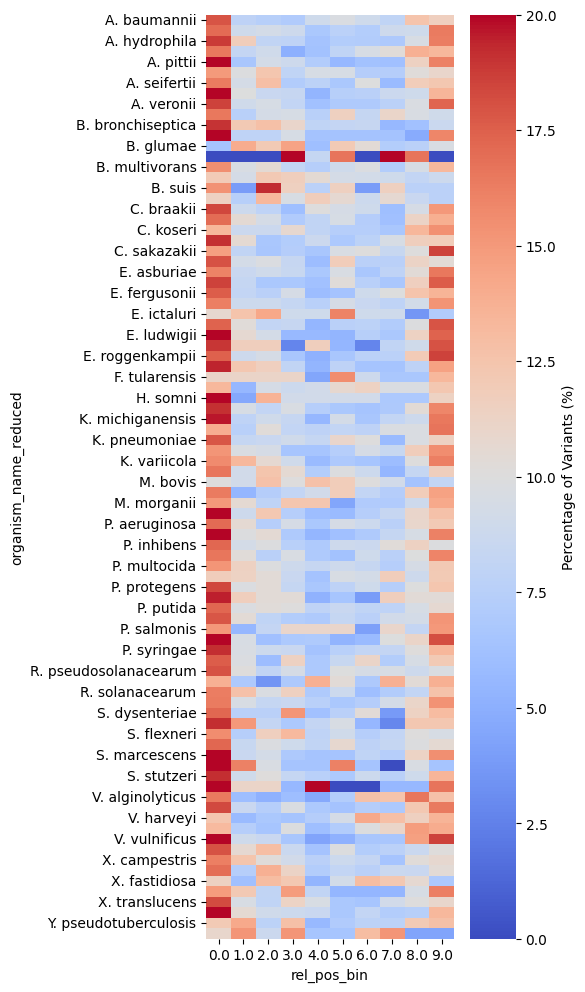

In [241]:
import matplotlib.pyplot as plt 

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(4, 12))

sns.heatmap(data=bin_counts_df.to_pandas().pivot(index="organism_name_reduced",
                                     columns=["rel_pos_bin"],
                                     values="rel_pos_bin_prop").fillna(0),
            cmap="coolwarm",
            # lw=0.05,
            vmax=20.0,
            vmin=0.0,
            linecolor='black',
            cbar_kws={"label": "Percentage of Variants (%)"},
            ax=ax)

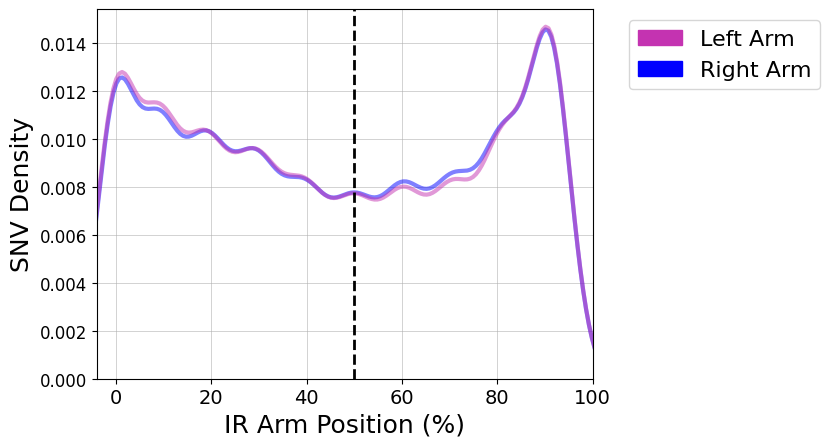

In [266]:
import matplotlib.pyplot as plt 
import matplotlib.patches as mpatches
palette = {"left": "#c433b1",
                     "right": "blue"}
sns.kdeplot(data=rel_pos_df, 
            x="rel_pos", 
            hue="group", 
            fill=False, 
            bw_adjust=1.0,
            lw=3.0,
            palette=palette,
            common_norm=False, 
            color="blue", 
            alpha=0.5,
            )
ax = plt.gca()
ax.axvline(x=50.0, lw=2.0, ls="--", color="black")
# ax.axvline(x=0.0, lw=1.0, ls="--", color="black")

labels = ["Left Arm", "Right Arm"]
ax.legend(title="", 
          handles=[mpatches.Patch(color=palette[label.split(" ")[0].lower()], label=label) for label in labels],
          prop={"size": 16},
          bbox_to_anchor=(1.05, 1),)
ax.set_axisbelow(True)
ax.set_ylabel("SNV Density", fontsize=18)
# ax.set_xlim(xmin=0, xmax=100)
ax.set_xlabel("IR Arm Position (%)", fontsize=18)
ax.tick_params(axis="x", labelsize=14)
ax.tick_params(axis="y", labelsize=12)
ax.grid(lw=0.4)
ax.set_xlim(xmin=-4, xmax=100)

plt.show()

In [ ]:
arm_df.filter(~pl.col("left_arm_start").is_null(), 
              ~pl.col("right_arm_start").is_null()
              )

seqID,left_arm_start,left_arm_end,start,end,mut_seq,mut_start,mut_end,transition,column_10,seqID_right,right_arm_start,right_arm_end,start_right,end_right,mut_seq_right,mut_start_right,mut_end_right,transition_right,column_10_right
str,i64,i64,i64,i64,str,i64,i64,str,i64,str,i64,i64,i64,i64,str,i64,i64,str,i64
"""NZ_CP009433.1""",146730,146741,146730,146753,"""NZ_CP009433.1""",146739,146740,"""A>G""",1,"""NZ_CP009433.1""",146742,146753,146730,146753,"""NZ_CP009433.1""",146743,146744,"""T>A""",1
"""NZ_CP009433.1""",146730,146741,146730,146753,"""NZ_CP009433.1""",146739,146740,"""A>G""",1,"""NZ_CP009433.1""",146742,146753,146730,146753,"""NZ_CP009433.1""",146744,146745,"""G>A""",1
"""NZ_CP009433.1""",147586,147597,147586,147608,"""NZ_CP009433.1""",147587,147588,"""G>C""",1,"""NZ_CP009433.1""",147597,147608,147586,147608,"""NZ_CP009433.1""",147597,147598,"""C>T""",1
"""NZ_CP009433.1""",147586,147597,147586,147608,"""NZ_CP009433.1""",147592,147593,"""C>G""",1,"""NZ_CP009433.1""",147597,147608,147586,147608,"""NZ_CP009433.1""",147597,147598,"""C>T""",1
"""NZ_CP009433.1""",147586,147597,147586,147608,"""NZ_CP009433.1""",147596,147597,"""G>T""",1,"""NZ_CP009433.1""",147597,147608,147586,147608,"""NZ_CP009433.1""",147597,147598,"""C>T""",1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""NZ_CP009435.1""",1758019,1758029,1758019,1758043,"""NZ_CP009435.1""",1758022,1758023,"""T>G""",1,"""NZ_CP009435.1""",1758033,1758043,1758019,1758043,"""NZ_CP009435.1""",1758039,1758040,"""A>G""",1
"""NZ_CP009435.1""",2258911,2258923,2258911,2258943,"""NZ_CP009435.1""",2258919,2258920,"""G>T""",1,"""NZ_CP009435.1""",2258931,2258943,2258911,2258943,"""NZ_CP009435.1""",2258934,2258935,"""C>T""",1
"""NZ_CP009435.1""",2258911,2258923,2258911,2258943,"""NZ_CP009435.1""",2258919,2258920,"""G>T""",1,"""NZ_CP009435.1""",2258931,2258943,2258911,2258943,"""NZ_CP009435.1""",2258940,2258941,"""G>C""",1


In [120]:
arm_df[1].filter(lambda x: x[1] > 27400).saveas().head()

TypeError: invalid predicate for `filter`: <function <lambda> at 0x44a6a5940>

In [70]:
## Be Careful of Polyallelic sites

In [71]:
VCF_df["POS"].value_counts().sort(by=["count"])

POS,count
i64,u32
1697728,1
2617649,1
1995388,1
3602123,1
2665110,1
…,…
2216132,5
1770830,5
303444,5


In [72]:
VCF_df.filter(pl.col("POS") == 3134103)

#CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,FORMAT,AF
str,i64,str,str,str,f64,str,str,str,f64
"""NZ_AP028077.1""",3134103,""".""","""G""","""T""",139.56,"""PASS""","""DP=135;VDB=0.0162466;SGB=-2.50…","""GT:PL:AD""",0.0296296
"""NZ_AP028078.1""",3134103,""".""","""T""","""G""",2669.03,"""PASS""","""DP=119;VDB=2.26628e-40;SGB=-6.…","""GT:PL:AD""",0.361345
"""NZ_AP028078.1""",3134103,""".""","""T""","""C""",2669.03,"""PASS""","""DP=119;VDB=2.26628e-40;SGB=-6.…","""GT:PL:AD""",0.0840336
"""NZ_AP028078.1""",3134103,""".""","""T""","""TCGGTTGTCGGTTGTCGGTTGTCGGTTGTC…",482.51,"""PASS""","""INDEL;IDV=1;IMF=1;DP=135;VDB=8…","""GT:PL:AD""",0.304348
"""NZ_AP028078.1""",3134103,""".""","""T""","""TCGGTTGTCGGTTGTCGGTTGTCGGTTGTC…",482.51,"""PASS""","""INDEL;IDV=1;IMF=1;DP=135;VDB=8…","""GT:PL:AD""",0.173913


In [121]:
## Expected vs. Observed Spacer and Arms

species_taxid,genome_size,organism_name_reduced,observed_mutations,segment_length,expected_mutations,partition,group,enrichment
i64,i64,str,i64,i64,f64,str,str,f64
337,6747595,"""B. glumae""",198,22202,147.302055,""".""","""Arm""",1.344177
783,1268220,"""R. rickettsii""",27,3563,16.40831,""".""","""Arm""",1.645508
669,5881490,"""V. harveyi""",511,22863,533.082315,""".""","""Arm""",0.958576
347,4952202,"""X. oryzae""",65,8825,60.152746,""".""","""Arm""",1.080582
299767,5369929,"""E. ludwigii""",254,12950,326.641203,""".""","""Arm""",0.777612
…,…,…,…,…,…,…,…,…
731,2110642,"""H. somni""",46,1004,12.602238,""".""","""Spacer""",3.650145
29575,1649945,"""T. equigenitalis""",11,377,2.276909,""".""","""Spacer""",4.831111
208962,5336845,"""E. albertii""",176,2207,55.873183,""".""","""Spacer""",3.149991


In [ ]:
!pip install -q selenium

In [127]:
motifs

/Users/nikolchantzi/biolab/ControlFarmer/VCF_stats/IR_figures/polymorphism_analysis/IR_observed_vs_expected_SNV_comparison_g_effect_size_corrected.svg


In [ ]:
## Across Compartments?

In [271]:
from bokeh.models import ColumnDataSource, Whisker, LabelSet
from bokeh.plotting import figure, show
from bokeh.transform import jitter, dodge
import pandas as pd
from bokeh.io import export_svg
import numpy as np
from scipy.stats import ttest_ind
domains = ["Bacteria", "Eukaryota", "Archaea", "Viruses"]
expected_color = "#e84d60"
observed_color = "#3c4cba"

hedges_g_list = dict()
t_test = dict()
def map_stars(pval):
    if pval < 0.0001:
        return "*" * 4
    elif pval < 0.001:
        return "*" * 3
    elif pval < 0.01:
        return "*" * 2
    elif pval < 0.05:
        return "*"
    return ""

for domain in domains:
    obs = comparison_df_avg.filter(pl.col("partition") == ".").filter(pl.col("domain") == domain)[f"density_corrected"].to_pandas()
    ctrl = comparison_df_avg.filter(pl.col("partition") == ".").filter(pl.col("domain") == domain)[f"density_control_corrected"].to_pandas()

    result = ttest_ind(obs, ctrl)
    t_test[domain] = (result.statistic, result.pvalue)
    n1, n2 = len(obs), len(ctrl)
    s1, s2 = np.std(obs, ddof=1), np.std(ctrl, ddof=1)

    # pooled standard deviation
    pooled_denom = (n1 - 1) + (n2 - 1)
    if pooled_denom > 0:
        s_pooled = np.sqrt(((n1 - 1) * s1 ** 2 + (n2 - 1) * s2 ** 2) / pooled_denom)
    else:
        s_pooled = np.nan

    # Cohen's d
    d = (np.mean(obs) - np.mean(ctrl)) / s_pooled if s_pooled and not np.isnan(s_pooled) else np.nan

    # Hedges' correction J
    df = n1 + n2 - 2
    J = 1.0 - (3.0 / (4.0 * df - 1.0)) if df > 0 else 1.0
    g = d * J if not np.isnan(d) else np.nan

    hedges_g_list[domain] = g


p = figure(height=400, 
           x_range=domains, 
           title="", 
            output_backend="svg",
           toolbar_location=None)
p.xgrid.grid_line_color = None

alpha = 0.025
quantiles_df = comparison_df_avg.filter(pl.col("partition") == ".")\
                                .group_by(["domain"]).agg(
                                           pl.col(f"density_corrected").quantile(alpha/2).alias("lower_ci"),
                                           pl.col(f"density_corrected").quantile(1-alpha/2).alias("upper_ci"),
                                           pl.col(f"density_control_corrected").quantile(alpha/2).alias("lower_ci_control"),
                                           pl.col(f"density_control_corrected").quantile(1-alpha/2).alias("upper_ci_control")
                                           )
quantiles_df
source_scatter = ColumnDataSource(comparison_df_avg.filter(pl.col("partition") == "."))
source_whisker = ColumnDataSource(quantiles_df)
opacity = 0.06
p.scatter(jitter("domain", width=0.2, range=p.x_range, mean=-0.15),
          f"density_corrected",
          source=source_scatter, alpha=opacity, size=13, line_color="white", color=observed_color)

p.scatter(jitter("domain", width=0.2, range=p.x_range, mean=0.15),
          f"density_control_corrected",
          source=source_scatter, 
          alpha=opacity, 
          size=13, line_color="white", color=expected_color)

# Observed whiskers
error_obs = Whisker(base=dodge("domain", -0.15, range=p.x_range),
                    upper="upper_ci", 
                    lower="lower_ci", 
                    source=source_whisker,
                    level="annotation", line_width=3
)
error_obs.upper_head.size = 30
error_obs.lower_head.size = 30
p.add_layout(error_obs)

# Expected whiskers
error_exp = Whisker(base=dodge("domain", 0.15, range=p.x_range),
                    upper="upper_ci_control", lower="lower_ci_control", source=source_whisker,
                    level="annotation", line_width=3
)
error_exp.upper_head.size = 30
error_exp.lower_head.size = 30
p.add_layout(error_exp)

p.y_range.end = 35
upper_ci = quantiles_df.to_pandas().set_index("domain")["upper_ci"].to_dict()
annot_df = pd.DataFrame({
    "domain": domains,
    "cohen_d": ["g = " + f"{hedges_g_list[domain]:.2f}\n" for domain in domains],
    "y": [upper_ci[domain] for domain in domains]
})
source_annot = ColumnDataSource(annot_df)
labels = LabelSet(x="domain", y="y", text="cohen_d", source=source_annot,
                  text_font_size="18pt", text_color="black",
                  x_offset=10,
                  background_fill_color="white", background_fill_alpha=0.2,
                  text_align="center")
p.add_layout(labels)

annot_df = pd.DataFrame({
    "domain": domains,
    "cohen_d": [f"{map_stars(t_test[domain][1])}" for domain in domains],
    "y": [upper_ci[domain] * 0.99 for domain in domains]
})
source_annot = ColumnDataSource(annot_df)
labels = LabelSet(x="domain", y="y", text="cohen_d", source=source_annot,
                  text_font_size="18pt", text_color="black",
                  x_offset=4,
                  background_fill_color="white", background_fill_alpha=0.2,
                  text_align="center")
p.add_layout(labels)


p.title.text_font_size = "2pt"
p.title.text_font_style = "normal"
p.title.align = "center"

p.yaxis.axis_label = f"{pattern} Density per kB"
p.xaxis.axis_label_text_font_size = "24pt"
p.xaxis.axis_label_text_font_style = "normal"
p.yaxis.axis_label_text_font_size = "24pt"
p.yaxis.axis_label_text_font_style = "normal"

p.xaxis.major_label_text_font_size = "22pt"
p.xaxis.major_label_text_font_style = "normal"
p.yaxis.major_label_text_font_size = "24pt"
p.yaxis.major_label_text_font_style = "normal"
target = Path(f"{pattern}_figures/simulation").resolve()
export_svg(p, filename=target / f"{pattern}_density_vs_control_comparison_g_effect_size_corrected.svg")
show(p)
print(target / f"{pattern}_density_vs_control_comparison_g_effect_size_corrected.svg")

NameError: name 'comparison_df_avg' is not defined